In [98]:
#import core libraries used for SHAP explanation, model loading, and output saving
import os
from pathlib import Path
import warnings
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.special import expit
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

### **WP4 - Model Explainability Using SHAP**

This notebook explains the final psychiatric readmission prediction model selected from WP3. It uses SHAP values to describe which processed predictors contribute most globally, which feature families carry the main signal, and why selected individual admissions were assigned high or low risk.

The notebook is organised as:

- **4.1 SHAP methodology**: model, matrix, prediction, and explanation-sample setup.
- **4.2 Global explanations**: top predictors, feature-family importance, and directionality.
- **4.3 Diagnostic explanation analyses**: error-group contrasts, subgroup SHAP summaries, dependence-style plots, and outcome-window interpretation.
- **4.4 Local explanations**: representative admissions, cleaner local contribution plots, and force-plot examples.
- **4.5 Paired model explanation check**: Targeted LightGBM and Targeted XGBoost SHAP comparison.
- **4.6 Subgroup-specific model SHAP check**: best and worst subgroup refits from WP3.6.
- **4.7 Exports**: final SHAP tables, images, and workbook outputs.


**4.1 - SHAP Methodology**

This section defines the SHAP approach, loads the final model and processed test matrix, and creates a manageable explanation sample from the held-out test set. The sample is used because SHAP can be computationally expensive on the full processed matrix.

In [99]:
#import SHAP and record whether the dependency is available
try:
    import shap
    shap_available = True
    shap_import_error = None
except Exception as error:
    shap = None
    shap_available = False
    shap_import_error = error

print("SHAP available:", shap_available)
if shap_available:
    print("SHAP version:", shap.__version__)
else:
    print("SHAP import error:", shap_import_error)

SHAP available: True
SHAP version: 0.52.0


**Define paths**

The notebook reads WP3.1 processed matrices and the saved final model from WP3.4, then writes SHAP tables and figures into a dedicated WP4 output folder. The `wp3_input_variant` variable states the preferred primary matrix, currently the SHAP-guided reduced feature set.


In [100]:
#define project paths and create dedicated output folders for WP4 artefacts
project_path = Path("/Users/ahthini/Desktop/DissProject")
wp3_1_output_path = project_path / "outputs" / "WP3_1"
wp3_4_output_path = project_path / "outputs" / "WP3_4"
wp3_6_output_path = project_path / "outputs" / "WP3_6"
#WP3.6 holds final evaluation tables; WP3.4 still holds the fitted tree models explained here.
wp4_output_path = project_path / "outputs" / "WP4"
wp4_csv_output_path = wp4_output_path / "csv_tables"
wp4_image_output_path = wp4_output_path / "images"

#preferred primary matrix after the reduced-feature decision
wp3_input_variant = "shap_guided_reduced_feature_set"

#explain the main final model selected in WP3.6.
#Targeted LightGBM is treated as the primary explanation target because it is the current top model by PR-AUC.
#A paired LightGBM/XGBoost SHAP comparison is added at the end of the notebook for explanation stability.
final_model_family = "Targeted LightGBM"
final_model_path = wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_model.joblib"
final_prediction_path = wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_test_predictions.csv"
final_performance_path = wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_performance.csv"

shap_model_specs = [
    {"model_family": "Targeted LightGBM", "model_slug": "targeted_lightgbm",
     "model_path": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_model.joblib",
     "prediction_path": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_test_predictions.csv",
     "performance_path": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_performance.csv"},
    {"model_family": "Targeted XGBoost", "model_slug": "targeted_xgboost",
     "model_path": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_model.joblib",
     "prediction_path": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_test_predictions.csv",
     "performance_path": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_performance.csv"}]

wp4_output_path.mkdir(parents=True, exist_ok=True)
wp4_csv_output_path.mkdir(parents=True, exist_ok=True)
wp4_image_output_path.mkdir(parents=True, exist_ok=True)

print("Preferred WP3 input variant:", wp3_input_variant)
print("WP4 output folder:")
print(wp4_output_path)
print("WP4 CSV table folder:")
print(wp4_csv_output_path)
print("WP4 image folder:")
print(wp4_image_output_path)
print("Final model path:")
print(final_model_path)


Preferred WP3 input variant: shap_guided_reduced_feature_set
WP4 output folder:
/Users/ahthini/Desktop/DissProject/outputs/WP4
WP4 CSV table folder:
/Users/ahthini/Desktop/DissProject/outputs/WP4/csv_tables
WP4 image folder:
/Users/ahthini/Desktop/DissProject/outputs/WP4/images
Final model path:
/Users/ahthini/Desktop/DissProject/outputs/WP3_4/lightgbm_targeted/t3_4_lightgbm_targeted_model.joblib


In [101]:
#load processed test matrix, outcomes, identifiers, feature names, predictions, and model
#the loader prefers the SHAP-guided reduced matrix, then falls back only if the saved model still expects an older feature count
if not final_model_path.exists():
    raise FileNotFoundError(f"Expected final model was not found: {final_model_path}")
if not final_prediction_path.exists():
    raise FileNotFoundError(f"Expected final prediction file was not found: {final_prediction_path}")

final_model = joblib.load(final_model_path)
model_expected_features = getattr(final_model, "n_features_in_", None)
if model_expected_features is None and hasattr(final_model, "get_booster"):
    model_expected_features = final_model.get_booster().num_features()
model_expected_features = int(model_expected_features) if model_expected_features is not None else None

candidate_matrix_suffixes = [wp3_input_variant, "clean_feature_audit", "runtime_trimmed_feature_audit", None]
selected_matrix_info = None
for matrix_suffix in candidate_matrix_suffixes:
    if matrix_suffix is None:
        candidate_X_test_path = wp3_1_output_path / "t3_1_X_test_processed.npz"
        candidate_feature_names_path = wp3_1_output_path / "t3_1_processed_feature_names.csv"
        candidate_label = "full_processed_matrix"
    else:
        candidate_X_test_path = wp3_1_output_path / f"t3_1_X_test_processed_{matrix_suffix}.npz"
        candidate_feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{matrix_suffix}.csv"
        candidate_label = matrix_suffix
    if not candidate_X_test_path.exists() or not candidate_feature_names_path.exists():
        continue
    candidate_feature_count = len(pd.read_csv(candidate_feature_names_path, usecols=["processed_feature_name"]))
    if model_expected_features is None or candidate_feature_count == model_expected_features:
        selected_matrix_info = (candidate_X_test_path, candidate_feature_names_path, candidate_label)
        break

if selected_matrix_info is None:
    raise ValueError(
        "No WP3.1 processed matrix matches the saved model feature count. "
        f"The saved model expects {model_expected_features} features. "
        "Rerun WP3.2-WP3.4 after rebuilding the SHAP-guided reduced matrix, then rerun WP4."
    )

X_test_path, processed_feature_names_path, matrix_source_label = selected_matrix_info
X_test = sparse.load_npz(X_test_path)
y_test = pd.read_csv(wp3_1_output_path / "t3_1_y_test.csv")["readmitted_30d"].astype(int)
test_ids = pd.read_csv(wp3_1_output_path / "t3_1_test_ids.csv")
processed_feature_names = pd.read_csv(processed_feature_names_path)["processed_feature_name"].tolist()
test_predictions = pd.read_csv(final_prediction_path)

if X_test.shape[1] != len(processed_feature_names):
    raise ValueError(
        f"Feature-name count mismatch: matrix has {X_test.shape[1]} columns but "
        f"{len(processed_feature_names)} feature names were loaded."
    )

if matrix_source_label != wp3_input_variant:
    print("Note: WP4 is using", matrix_source_label, "because the saved model has not yet been rerun on", wp3_input_variant)

print("Loaded matrix source:", matrix_source_label)
print("Test matrix path:", X_test_path)
print("Feature names path:", processed_feature_names_path)
print("Test matrix shape:", X_test.shape)
print("Number of processed feature names:", len(processed_feature_names))
print("Model expected features:", model_expected_features)
print("Test outcome distribution:")
print(y_test.value_counts().sort_index())
print("Loaded prediction rows:", len(test_predictions))
print("Loaded model type:", type(final_model))


Loaded matrix source: shap_guided_reduced_feature_set
Test matrix path: /Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_X_test_processed_shap_guided_reduced_feature_set.npz
Feature names path: /Users/ahthini/Desktop/DissProject/outputs/WP3_1/t3_1_processed_feature_names_shap_guided_reduced_feature_set.csv
Test matrix shape: (47171, 544)
Number of processed feature names: 544
Model expected features: 544
Test outcome distribution:
readmitted_30d
0    37852
1     9319
Name: count, dtype: int64
Loaded prediction rows: 47171
Loaded model type: <class 'lightgbm.sklearn.LGBMClassifier'>


In [102]:
#merge predictions with test identifiers so SHAP rows can be linked back to admissions
prediction_id_cols = ["subject_id", "hadm_id", "readmitted_30d", "predicted_probability"]
if set(prediction_id_cols).issubset(test_predictions.columns):
    explanation_index_df = test_predictions[prediction_id_cols].copy()
else:
    explanation_index_df = test_ids.copy()
    explanation_index_df["readmitted_30d"] = y_test.values
    explanation_index_df["predicted_probability"] = final_model.predict_proba(X_test)[:, 1]

#derive a 14-day psychiatric readmission marker for local interpretation if timing is available
if "days_to_next" in test_predictions.columns:
    explanation_index_df["days_to_next"] = test_predictions["days_to_next"]
    explanation_index_df["readmitted_14d_psych"] = explanation_index_df["days_to_next"].between(0, 14, inclusive="both").fillna(False).astype(int)
for outcome_column in ["readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych"]:
    if outcome_column in test_predictions.columns:
        explanation_index_df[outcome_column] = test_predictions[outcome_column].astype(int)

explanation_index_df["test_row_index"] = np.arange(len(explanation_index_df))
print("Explanation index preview:")
display(explanation_index_df.head())


Explanation index preview:


,subject_id,hadm_id,readmitted_30d,predicted_probability,days_to_next,readmitted_14d_psych,readmitted_60d_psych,readmitted_90d_psych,readmitted_365d_psych,test_row_index
0,10000117,22927623,0,0.100705,672.0,0,0,0,0,0
1,10000117,27988844,0,0.095649,NaN,0,0,0,0,1
2,10002221,21008195,0,0.128198,984.0,0,0,0,0,2
3,10002221,20195471,0,0.125151,377.0,0,0,0,0,3
4,10002221,21729093,1,0.288999,3.0,1,1,1,1,4


In [103]:
#create a balanced and high-risk-enriched SHAP sample from the held-out test set
#this keeps the explanation set manageable while ensuring true positives, false positives, and high-risk admissions are represented
shap_random_state = 42
max_shap_rows = 2500
rng = np.random.default_rng(shap_random_state)

positive_indices = explanation_index_df.loc[explanation_index_df["readmitted_30d"] == 1, "test_row_index"].to_numpy()
negative_indices = explanation_index_df.loc[explanation_index_df["readmitted_30d"] == 0, "test_row_index"].to_numpy()
high_risk_indices = explanation_index_df.sort_values("predicted_probability", ascending=False).head(500)["test_row_index"].to_numpy()

positive_sample = rng.choice(positive_indices, size=min(900, len(positive_indices)), replace=False) if len(positive_indices) else np.array([], dtype=int)
negative_sample = rng.choice(negative_indices, size=min(900, len(negative_indices)), replace=False) if len(negative_indices) else np.array([], dtype=int)
remaining_size = max(0, max_shap_rows - len(set(positive_sample).union(set(negative_sample)).union(set(high_risk_indices))))
remaining_indices = np.setdiff1d(np.arange(X_test.shape[0]), np.unique(np.concatenate([positive_sample, negative_sample, high_risk_indices])))
random_sample = rng.choice(remaining_indices, size=min(remaining_size, len(remaining_indices)), replace=False) if len(remaining_indices) else np.array([], dtype=int)

shap_sample_indices = np.unique(np.concatenate([positive_sample, negative_sample, high_risk_indices, random_sample])).astype(int)
shap_sample_indices = shap_sample_indices[:max_shap_rows]
X_shap_sample = X_test[shap_sample_indices]
shap_sample_index_df = explanation_index_df.iloc[shap_sample_indices].copy().reset_index(drop=True)

print("SHAP sample rows:", X_shap_sample.shape[0])
print("SHAP sample columns:", X_shap_sample.shape[1])
print("SHAP sample outcome distribution:")
print(shap_sample_index_df["readmitted_30d"].value_counts().sort_index())
print("SHAP sample predicted probability summary:")
print(shap_sample_index_df["predicted_probability"].describe())

SHAP sample rows: 2500
SHAP sample columns: 544
SHAP sample outcome distribution:
readmitted_30d
0    1112
1    1388
Name: count, dtype: int64
SHAP sample predicted probability summary:
count    2500.000000
mean        0.466184
std         0.330651
min         0.002747
25%         0.184020
50%         0.342457
75%         0.815057
max         0.988883
Name: predicted_probability, dtype: float64


In [104]:
#compute SHAP values for the sampled held-out admissions
#TreeExplainer reports contributions on the model log-odds scale for binary tree models
if not shap_available:
    raise ImportError("SHAP is not available in this environment. Install or enable SHAP before running WP4.")

shap_start_time = time.perf_counter()
explainer = shap.TreeExplainer(final_model)
try:
    shap_values_raw = explainer.shap_values(X_shap_sample)
    X_shap_display = X_shap_sample
except Exception as sparse_error:
    print("Sparse SHAP calculation failed, retrying with a dense sample matrix.")
    print("Sparse SHAP error:", sparse_error)
    X_shap_display = X_shap_sample.toarray() if sparse.issparse(X_shap_sample) else X_shap_sample
    shap_values_raw = explainer.shap_values(X_shap_display)

def normalise_binary_shap_values(shap_values_raw, feature_names):
    """Convert SHAP output from tree libraries into a dense rows x features array."""
    if isinstance(shap_values_raw, list):
        shap_values_processed = shap_values_raw[-1]
    elif hasattr(shap_values_raw, "values"):
        shap_values_processed = shap_values_raw.values
    else:
        shap_values_processed = shap_values_raw

    #SHAP 0.52 can return sparse matrices for LightGBM; np.asarray(csr_matrix) becomes a scalar object.
    if sparse.issparse(shap_values_processed):
        shap_values_processed = shap_values_processed.toarray()
    shap_values_processed = np.asarray(shap_values_processed)

    #Different tree libraries return binary SHAP as rows x features or rows x features x classes.
    if shap_values_processed.ndim == 3:
        if shap_values_processed.shape[2] == 2:
            shap_values_processed = shap_values_processed[:, :, 1]
        elif shap_values_processed.shape[0] == 2:
            shap_values_processed = shap_values_processed[1, :, :]
        else:
            raise ValueError(f"Unexpected 3D SHAP shape: {shap_values_processed.shape}")
    if shap_values_processed.ndim != 2:
        raise ValueError(f"Expected a 2D SHAP matrix after processing, got shape: {shap_values_processed.shape}")
    if shap_values_processed.shape[1] != len(feature_names):
        raise ValueError("SHAP feature count does not match processed feature names: "
            f"{shap_values_processed.shape[1]} vs {len(feature_names)}")
    return shap_values_processed

shap_values = normalise_binary_shap_values(shap_values_raw, processed_feature_names)
if shap_values.shape[1] != len(processed_feature_names):
    raise ValueError("SHAP feature count does not match processed feature names: "
        f"{shap_values.shape[1]} vs {len(processed_feature_names)}")

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()[-1]

shap_elapsed_seconds = time.perf_counter() - shap_start_time
print("SHAP value matrix shape:", shap_values.shape)
print("SHAP expected value:", base_value)
print("SHAP calculation time in seconds:", round(shap_elapsed_seconds, 2))


SHAP value matrix shape: (2500, 544)
SHAP expected value: -1.0627075342125196
SHAP calculation time in seconds: 16.88


In [105]:
#save a compact methodology summary for transparent reporting
methodology_summary_df = pd.DataFrame([{
    "explained_model_family": final_model_family,
    "model_path": str(final_model_path),
    "matrix_source": matrix_source_label,
    "test_matrix_path": str(X_test_path),
    "processed_feature_names_path": str(processed_feature_names_path),
    "test_rows": X_test.shape[0],
    "processed_features": X_test.shape[1],
    "model_expected_features": model_expected_features,
    "shap_sample_rows": X_shap_sample.shape[0],
    "shap_sample_positive_rows": int(shap_sample_index_df["readmitted_30d"].sum()),
    "shap_sample_negative_rows": int((1 - shap_sample_index_df["readmitted_30d"]).sum()),
    "shap_expected_value_log_odds": base_value,
    "shap_expected_value_probability": expit(base_value),
    "shap_random_state": shap_random_state,
    "shap_elapsed_seconds": shap_elapsed_seconds}])
methodology_summary_df.to_csv(wp4_csv_output_path / "t4_shap_methodology_summary.csv", index=False)
display(methodology_summary_df)

,explained_model_family,model_path,matrix_source,test_matrix_path,processed_feature_names_path,test_rows,processed_features,model_expected_features,shap_sample_rows,shap_sample_positive_rows,shap_sample_negative_rows,shap_expected_value_log_odds,shap_expected_value_probability,shap_random_state,shap_elapsed_seconds
0,Targeted LightGBM,/Users/ahthini/Desktop/DissProject/outputs/WP3...,shap_guided_reduced_feature_set,/Users/ahthini/Desktop/DissProject/outputs/WP3...,/Users/ahthini/Desktop/DissProject/outputs/WP3...,47171,544,544,2500,1388,1112,-1.062708,0.256792,42,16.875146


**4.2 - Global Explanations**

This section summarises which processed predictors have the largest average absolute SHAP values across the sampled held-out admissions. Larger mean absolute SHAP values indicate stronger average influence on predicted readmission risk.

In [106]:
#summarise global SHAP importance across the held-out explanation sample
mean_abs_shap = np.abs(shap_values).mean(axis=0)
mean_signed_shap = shap_values.mean(axis=0)
std_shap = shap_values.std(axis=0)

shap_global_importance_df = pd.DataFrame({
    "processed_feature_name": processed_feature_names,
    "mean_abs_shap": mean_abs_shap,
    "mean_signed_shap": mean_signed_shap,
    "std_shap": std_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_global_importance_df["importance_rank"] = np.arange(1, len(shap_global_importance_df) + 1)
shap_global_importance_df["feature_name_clean"] = shap_global_importance_df["processed_feature_name"].str.replace("^num__", "", regex=True).str.replace("^cat__", "", regex=True)
shap_global_importance_df["feature_type"] = np.where(shap_global_importance_df["processed_feature_name"].str.startswith("cat__"), "categorical_encoded", "numeric_or_binary")

shap_global_importance_df.to_csv(wp4_csv_output_path / "t4_shap_global_importance.csv", index=False)
shap_global_importance_df.head(30).to_csv(wp4_csv_output_path / "t4_shap_top30_global_importance.csv", index=False)

print("Top 30 global SHAP features:")
display(shap_global_importance_df.head(30))

Top 30 global SHAP features:


,processed_feature_name,mean_abs_shap,mean_signed_shap,std_shap,importance_rank,feature_name_clean,feature_type
0,num__orders_last_12h_before_discharge,0.250453,0.184077,0.392591,1,orders_last_12h_before_discharge,numeric_or_binary
1,num__late_order_severity_per_late_order_last_12h,0.172060,0.129837,0.267905,2,late_order_severity_per_late_order_last_12h,numeric_or_binary
2,num__last_order_close_to_discharge_hours,0.149146,0.128144,0.286275,3,last_order_close_to_discharge_hours,numeric_or_binary
3,num__previous_psych_admissions_365d,0.135328,0.023643,0.192163,4,previous_psych_admissions_365d,numeric_or_binary
4,num__previous_psych_admissions_180d,0.103866,0.014161,0.153878,5,previous_psych_admissions_180d,numeric_or_binary
5,num__unmanaged_psychiatric_discharge_risk_score,0.097559,0.047303,0.124442,6,unmanaged_psychiatric_discharge_risk_score,numeric_or_binary
6,num__new_orders_last_12h_before_discharge_flag,0.087528,0.063409,0.137124,7,new_orders_last_12h_before_discharge_flag,numeric_or_binary
7,num__days_since_previous_psych_admission_filled,0.074994,0.011995,0.085508,8,days_since_previous_psych_admission_filled,numeric_or_binary
8,num__low_order_activity_with_self_harm_flag,0.064407,0.043243,0.138533,9,low_order_activity_with_self_harm_flag,numeric_or_binary
9,num__discharge_hour,0.054176,0.034978,0.090682,10,discharge_hour,numeric_or_binary


In [107]:
#summarise global SHAP importance by broad processed feature family
#These rules keep the main feature-engineering themes visible in the SHAP outputs.
feature_family_rules = [
    ("poe_order_pathway", "poe|order_|orders_|first_order|last_order|order_activity|sitter|observation|suicide_precaution|elopement|restraint_order|psych_consult|social_work|discontinued_orders|unique_order"),
    ("care_team_complexity", "care_team|caregiver|provider|enter_provider|order_provider|provider_order_changes|touchpoints"),
    ("prior_utilisation", "previous_|recent_|days_since_previous|admission_ratio|frequent|high_utiliser"),
    ("psychiatric_history", "psych|depression|bipolar|substance|alcohol|opioid|stimulant|cannabis|tobacco|nicotine|sedative|polysubstance|severe_mental|self_harm|suicidal|psychoses"),
    ("medication_emar", "medication|drug|prescription|pharmacy|emar|antipsychotic|benzodiazepine|mood_stabiliser|mood_stabilizer|lai|iv_prescription|infusion|not_given|dose|prn|scheduled_pharmacy"),
    ("discharge_social", "discharge|insurance|language|marital|race|public_insurance|non_english|facility|home_flag|against_advice"),
    ("ed_pathway", "ed_length|ed_to_|emergency_room|ward_delay|transfer_from|internal_transfer|service_transfer|first_service|last_service|medicine_service|psych_service"),
    ("laboratory", "_lab_|sodium|potassium|creatinine|glucose|wbc|hemoglobin|platelet|urea|culture|microbiology|organism|infection"),
    ("vital_sign", "_vital_|heart_rate|spo2|respiratory|bp_|systolic|mean_bp"),
    ("procedure_comorbidity", "procedure|comorbidity|elixhauser|charlson|bmi|weight|height|obesity|underweight|dialysis|ventilation|ect|central_line|physical"),
    ("icu_care", "icu|careunit"),
    ("admission_context", "admission_type|admission_location|admission_hour|admission_day|admission_month|admission_year|los_days|los_|anchor_age|age_|gender")]

def assign_feature_family(feature_name):
    for family_name, pattern in feature_family_rules:
        if pd.Series([feature_name]).str.contains(pattern, case=False, regex=True).iloc[0]:
            return family_name
    return "other"

shap_global_importance_df["feature_family"] = shap_global_importance_df["feature_name_clean"].apply(assign_feature_family)
shap_family_importance_df = shap_global_importance_df.groupby("feature_family", as_index=False).agg(
    processed_feature_count=("processed_feature_name", "size"),
    total_mean_abs_shap=("mean_abs_shap", "sum"),
    mean_abs_shap=("mean_abs_shap", "mean"),
    max_mean_abs_shap=("mean_abs_shap", "max"))
shap_family_importance_df = shap_family_importance_df.sort_values("total_mean_abs_shap", ascending=False).reset_index(drop=True)
shap_global_importance_df.to_csv(wp4_csv_output_path / "t4_shap_global_importance.csv", index=False)
shap_global_importance_df.head(30).to_csv(wp4_csv_output_path / "t4_shap_top30_global_importance.csv", index=False)
shap_family_importance_df.to_csv(wp4_csv_output_path / "t4_shap_feature_family_importance.csv", index=False)

#within-family top-five lists make the family summary actionable for feature-engineering decisions
family_rank_lookup = shap_family_importance_df[["feature_family"]].reset_index().rename(columns={"index": "family_importance_rank"})
family_rank_lookup["family_importance_rank"] = family_rank_lookup["family_importance_rank"] + 1
shap_top5_features_by_family_df = shap_global_importance_df.sort_values(
    ["feature_family", "mean_abs_shap"], ascending=[True, False]).groupby("feature_family", as_index=False).head(5).copy()
shap_top5_features_by_family_df["feature_rank_within_family"] = shap_top5_features_by_family_df.groupby(
    "feature_family")["mean_abs_shap"].rank(method="first", ascending=False).astype(int)
shap_top5_features_by_family_df = shap_top5_features_by_family_df.merge(family_rank_lookup, on="feature_family", how="left")
shap_top5_features_by_family_df = shap_top5_features_by_family_df.sort_values(
    ["family_importance_rank", "feature_rank_within_family"]).reset_index(drop=True)
shap_top5_features_by_family_df.to_csv(wp4_csv_output_path / "t4_shap_top5_features_by_family.csv", index=False)

print("SHAP importance by feature family:")
display(shap_family_importance_df)
print("Top five SHAP features within each feature family:")
display(shap_top5_features_by_family_df[["feature_family", "feature_rank_within_family",
    "processed_feature_name", "feature_name_clean", "mean_abs_shap", "family_importance_rank"]].head(60))



SHAP importance by feature family:


,feature_family,processed_feature_count,total_mean_abs_shap,mean_abs_shap,max_mean_abs_shap
0,poe_order_pathway,80,1.124780,0.014060,0.250453
1,prior_utilisation,46,0.629602,0.013687,0.135328
2,psychiatric_history,41,0.497130,0.012125,0.097559
3,discharge_social,104,0.292467,0.002812,0.054176
4,laboratory,106,0.292450,0.002759,0.011075
5,other,46,0.230194,0.005004,0.025222
6,medication_emar,32,0.160481,0.005015,0.028790
7,ed_pathway,18,0.112092,0.006227,0.015340
8,care_team_complexity,8,0.107222,0.013403,0.051638
9,admission_context,24,0.085668,0.003569,0.033993


Top five SHAP features within each feature family:


,feature_family,feature_rank_within_family,processed_feature_name,feature_name_clean,mean_abs_shap,family_importance_rank
0,poe_order_pathway,1,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,0.250453,1
1,poe_order_pathway,2,num__late_order_severity_per_late_order_last_12h,late_order_severity_per_late_order_last_12h,0.172060,1
2,poe_order_pathway,3,num__last_order_close_to_discharge_hours,last_order_close_to_discharge_hours,0.149146,1
3,poe_order_pathway,4,num__new_orders_last_12h_before_discharge_flag,new_orders_last_12h_before_discharge_flag,0.087528,1
4,poe_order_pathway,5,num__low_order_activity_with_self_harm_flag,low_order_activity_with_self_harm_flag,0.064407,1
5,prior_utilisation,1,num__previous_psych_admissions_365d,previous_psych_admissions_365d,0.135328,2
6,prior_utilisation,2,num__previous_psych_admissions_180d,previous_psych_admissions_180d,0.103866,2
7,prior_utilisation,3,num__days_since_previous_psych_admission_filled,days_since_previous_psych_admission_filled,0.074994,2
8,prior_utilisation,4,num__previous_psych_admissions,previous_psych_admissions,0.033597,2
9,prior_utilisation,5,num__frequent_psych_admitter_flag,frequent_psych_admitter_flag,0.025289,2


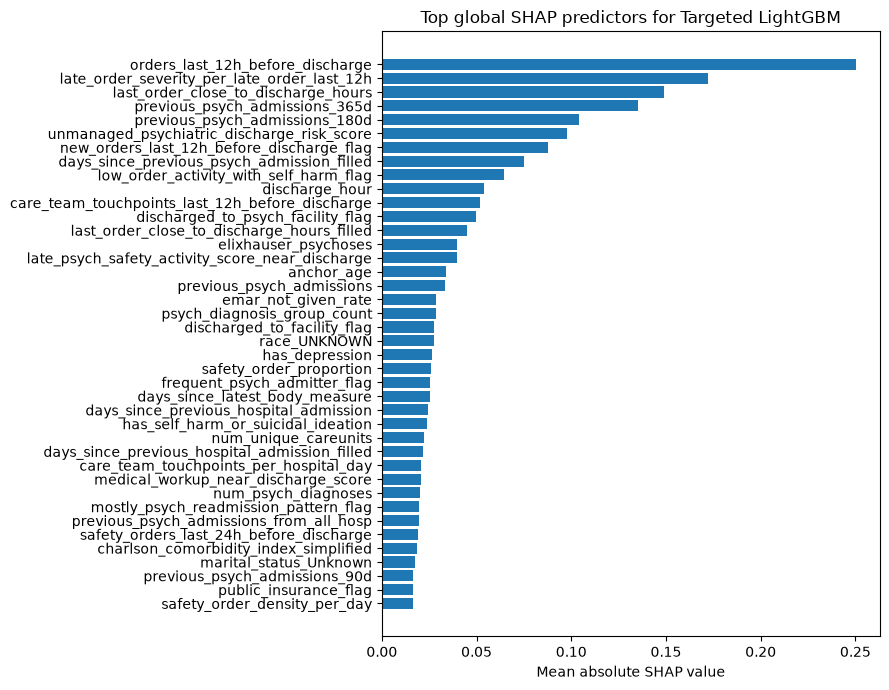

In [108]:
#plot top global SHAP features as a dissertation-friendly bar chart
top_n_global = 40
plot_global_df = shap_global_importance_df.head(top_n_global).sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_global_df["feature_name_clean"], plot_global_df["mean_abs_shap"], color="#1f77b4")
plt.xlabel("Mean absolute SHAP value")
plt.title(f"Top global SHAP predictors for {final_model_family}")
plt.tight_layout()
plt.savefig(wp4_image_output_path / "t4_shap_top20_global_importance.png", dpi=300)
plt.show()

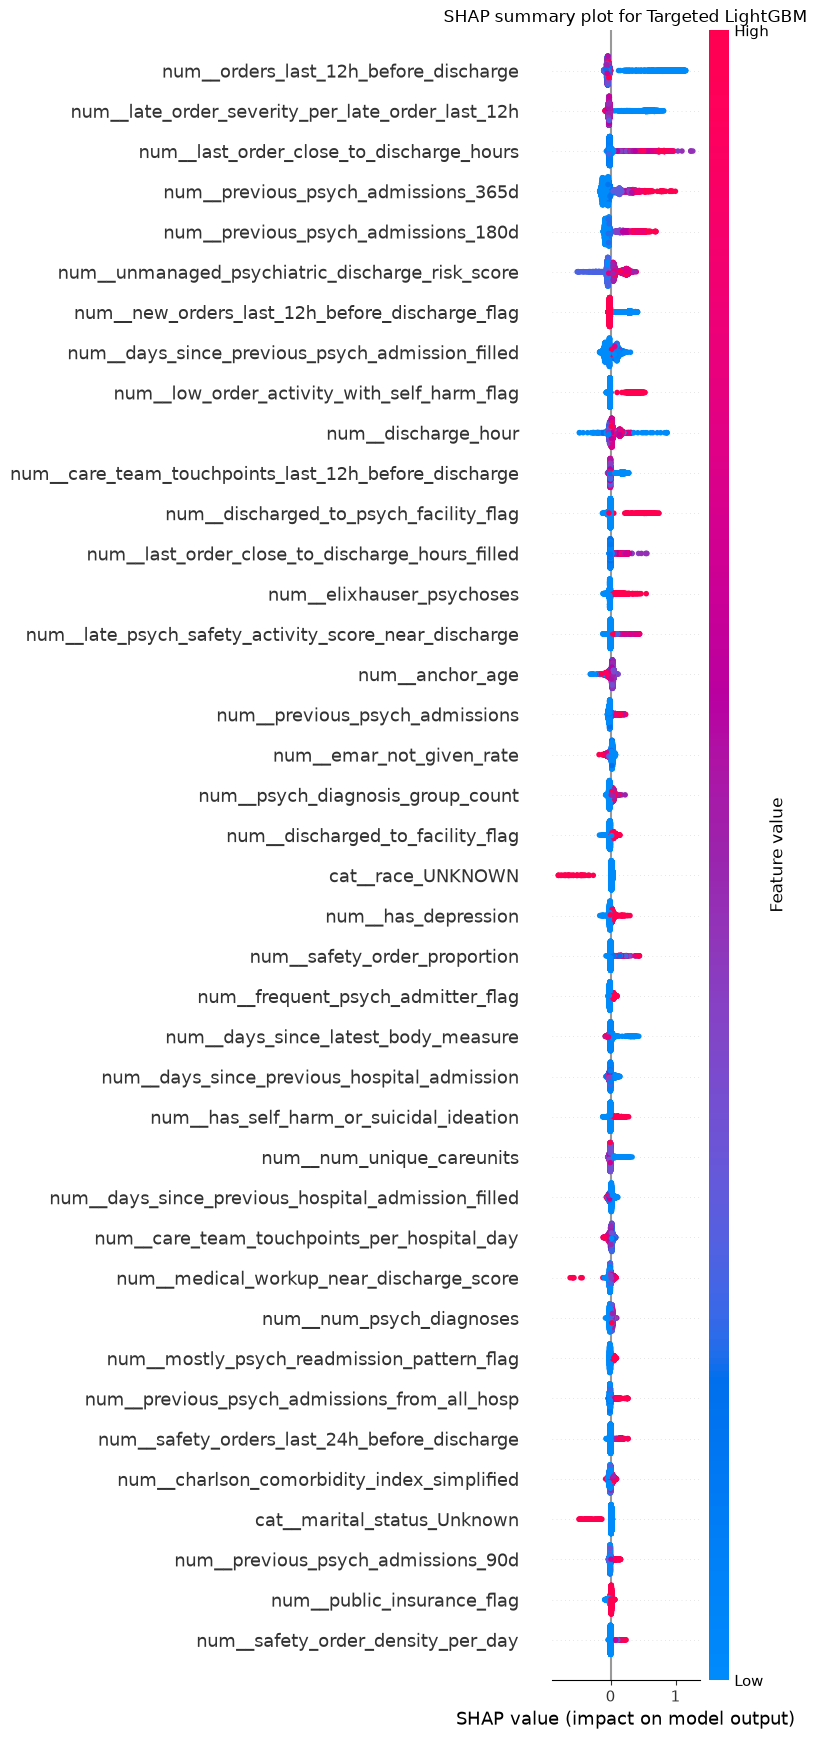

In [109]:
#create a SHAP beeswarm summary plot for the top predictors
#the dense display matrix is only used for plotting sampled rows
if sparse.issparse(X_shap_display):
    X_shap_plot = X_shap_display.toarray()
else:
    X_shap_plot = np.asarray(X_shap_display)

plt.figure(figsize=(3, 7))
shap.summary_plot(shap_values, X_shap_plot, feature_names=processed_feature_names,
    max_display=40, show=False)
plt.title(f"SHAP summary plot for {final_model_family}")
plt.tight_layout()
plt.savefig(wp4_image_output_path / "t4_shap_summary_beeswarm_top20.png", dpi=300, bbox_inches="tight")
plt.show()

**4.3 - Diagnostic Explanation Analyses**

This section connects SHAP explanations back to the evaluation results from WP3.6. Instead of only asking which features matter globally, it asks four practical questions:

- Do false positives and false negatives rely on different feature signals from true positives and true negatives?
- Do major clinical subgroups use different feature families?
- Do high feature values generally push risk up or down?
- Do selected features show threshold-like relationships with predicted risk?

These analyses are descriptive. They explain the fitted model; they do not change the official model or threshold.


In [110]:
#build diagnostic SHAP tables that connect explanation results to WP3.6 error and subgroup analyses
#These tables use the existing SHAP sample only, so they do not refit the model.
wp3_6_recommended_path = wp3_6_output_path / "csv_tables" / "recommended_model_comparison.csv"
wp4_selected_threshold = 0.39
if wp3_6_recommended_path.exists():
    recommended_rows_for_wp4 = pd.read_csv(wp3_6_recommended_path)
    model_threshold_rows = recommended_rows_for_wp4.loc[recommended_rows_for_wp4["model_family"].eq(final_model_family)]
    if not model_threshold_rows.empty and pd.notna(model_threshold_rows.iloc[0].get("threshold")):
        wp4_selected_threshold = float(model_threshold_rows.iloc[0]["threshold"])
elif final_performance_path.exists():
    performance_rows_for_wp4 = pd.read_csv(final_performance_path)
    if "threshold" in performance_rows_for_wp4.columns:
        wp4_selected_threshold = float(performance_rows_for_wp4.iloc[0]["threshold"])

shap_diagnostic_index_df = shap_sample_index_df.copy()
shap_diagnostic_index_df["predicted_label"] = (shap_diagnostic_index_df["predicted_probability"] >= wp4_selected_threshold).astype(int)
shap_diagnostic_index_df["classification_group"] = np.select([
    (shap_diagnostic_index_df["readmitted_30d"] == 1) & (shap_diagnostic_index_df["predicted_label"] == 1),
    (shap_diagnostic_index_df["readmitted_30d"] == 0) & (shap_diagnostic_index_df["predicted_label"] == 1),
    (shap_diagnostic_index_df["readmitted_30d"] == 1) & (shap_diagnostic_index_df["predicted_label"] == 0),
    (shap_diagnostic_index_df["readmitted_30d"] == 0) & (shap_diagnostic_index_df["predicted_label"] == 0)],
    ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")

#Create a long SHAP table only for the sampled explanation rows. This powers error-group and subgroup summaries.
shap_long_df = pd.DataFrame(shap_values, columns=processed_feature_names)
shap_long_df.insert(0, "shap_sample_position", np.arange(shap_long_df.shape[0]))
shap_long_df = shap_long_df.melt(id_vars="shap_sample_position", var_name="processed_feature_name", value_name="shap_value")
feature_metadata_df = shap_global_importance_df[["processed_feature_name", "feature_name_clean", "feature_family", "mean_abs_shap"]].copy()
shap_long_df = shap_long_df.merge(feature_metadata_df, on="processed_feature_name", how="left")
shap_long_df = shap_long_df.merge(
    shap_diagnostic_index_df[["test_row_index", "classification_group", "predicted_probability", "readmitted_30d"]].reset_index().rename(columns={"index": "shap_sample_position"}),
    on="shap_sample_position", how="left")
shap_long_df["abs_shap_value"] = shap_long_df["shap_value"].abs()

#Mean SHAP by error group identifies features that systematically push each group up or down.
shap_error_group_mean_df = shap_long_df.groupby(["classification_group", "processed_feature_name", "feature_name_clean", "feature_family"], as_index=False).agg(
    mean_shap_value=("shap_value", "mean"),
    mean_abs_shap_value=("abs_shap_value", "mean"),
    sample_rows=("shap_sample_position", "nunique"))
shap_error_group_mean_df = shap_error_group_mean_df.sort_values(
    ["classification_group", "mean_abs_shap_value"], ascending=[True, False]).reset_index(drop=True)
shap_error_group_mean_df.to_csv(wp4_csv_output_path / "t4_shap_error_group_mean_contributions.csv", index=False)

#Feature-family summaries are easier to write up than hundreds of single processed columns.
shap_error_group_family_df = shap_long_df.groupby(["classification_group", "feature_family"], as_index=False).agg(
    total_abs_shap=("abs_shap_value", "sum"),
    mean_abs_shap=("abs_shap_value", "mean"),
    mean_signed_shap=("shap_value", "mean"),
    sample_rows=("shap_sample_position", "nunique"))
shap_error_group_family_df = shap_error_group_family_df.sort_values(
    ["classification_group", "total_abs_shap"], ascending=[True, False]).reset_index(drop=True)
shap_error_group_family_df.to_csv(wp4_csv_output_path / "t4_shap_error_group_family_importance.csv", index=False)

def contrast_error_groups(left_group, right_group, output_label):
    left_df = shap_error_group_mean_df.loc[shap_error_group_mean_df["classification_group"].eq(left_group),
        ["processed_feature_name", "feature_name_clean", "feature_family", "mean_shap_value", "mean_abs_shap_value"]].rename(
        columns={"mean_shap_value": f"{left_group}_mean_shap", "mean_abs_shap_value": f"{left_group}_mean_abs_shap"})
    right_df = shap_error_group_mean_df.loc[shap_error_group_mean_df["classification_group"].eq(right_group),
        ["processed_feature_name", "mean_shap_value", "mean_abs_shap_value"]].rename(
        columns={"mean_shap_value": f"{right_group}_mean_shap", "mean_abs_shap_value": f"{right_group}_mean_abs_shap"})
    contrast_df = left_df.merge(right_df, on="processed_feature_name", how="inner")
    if contrast_df.empty:
        return contrast_df
    contrast_df["signed_shap_difference"] = contrast_df[f"{left_group}_mean_shap"] - contrast_df[f"{right_group}_mean_shap"]
    contrast_df["absolute_shap_difference"] = contrast_df["signed_shap_difference"].abs()
    contrast_df = contrast_df.sort_values("absolute_shap_difference", ascending=False).reset_index(drop=True)
    contrast_df.to_csv(wp4_csv_output_path / f"t4_shap_{output_label}_contrast.csv", index=False)
    return contrast_df

fp_vs_tp_shap_contrast_df = contrast_error_groups("false_positive", "true_positive", "fp_vs_tp")
fn_vs_tp_shap_contrast_df = contrast_error_groups("false_negative", "true_positive", "fn_vs_tp")
fn_vs_tn_shap_contrast_df = contrast_error_groups("false_negative", "true_negative", "fn_vs_tn")

#Directionality estimates whether higher feature values usually push risk up or down in the SHAP sample.
feature_direction_rows = []
for feature_rank, feature_name in enumerate(shap_global_importance_df.head(60)["processed_feature_name"], start=1):
    feature_position = processed_feature_names.index(feature_name)
    feature_values = np.asarray(X_shap_plot[:, feature_position]).ravel()
    feature_shap_values = shap_values[:, feature_position]
    valid_mask = np.isfinite(feature_values) & np.isfinite(feature_shap_values)
    if valid_mask.sum() < 30 or np.nanstd(feature_values[valid_mask]) == 0:
        correlation_value = np.nan
    else:
        correlation_value = pd.Series(feature_values[valid_mask]).corr(pd.Series(feature_shap_values[valid_mask]), method="spearman")
    high_threshold = np.nanpercentile(feature_values[valid_mask], 75) if valid_mask.any() else np.nan
    low_threshold = np.nanpercentile(feature_values[valid_mask], 25) if valid_mask.any() else np.nan
    high_mean_shap = np.nanmean(feature_shap_values[valid_mask & (feature_values >= high_threshold)]) if valid_mask.any() else np.nan
    low_mean_shap = np.nanmean(feature_shap_values[valid_mask & (feature_values <= low_threshold)]) if valid_mask.any() else np.nan
    direction_label = "higher_values_increase_risk" if pd.notna(correlation_value) and correlation_value > 0.05 else (
        "higher_values_decrease_risk" if pd.notna(correlation_value) and correlation_value < -0.05 else "mixed_or_threshold_like")
    clean_name = feature_name.replace("num__", "").replace("cat__", "")
    feature_direction_rows.append({"importance_rank": feature_rank,
        "processed_feature_name": feature_name,
        "feature_name_clean": clean_name,
        "feature_family": assign_feature_family(clean_name),
        "mean_abs_shap": shap_global_importance_df.loc[shap_global_importance_df["processed_feature_name"].eq(feature_name), "mean_abs_shap"].iloc[0],
        "spearman_feature_value_vs_shap": correlation_value,
        "low_value_mean_shap": low_mean_shap,
        "high_value_mean_shap": high_mean_shap,
        "direction_label": direction_label})

shap_feature_directionality_df = pd.DataFrame(feature_direction_rows)
shap_feature_directionality_df.to_csv(wp4_csv_output_path / "t4_shap_feature_directionality_top60.csv", index=False)

print("Selected threshold used for WP4 error grouping:", wp4_selected_threshold)
print("Top SHAP features by error group:")
display(shap_error_group_mean_df.groupby("classification_group").head(8))
print("Feature-family SHAP by error group:")
display(shap_error_group_family_df.groupby("classification_group").head(6))
print("Feature directionality for top SHAP predictors:")
display(shap_feature_directionality_df.head(30))


Selected threshold used for WP4 error grouping: 0.4
Top SHAP features by error group:


,classification_group,processed_feature_name,feature_name_clean,feature_family,mean_shap_value,mean_abs_shap_value,sample_rows
0,false_negative,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,-0.029481,0.101089,423
1,false_negative,num__days_since_previous_psych_admission_filled,days_since_previous_psych_admission_filled,prior_utilisation,0.020883,0.088694,423
2,false_negative,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,-0.040356,0.074172,423
3,false_negative,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,-0.039781,0.054572,423
4,false_negative,num__unmanaged_psychiatric_discharge_risk_score,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,-0.010530,0.048437,423
5,false_negative,num__late_order_severity_per_late_order_last_12h,late_order_severity_per_late_order_last_12h,poe_order_pathway,-0.022655,0.034819,423
6,false_negative,num__anchor_age,anchor_age,admission_context,0.004138,0.033072,423
7,false_negative,num__previous_psych_admissions,previous_psych_admissions,prior_utilisation,-0.004372,0.032475,423
544,false_positive,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,0.204370,0.230880,144
545,false_positive,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,0.159181,0.195698,144


Feature-family SHAP by error group:


,classification_group,feature_family,total_abs_shap,mean_abs_shap,mean_signed_shap,sample_rows
0,false_negative,prior_utilisation,240.726294,0.012372,-0.001559,423
1,false_negative,poe_order_pathway,164.505338,0.004861,-0.001224,423
2,false_negative,laboratory,147.731502,0.003295,0.000096,423
3,false_negative,psychiatric_history,114.947855,0.006628,-0.000512,423
4,false_negative,discharge_social,105.378184,0.002395,0.000535,423
5,false_negative,other,92.857097,0.004772,0.000247,423
13,false_positive,prior_utilisation,140.344964,0.021187,0.014739,144
14,false_positive,poe_order_pathway,83.027528,0.007207,0.002379,144
15,false_positive,psychiatric_history,51.559484,0.008733,0.002609,144
16,false_positive,laboratory,45.642660,0.002990,0.000659,144


Feature directionality for top SHAP predictors:


,importance_rank,processed_feature_name,feature_name_clean,feature_family,mean_abs_shap,spearman_feature_value_vs_shap,low_value_mean_shap,high_value_mean_shap,direction_label
0,1,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,0.250453,-0.550723,0.795259,-0.043377,higher_values_decrease_risk
1,2,num__late_order_severity_per_late_order_last_12h,late_order_severity_per_late_order_last_12h,poe_order_pathway,0.172060,-0.628727,0.546653,-0.031312,higher_values_decrease_risk
2,3,num__last_order_close_to_discharge_hours,last_order_close_to_discharge_hours,poe_order_pathway,0.149146,0.208551,0.004353,0.542882,higher_values_increase_risk
3,4,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,0.135328,0.879927,-0.093759,0.281461,higher_values_increase_risk
4,5,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,0.103866,0.793345,-0.064627,0.132739,higher_values_increase_risk
5,6,num__unmanaged_psychiatric_discharge_risk_score,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,0.097559,0.770292,-0.061688,0.146157,higher_values_increase_risk
6,7,num__new_orders_last_12h_before_discharge_flag,new_orders_last_12h_before_discharge_flag,poe_order_pathway,0.087528,-0.771807,0.276238,-0.016592,higher_values_decrease_risk
7,8,num__days_since_previous_psych_admission_filled,days_since_previous_psych_admission_filled,prior_utilisation,0.074994,0.702950,-0.063203,0.062278,higher_values_increase_risk
8,9,num__low_order_activity_with_self_harm_flag,low_order_activity_with_self_harm_flag,poe_order_pathway,0.064407,0.606697,-0.012350,0.043243,higher_values_increase_risk
9,10,num__discharge_hour,discharge_hour,discharge_social,0.054176,0.668780,-0.005243,0.068934,higher_values_increase_risk


**4.3.1 - Subgroup SHAP Summaries**

This subsection compares SHAP feature-family patterns across clinically meaningful groups. It is useful for explaining whether the model is relying on different signals in self-harm, severe mental illness, substance-use, prior-utilisation, older/medical-complexity, and discharge-pathway subgroups.


In [111]:
#summarise SHAP feature-family importance within clinically meaningful subgroups
subgroup_shap_family_df = pd.DataFrame()
subgroup_shap_top_features_df = pd.DataFrame()
wp2_3_dataset_path = project_path / "outputs" / "t2_3_engineered_dataset.csv"

if not wp2_3_dataset_path.exists() or not {"subject_id", "hadm_id"}.issubset(shap_diagnostic_index_df.columns):
    print("Subgroup SHAP summaries skipped because the engineered dataset or ID columns are unavailable.")
else:
    available_subgroup_cols = pd.read_csv(wp2_3_dataset_path, nrows=0).columns.tolist()
    candidate_subgroup_cols = [column for column in [
        "has_self_harm_or_suicidal_ideation", "has_severe_mental_illness", "has_substance_use",
        "has_psychotic_disorder", "elixhauser_psychoses", "previous_psych_admissions_365d",
        "previous_psych_admissions_90d", "previous_psych_admissions_from_all_hosp",
        "age_65plus", "discharged_home_flag", "discharged_to_psych_facility_flag",
        "discharged_to_facility_flag", "charlson_comorbidity_index_simplified"] if column in available_subgroup_cols]
    subgroup_source_df = pd.read_csv(wp2_3_dataset_path, usecols=["subject_id", "hadm_id"] + candidate_subgroup_cols)
    subgroup_index_df = shap_diagnostic_index_df[["subject_id", "hadm_id"]].merge(subgroup_source_df,
        on=["subject_id", "hadm_id"], how="left")
    for column in candidate_subgroup_cols:
        subgroup_index_df[column] = pd.to_numeric(subgroup_index_df[column], errors="coerce").fillna(0)

    def subgroup_series(column):
        return subgroup_index_df[column] if column in subgroup_index_df.columns else pd.Series(0, index=subgroup_index_df.index)

    subgroup_flags = pd.DataFrame({
        "shap_sample_position": np.arange(len(subgroup_index_df)),
        "self_harm_or_suicidal_ideation": subgroup_series("has_self_harm_or_suicidal_ideation") > 0,
        "severe_mental_illness_or_psychosis": (subgroup_series("has_severe_mental_illness") + subgroup_series("has_psychotic_disorder") + subgroup_series("elixhauser_psychoses")) > 0,
        "substance_use_related": subgroup_series("has_substance_use") > 0,
        "prior_psych_utilisation": (subgroup_series("previous_psych_admissions_365d") + subgroup_series("previous_psych_admissions_90d") + subgroup_series("previous_psych_admissions_from_all_hosp")) > 0,
        "older_or_medically_complex": (subgroup_series("age_65plus") > 0) | (subgroup_series("charlson_comorbidity_index_simplified") >= 3),
        "home_discharge": subgroup_series("discharged_home_flag") > 0,
        "psych_or_facility_discharge": (subgroup_series("discharged_to_psych_facility_flag") + subgroup_series("discharged_to_facility_flag")) > 0})

    subgroup_long_rows = []
    for subgroup_name in [column for column in subgroup_flags.columns if column != "shap_sample_position"]:
        member_positions = subgroup_flags.loc[subgroup_flags[subgroup_name], "shap_sample_position"]
        if len(member_positions) < 50:
            continue
        subgroup_temp = shap_long_df.loc[shap_long_df["shap_sample_position"].isin(member_positions)].copy()
        subgroup_temp["subgroup_name"] = subgroup_name
        subgroup_temp["subgroup_sample_rows"] = len(member_positions)
        subgroup_long_rows.append(subgroup_temp)

    if subgroup_long_rows:
        subgroup_shap_long_df = pd.concat(subgroup_long_rows, ignore_index=True)
        subgroup_shap_family_df = subgroup_shap_long_df.groupby(["subgroup_name", "feature_family"], as_index=False).agg(
            subgroup_sample_rows=("subgroup_sample_rows", "first"),
            total_abs_shap=("abs_shap_value", "sum"),
            mean_abs_shap=("abs_shap_value", "mean"),
            mean_signed_shap=("shap_value", "mean"))
        subgroup_shap_family_df = subgroup_shap_family_df.sort_values(
            ["subgroup_name", "total_abs_shap"], ascending=[True, False]).reset_index(drop=True)
        subgroup_shap_top_features_df = subgroup_shap_long_df.groupby(
            ["subgroup_name", "processed_feature_name", "feature_name_clean", "feature_family"], as_index=False).agg(
            subgroup_sample_rows=("subgroup_sample_rows", "first"),
            mean_abs_shap=("abs_shap_value", "mean"),
            mean_signed_shap=("shap_value", "mean"))
        subgroup_shap_top_features_df = subgroup_shap_top_features_df.sort_values(
            ["subgroup_name", "mean_abs_shap"], ascending=[True, False]).groupby("subgroup_name", as_index=False).head(10).reset_index(drop=True)
        subgroup_shap_family_df.to_csv(wp4_csv_output_path / "t4_shap_subgroup_family_importance.csv", index=False)
        subgroup_shap_top_features_df.to_csv(wp4_csv_output_path / "t4_shap_subgroup_top_features.csv", index=False)
        print("Top SHAP feature families by subgroup:")
        display(subgroup_shap_family_df.groupby("subgroup_name").head(5))
        print("Top SHAP features by subgroup:")
        display(subgroup_shap_top_features_df.groupby("subgroup_name").head(5))
    else:
        print("Subgroup SHAP summaries skipped because no subgroup had enough sampled rows.")


Top SHAP feature families by subgroup:


,subgroup_name,feature_family,subgroup_sample_rows,total_abs_shap,mean_abs_shap,mean_signed_shap
0,home_discharge,prior_utilisation,582,408.198859,0.015247,0.001134
1,home_discharge,poe_order_pathway,582,208.293026,0.004474,-0.001515
2,home_discharge,laboratory,582,199.681026,0.003237,0.000139
3,home_discharge,psychiatric_history,582,157.688232,0.006608,0.000523
4,home_discharge,discharge_social,582,129.775837,0.002144,-0.000173
13,older_or_medically_complex,prior_utilisation,957,610.263986,0.013863,0.001279
14,older_or_medically_complex,poe_order_pathway,957,564.078252,0.007368,0.001625
15,older_or_medically_complex,laboratory,957,370.693455,0.003654,0.000436
16,older_or_medically_complex,psychiatric_history,957,305.225437,0.007779,0.000932
17,older_or_medically_complex,discharge_social,957,294.734255,0.002961,0.000693


Top SHAP features by subgroup:


,subgroup_name,processed_feature_name,feature_name_clean,feature_family,subgroup_sample_rows,mean_abs_shap,mean_signed_shap
0,home_discharge,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,582,0.152670,0.021431
1,home_discharge,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,582,0.118562,0.014211
2,home_discharge,num__days_since_previous_psych_admission_filled,days_since_previous_psych_admission_filled,prior_utilisation,582,0.087703,0.009864
3,home_discharge,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,582,0.054008,-0.041124
4,home_discharge,num__unmanaged_psychiatric_discharge_risk_score,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,582,0.048535,0.017790
10,older_or_medically_complex,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,957,0.137325,0.017387
11,older_or_medically_complex,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,957,0.104690,0.029315
12,older_or_medically_complex,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,957,0.104046,0.007575
13,older_or_medically_complex,num__days_since_previous_psych_admission_filled,days_since_previous_psych_admission_filled,prior_utilisation,957,0.084856,0.019124
14,older_or_medically_complex,num__late_order_severity_per_late_order_last_12h,late_order_severity_per_late_order_last_12h,poe_order_pathway,957,0.069750,0.023343


**4.3.2 - Dependence-Style Plots for Key Predictors**

These plots show how selected high-ranking features relate to SHAP contribution and predicted risk. They are not formal causal effects; they are visual checks for threshold-like behaviour, nonlinear patterns, and outliers.


Dependence-style plot features selected from current SHAP ranking:


,importance_rank,processed_feature_name,feature_name_clean,feature_family,mean_abs_shap
0,1,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,0.250453
1,2,num__late_order_severity_per_late_order_last_12h,late_order_severity_per_late_order_last_12h,poe_order_pathway,0.172060
3,4,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,0.135328
4,5,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,0.103866
5,6,num__unmanaged_psychiatric_discharge_risk_score,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,0.097559
9,10,num__discharge_hour,discharge_hour,discharge_social,0.054176
10,11,num__care_team_touchpoints_last_12h_before_dis...,care_team_touchpoints_last_12h_before_discharge,care_team_complexity,0.051638
11,12,num__discharged_to_psych_facility_flag,discharged_to_psych_facility_flag,psychiatric_history,0.049812


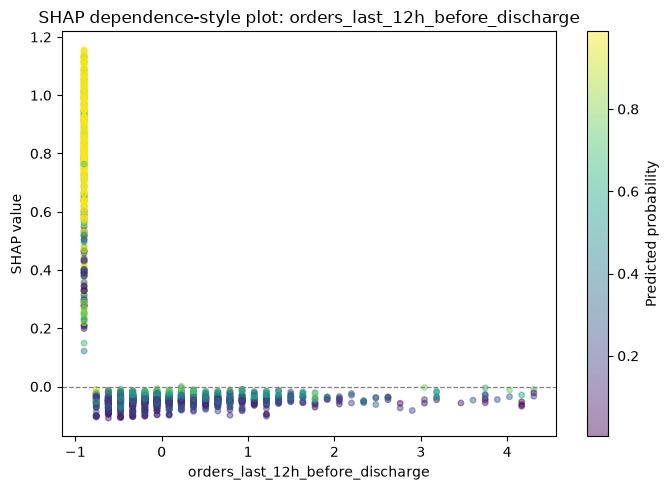

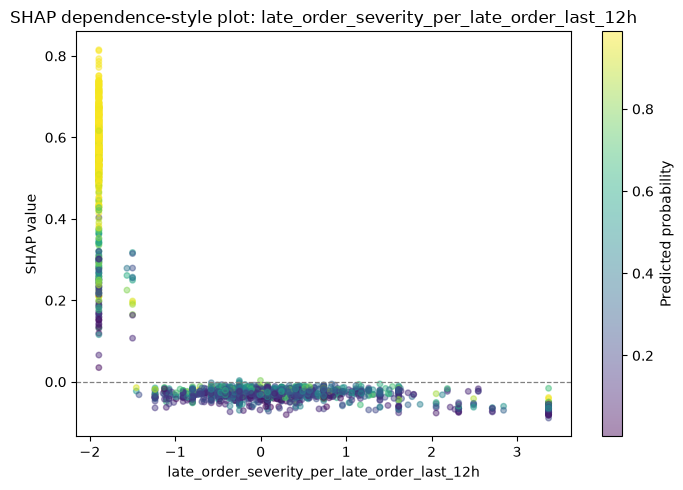

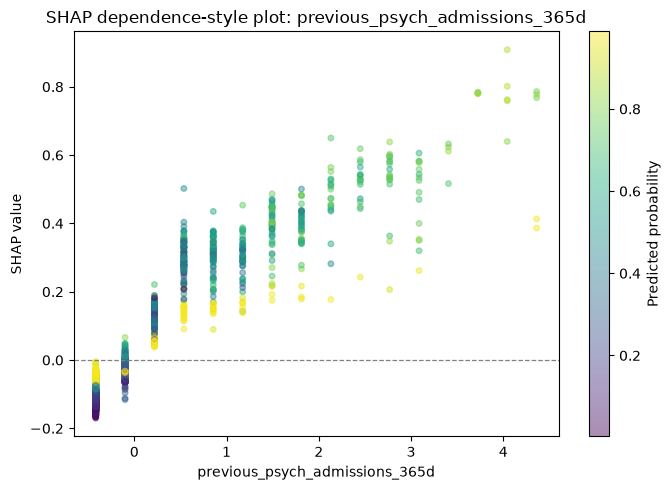

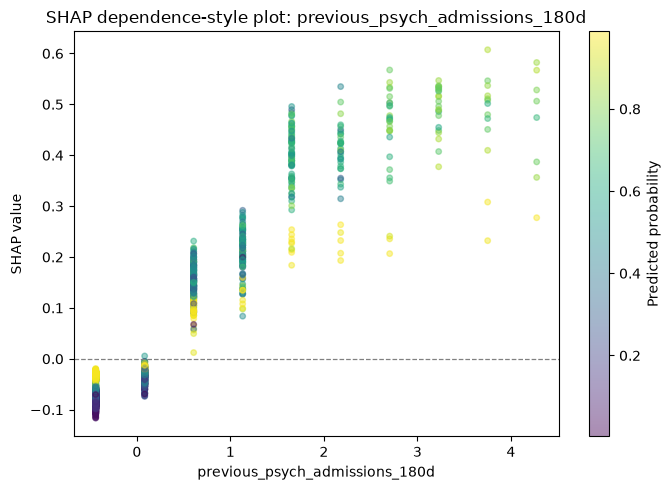

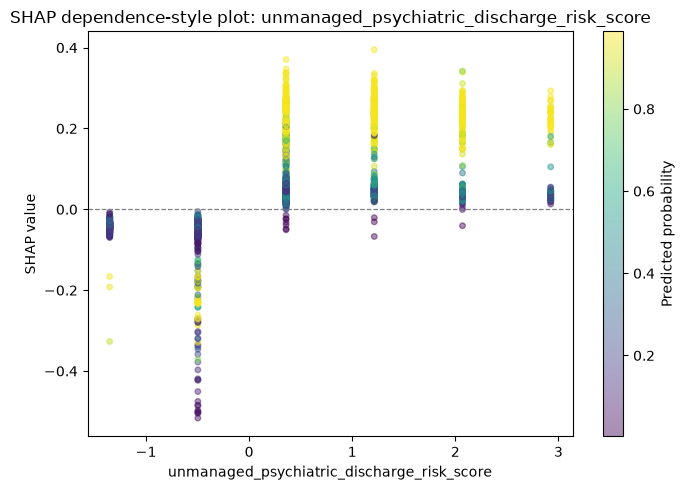

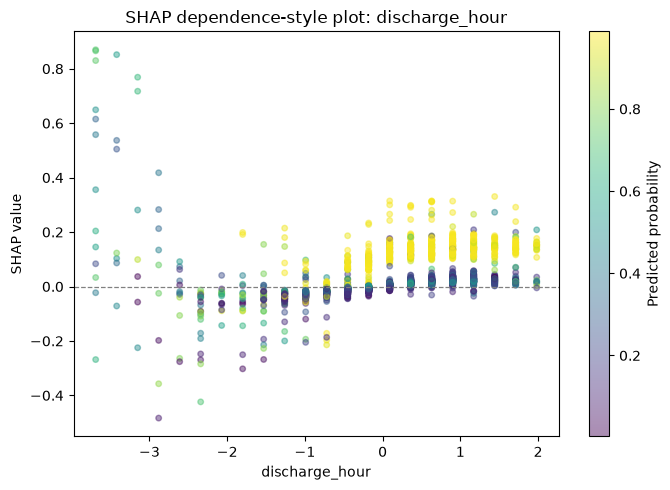

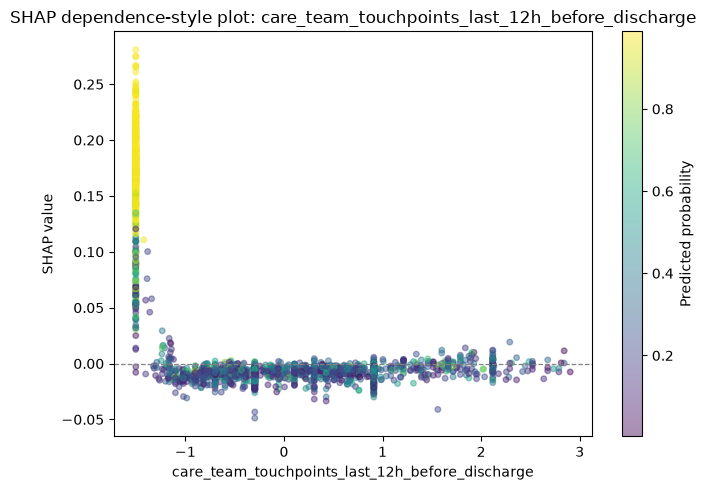

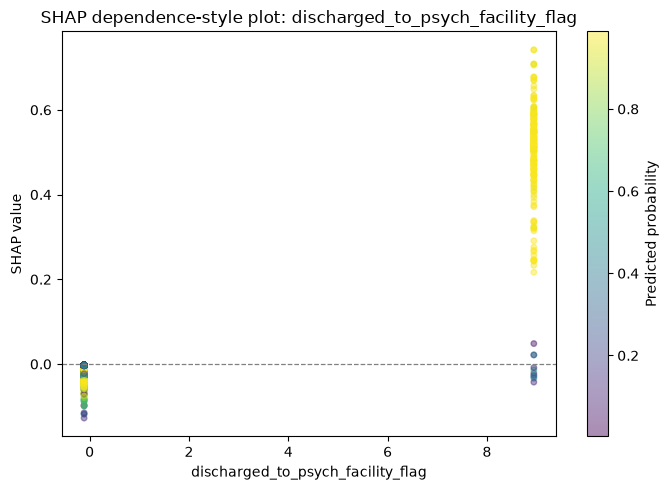

Dependence-style SHAP plots created:


,importance_rank,processed_feature_name,feature_name_clean,feature_family,mean_abs_shap,plotted_rows,raw_rows,x_axis_1st_percentile,x_axis_99th_percentile,selection_method,plot_file
0,1,num__orders_last_12h_before_discharge,orders_last_12h_before_discharge,poe_order_pathway,0.250453,2477,2500,-0.898280,4.308367,top_shap_with_family_cap,/Users/ahthini/Desktop/DissProject/outputs/WP4...
1,2,num__late_order_severity_per_late_order_last_12h,late_order_severity_per_late_order_last_12h,poe_order_pathway,0.172060,2499,2500,-1.894356,3.368940,top_shap_with_family_cap,/Users/ahthini/Desktop/DissProject/outputs/WP4...
2,4,num__previous_psych_admissions_365d,previous_psych_admissions_365d,prior_utilisation,0.135328,2476,2500,-0.419199,4.362055,top_shap_with_family_cap,/Users/ahthini/Desktop/DissProject/outputs/WP4...
3,5,num__previous_psych_admissions_180d,previous_psych_admissions_180d,prior_utilisation,0.103866,2475,2500,-0.440796,4.281060,top_shap_with_family_cap,/Users/ahthini/Desktop/DissProject/outputs/WP4...
4,6,num__unmanaged_psychiatric_discharge_risk_score,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,0.097559,2485,2500,-1.352664,2.925139,top_shap_with_family_cap,/Users/ahthini/Desktop/DissProject/outputs/WP4...
5,10,num__discharge_hour,discharge_hour,discharge_social,0.054176,2472,2500,-3.691629,1.981689,top_shap_with_family_cap,/Users/ahthini/Desktop/DissProject/outputs/WP4...
6,11,num__care_team_touchpoints_last_12h_before_dis...,care_team_touchpoints_last_12h_before_discharge,care_team_complexity,0.051638,2475,2500,-1.502933,2.904419,top_shap_with_family_cap,/Users/ahthini/Desktop/DissProject/outputs/WP4...
7,12,num__discharged_to_psych_facility_flag,discharged_to_psych_facility_flag,psychiatric_history,0.049812,2500,2500,-0.111804,8.944225,top_shap_with_family_cap,/Users/ahthini/Desktop/DissProject/outputs/WP4...


In [112]:
#create dependence-style scatter plots for automatically selected high-ranking predictors
#The candidates are selected from the current SHAP ranking, so this section follows the model actually being explained.
#A small family cap keeps the plots informative instead of filling the page with near-duplicate late-order variables.
dependence_max_features = 8
dependence_max_per_family = 2
minimum_unique_values_for_dependence = 2

ranked_dependence_candidates_df = shap_global_importance_df.copy()
if "feature_family" not in ranked_dependence_candidates_df.columns:
    ranked_dependence_candidates_df["feature_family"] = ranked_dependence_candidates_df["feature_name_clean"].apply(assign_feature_family)

#Dependence plots are most useful for numeric/binary columns with variation in the SHAP sample.
#Very sparse one-hot columns are skipped unless they still have at least two values in the plotted sample.
dependence_feature_candidates = []
dependence_family_counts = {}
for _, feature_row in ranked_dependence_candidates_df.sort_values("importance_rank").iterrows():
    feature_name = feature_row["processed_feature_name"]
    feature_family = feature_row.get("feature_family", "other")
    if feature_name not in processed_feature_names:
        continue
    feature_position = processed_feature_names.index(feature_name)
    feature_values = np.asarray(X_shap_plot[:, feature_position]).ravel()
    finite_feature_values = feature_values[np.isfinite(feature_values)]
    if len(finite_feature_values) == 0 or pd.Series(finite_feature_values).nunique() < minimum_unique_values_for_dependence:
        continue
    if dependence_family_counts.get(feature_family, 0) >= dependence_max_per_family:
        continue
    dependence_feature_candidates.append(feature_name)
    dependence_family_counts[feature_family] = dependence_family_counts.get(feature_family, 0) + 1
    if len(dependence_feature_candidates) >= dependence_max_features:
        break

selected_dependence_candidates_df = ranked_dependence_candidates_df.loc[
    ranked_dependence_candidates_df["processed_feature_name"].isin(dependence_feature_candidates),
    ["importance_rank", "processed_feature_name", "feature_name_clean", "feature_family", "mean_abs_shap"]].sort_values("importance_rank")

print("Dependence-style plot features selected from current SHAP ranking:")
display(selected_dependence_candidates_df)

dependence_rows = []
for feature_name in dependence_feature_candidates:
    feature_position = processed_feature_names.index(feature_name)
    feature_values = np.asarray(X_shap_plot[:, feature_position]).ravel()
    feature_shap_values = shap_values[:, feature_position]
    clean_name = feature_name.replace("num__", "").replace("cat__", "")
    feature_family = shap_global_importance_df.loc[
        shap_global_importance_df["processed_feature_name"].eq(feature_name), "feature_family"].iloc[0]
    importance_rank = int(shap_global_importance_df.loc[
        shap_global_importance_df["processed_feature_name"].eq(feature_name), "importance_rank"].iloc[0])
    mean_abs_shap = float(shap_global_importance_df.loc[
        shap_global_importance_df["processed_feature_name"].eq(feature_name), "mean_abs_shap"].iloc[0])
    plot_df = pd.DataFrame({"feature_value": feature_values,
        "shap_value": feature_shap_values,
        "predicted_probability": shap_diagnostic_index_df["predicted_probability"].values,
        "classification_group": shap_diagnostic_index_df["classification_group"].values})
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["feature_value", "shap_value"])
    if plot_df.empty or plot_df["feature_value"].nunique() < minimum_unique_values_for_dependence:
        continue
    lower_x, upper_x = plot_df["feature_value"].quantile([0.01, 0.99])
    plot_display_df = plot_df.loc[plot_df["feature_value"].between(lower_x, upper_x)].copy()
    output_path = wp4_image_output_path / f"t4_shap_dependence_rank{importance_rank:02d}_{clean_name[:60].replace('/', '_')}.png"
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(plot_display_df["feature_value"], plot_display_df["shap_value"],
        c=plot_display_df["predicted_probability"], cmap="viridis", alpha=0.45, s=16)
    plt.axhline(0, color="gray", linestyle="--", linewidth=0.9)
    plt.xlabel(clean_name)
    plt.ylabel("SHAP value")
    plt.title(f"SHAP dependence-style plot: {clean_name}")
    plt.colorbar(scatter, label="Predicted probability")
    plt.tight_layout()
    plt.savefig(output_path, dpi=260, bbox_inches="tight")
    plt.show()
    plt.close()
    dependence_rows.append({"importance_rank": importance_rank,
        "processed_feature_name": feature_name,
        "feature_name_clean": clean_name,
        "feature_family": feature_family,
        "mean_abs_shap": mean_abs_shap,
        "plotted_rows": len(plot_display_df),
        "raw_rows": len(plot_df),
        "x_axis_1st_percentile": lower_x,
        "x_axis_99th_percentile": upper_x,
        "selection_method": "top_shap_with_family_cap",
        "plot_file": str(output_path)})

shap_dependence_plot_summary_df = pd.DataFrame(dependence_rows)
shap_dependence_plot_summary_df.to_csv(wp4_csv_output_path / "t4_shap_dependence_plot_summary.csv", index=False)
print("Dependence-style SHAP plots created:")
display(shap_dependence_plot_summary_df)


**4.4 - Local Explanations**

This section explains individual admissions. It selects representative true-positive, false-positive, false-negative, and true-negative cases from the held-out explanation sample, then lists the strongest positive and negative SHAP contributors for each case.


In [113]:
#select representative local explanation cases from the SHAP sample
#the official threshold is read from WP3.4 when available; otherwise 0.39 is used as a stable fallback
selected_threshold = wp4_selected_threshold if "wp4_selected_threshold" in globals() else 0.39
if "wp4_selected_threshold" not in globals() and final_performance_path.exists():
    final_performance_df = pd.read_csv(final_performance_path)
    preferred_threshold_rows = final_performance_df.loc[final_performance_df["threshold_role"].isin(["official", "training_f1", "selected"])]
    if not preferred_threshold_rows.empty:
        selected_threshold = float(preferred_threshold_rows.iloc[0]["threshold"])

local_case_df = shap_sample_index_df.copy()
local_case_df["predicted_label"] = (local_case_df["predicted_probability"] >= selected_threshold).astype(int)
local_case_df["classification_group"] = np.select([
    (local_case_df["readmitted_30d"] == 1) & (local_case_df["predicted_label"] == 1),
    (local_case_df["readmitted_30d"] == 0) & (local_case_df["predicted_label"] == 1),
    (local_case_df["readmitted_30d"] == 1) & (local_case_df["predicted_label"] == 0),
    (local_case_df["readmitted_30d"] == 0) & (local_case_df["predicted_label"] == 0)],
    ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")

local_selection_rules = {"high_risk_stratum_case": (None, False),
    "low_risk_stratum_case": (None, True),
    "true_positive_highest_risk": ("true_positive", False),
    "false_positive_highest_risk": ("false_positive", False),
    "false_negative_lowest_risk": ("false_negative", True),
    "true_negative_lowest_risk": ("true_negative", True)}

selected_local_rows = []
for case_label, (classification_group, ascending_probability) in local_selection_rules.items():
    if classification_group is None:
        candidate_rows = local_case_df.copy()
    else:
        candidate_rows = local_case_df.loc[local_case_df["classification_group"] == classification_group].copy()
    if candidate_rows.empty:
        continue
    selected_row = candidate_rows.sort_values("predicted_probability", ascending=ascending_probability).iloc[0].copy()
    selected_row["local_case_label"] = case_label
    selected_local_rows.append(selected_row)

selected_local_cases_df = pd.DataFrame(selected_local_rows).drop_duplicates("test_row_index").reset_index(drop=True)
selected_local_cases_df.to_csv(wp4_csv_output_path / "t4_shap_selected_local_cases.csv", index=False)
print("Selected threshold for local classification:", selected_threshold)
print("Selected local explanation cases:")
display(selected_local_cases_df[["local_case_label", "subject_id", "hadm_id", "readmitted_30d", "predicted_probability", "classification_group"]])


Selected threshold for local classification: 0.4
Selected local explanation cases:


,local_case_label,subject_id,hadm_id,readmitted_30d,predicted_probability,classification_group
0,high_risk_stratum_case,18122969,21943419,1,0.988883,true_positive
1,low_risk_stratum_case,16342851,21954078,0,0.002747,true_negative
2,false_positive_highest_risk,11734212,23219910,0,0.975878,false_positive
3,false_negative_lowest_risk,14897280,21852536,1,0.024393,false_negative


In [114]:
#create local top-contribution tables for the selected admissions
local_top_feature_rows = []
local_summary_rows = []

for _, case_row in selected_local_cases_df.iterrows():
    sample_position = int(case_row.name)
    shap_sample_position = shap_sample_index_df.index[shap_sample_index_df["test_row_index"] == case_row["test_row_index"]].tolist()[0]
    row_shap_values = shap_values[shap_sample_position]
    row_feature_values = X_shap_plot[shap_sample_position]
    log_odds_prediction_from_shap = base_value + row_shap_values.sum()
    probability_prediction_from_shap = expit(log_odds_prediction_from_shap)

    local_summary_rows.append({"local_case_label": case_row["local_case_label"],
        "subject_id": case_row.get("subject_id"),
        "hadm_id": case_row.get("hadm_id"),
        "classification_group": case_row["classification_group"],
        "readmitted_30d": case_row["readmitted_30d"],
        "predicted_probability": case_row["predicted_probability"],
        "shap_reconstructed_probability": probability_prediction_from_shap,
        "shap_base_value_log_odds": base_value,
        "shap_sum_log_odds": row_shap_values.sum()})

    local_feature_df = pd.DataFrame({"processed_feature_name": processed_feature_names,
        "feature_value": row_feature_values,
        "shap_value": row_shap_values})
    local_feature_df["abs_shap_value"] = local_feature_df["shap_value"].abs()
    local_feature_df["feature_name_clean"] = local_feature_df["processed_feature_name"].str.replace("^num__", "", regex=True).str.replace("^cat__", "", regex=True)
    local_feature_df["feature_family"] = local_feature_df["feature_name_clean"].apply(assign_feature_family)
    top_positive_df = local_feature_df.sort_values("shap_value", ascending=False).head(10).copy()
    top_negative_df = local_feature_df.sort_values("shap_value", ascending=True).head(10).copy()
    top_positive_df["contribution_direction"] = "increases_predicted_risk"
    top_negative_df["contribution_direction"] = "decreases_predicted_risk"
    top_local_df = pd.concat([top_positive_df, top_negative_df], ignore_index=True)
    top_local_df.insert(0, "local_case_label", case_row["local_case_label"])
    top_local_df.insert(1, "classification_group", case_row["classification_group"])
    top_local_df.insert(2, "subject_id", case_row.get("subject_id"))
    top_local_df.insert(3, "hadm_id", case_row.get("hadm_id"))
    local_top_feature_rows.append(top_local_df)

local_explanation_summary_df = pd.DataFrame(local_summary_rows)
local_top_features_df = pd.concat(local_top_feature_rows, ignore_index=True) if local_top_feature_rows else pd.DataFrame()

local_explanation_summary_df.to_csv(wp4_csv_output_path / "t4_shap_local_explanation_summary.csv", index=False)
local_top_features_df.to_csv(wp4_csv_output_path / "t4_shap_local_top_features.csv", index=False)

print("Local explanation summary:")
display(local_explanation_summary_df)
print("Local top SHAP features:")
display(local_top_features_df.head(40))


Local explanation summary:


,local_case_label,subject_id,hadm_id,classification_group,readmitted_30d,predicted_probability,shap_reconstructed_probability,shap_base_value_log_odds,shap_sum_log_odds
0,high_risk_stratum_case,18122969,21943419,true_positive,1,0.988883,0.988883,-1.062708,5.550773
1,low_risk_stratum_case,16342851,21954078,true_negative,0,0.002747,0.002747,-1.062708,-4.831907
2,false_positive_highest_risk,11734212,23219910,false_positive,0,0.975878,0.975878,-1.062708,4.762936
3,false_negative_lowest_risk,14897280,21852536,false_negative,1,0.024393,0.024393,-1.062708,-2.626040


Local top SHAP features:


,local_case_label,classification_group,subject_id,hadm_id,processed_feature_name,feature_value,shap_value,abs_shap_value,feature_name_clean,feature_family,contribution_direction
0,high_risk_stratum_case,true_positive,18122969,21943419,num__last_order_close_to_discharge_hours,2.519716,0.935256,0.935256,last_order_close_to_discharge_hours,poe_order_pathway,increases_predicted_risk
1,high_risk_stratum_case,true_positive,18122969,21943419,num__orders_last_12h_before_discharge,-0.898280,0.851522,0.851522,orders_last_12h_before_discharge,poe_order_pathway,increases_predicted_risk
2,high_risk_stratum_case,true_positive,18122969,21943419,num__late_order_severity_per_late_order_last_12h,-1.894356,0.653717,0.653717,late_order_severity_per_late_order_last_12h,poe_order_pathway,increases_predicted_risk
3,high_risk_stratum_case,true_positive,18122969,21943419,num__low_order_activity_with_self_harm_flag,6.975300,0.326900,0.326900,low_order_activity_with_self_harm_flag,poe_order_pathway,increases_predicted_risk
4,high_risk_stratum_case,true_positive,18122969,21943419,num__new_orders_last_12h_before_discharge_flag,-3.252001,0.308435,0.308435,new_orders_last_12h_before_discharge_flag,poe_order_pathway,increases_predicted_risk
5,high_risk_stratum_case,true_positive,18122969,21943419,num__last_order_close_to_discharge_hours_filled,2.519716,0.283760,0.283760,last_order_close_to_discharge_hours_filled,poe_order_pathway,increases_predicted_risk
6,high_risk_stratum_case,true_positive,18122969,21943419,num__unmanaged_psychiatric_discharge_risk_score,0.358457,0.218074,0.218074,unmanaged_psychiatric_discharge_risk_score,psychiatric_history,increases_predicted_risk
7,high_risk_stratum_case,true_positive,18122969,21943419,num__discharged_to_psych_facility_flag,8.944225,0.216635,0.216635,discharged_to_psych_facility_flag,psychiatric_history,increases_predicted_risk
8,high_risk_stratum_case,true_positive,18122969,21943419,num__care_team_touchpoints_last_12h_before_dis...,-1.502933,0.197148,0.197148,care_team_touchpoints_last_12h_before_discharge,care_team_complexity,increases_predicted_risk
9,high_risk_stratum_case,true_positive,18122969,21943419,num__late_psych_safety_activity_score_near_dis...,1.482621,0.118402,0.118402,late_psych_safety_activity_score_near_discharge,psychiatric_history,increases_predicted_risk


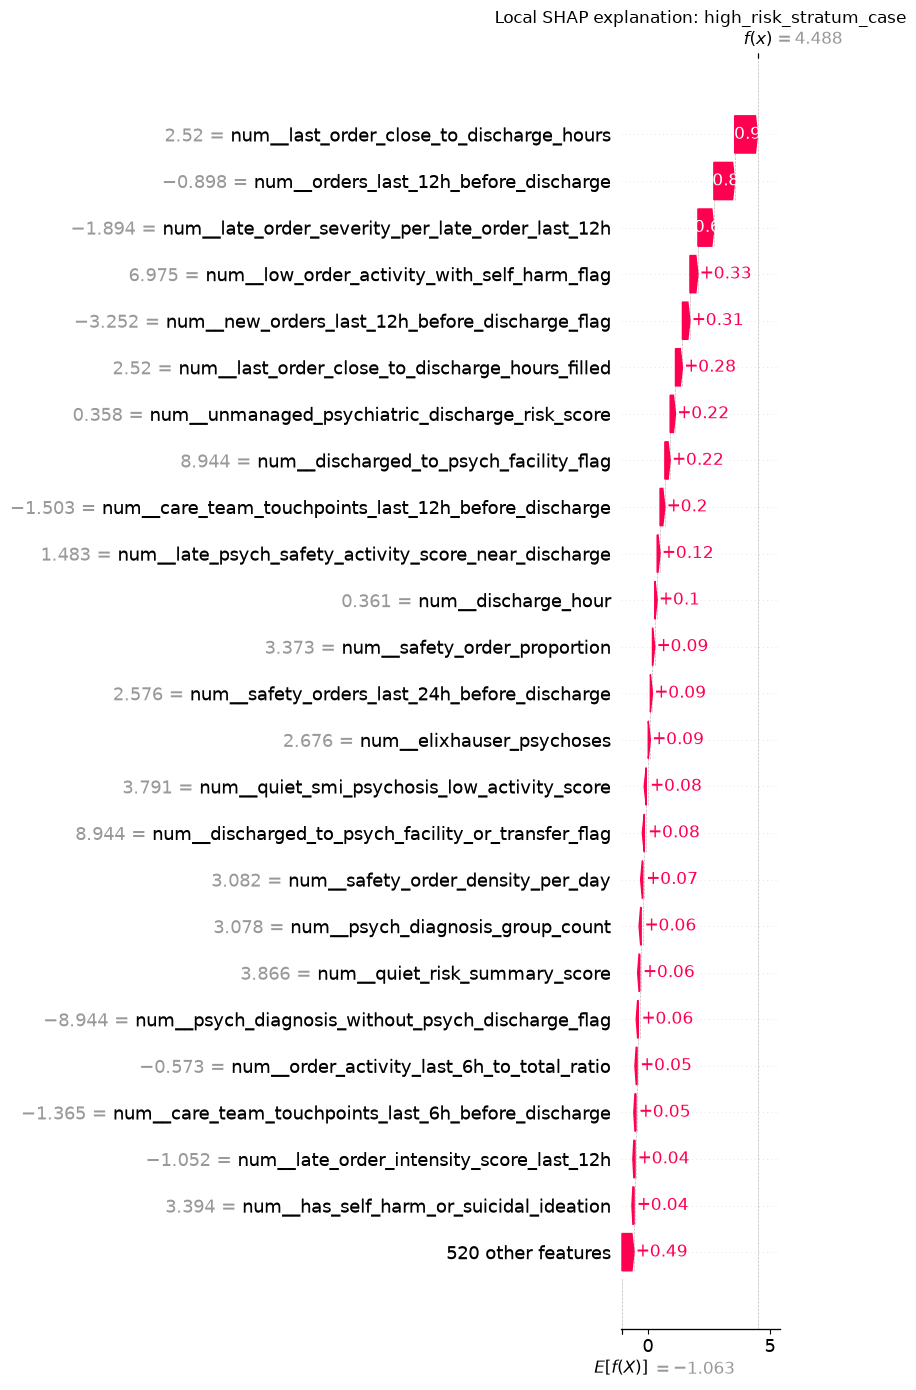

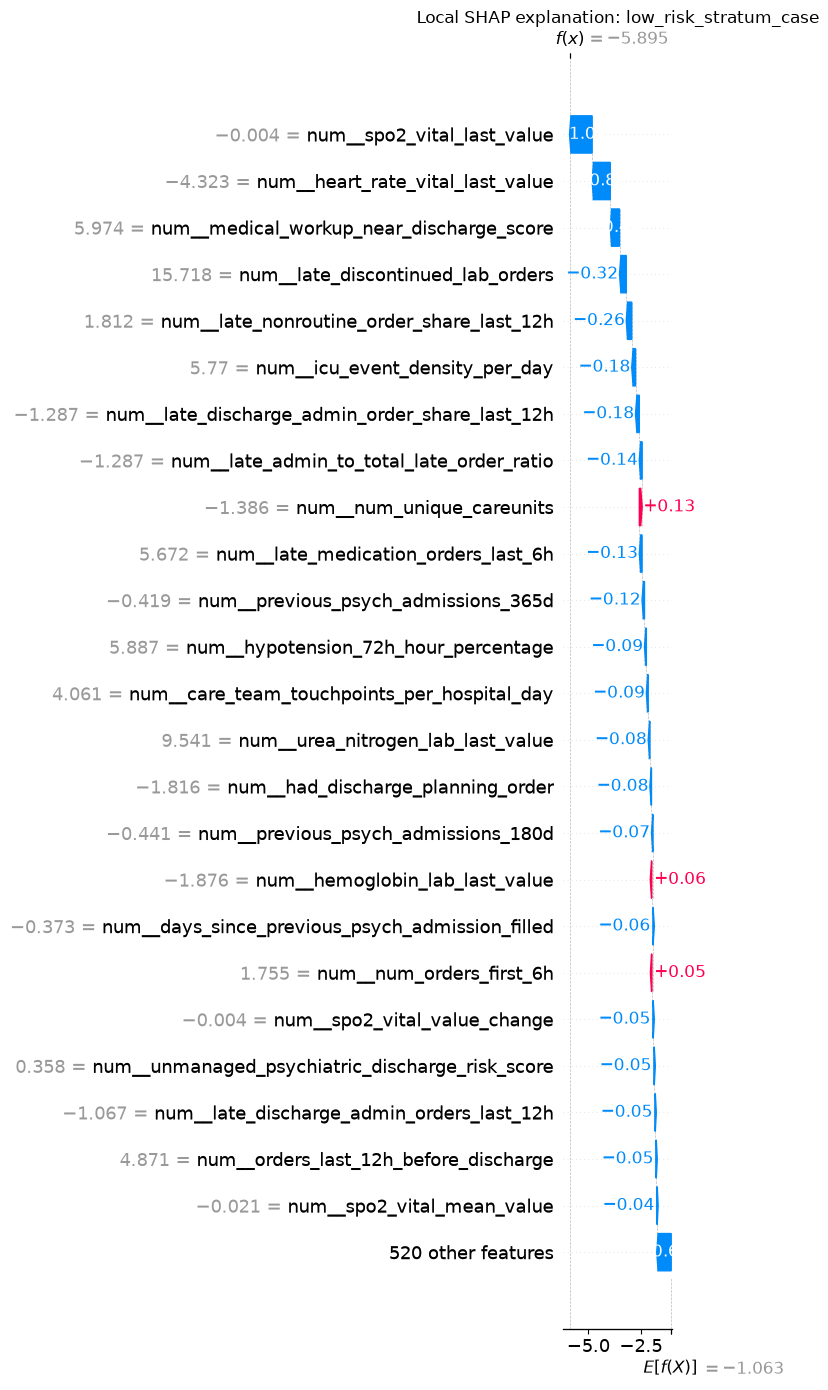

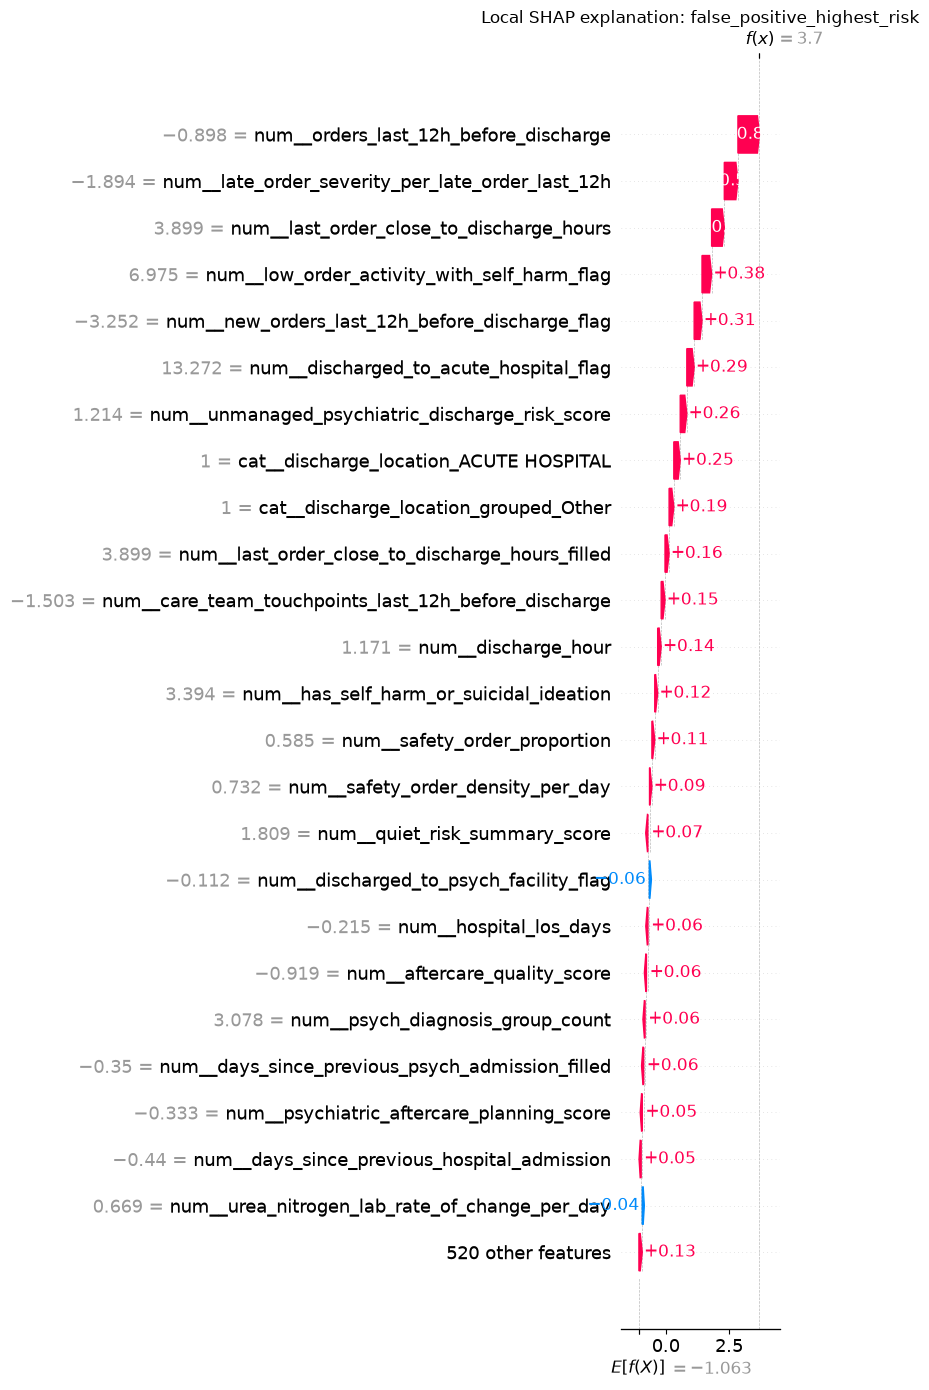

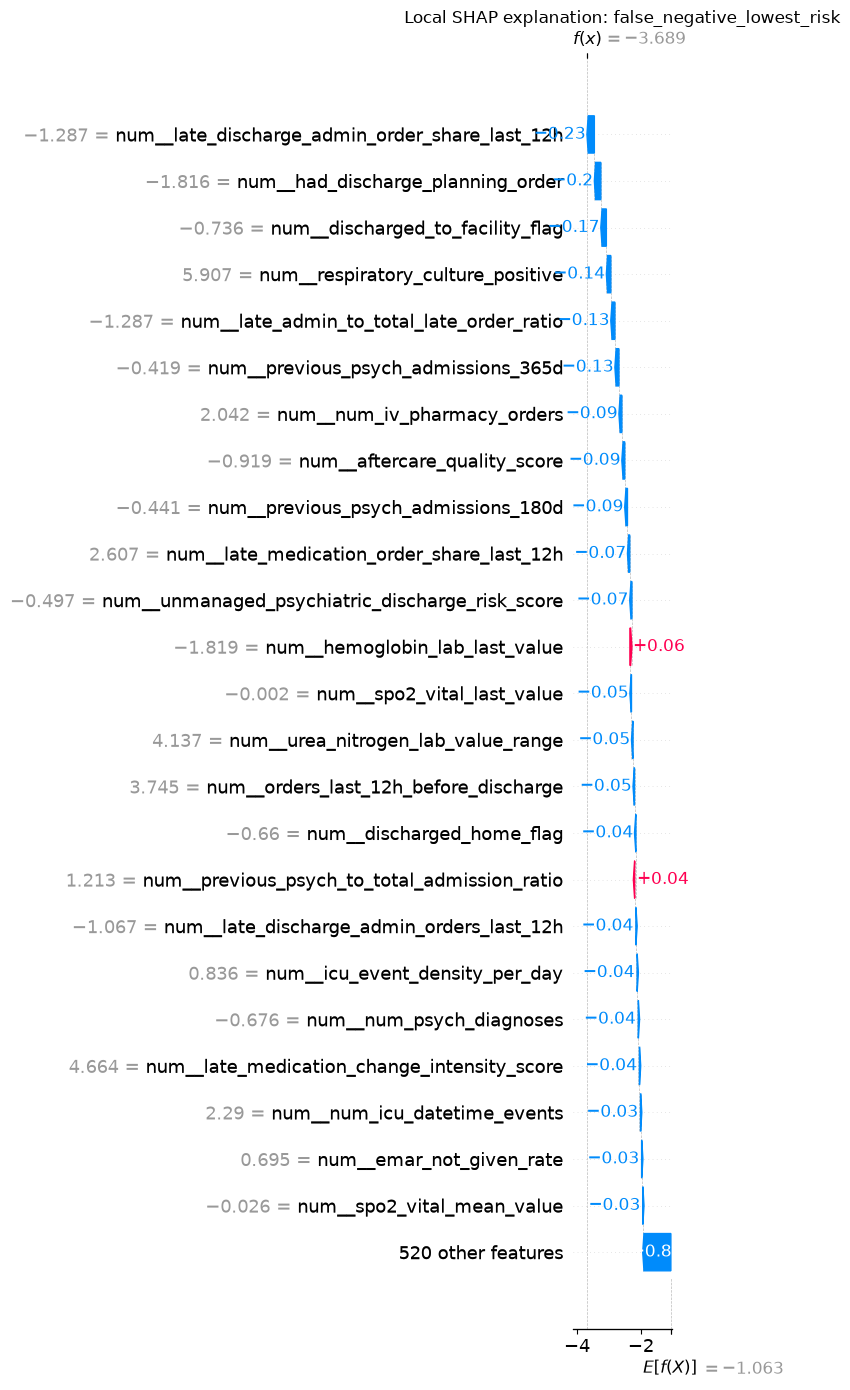

In [115]:
#plot local waterfall charts for selected admissions
for _, case_row in selected_local_cases_df.iterrows():
    shap_sample_position = shap_sample_index_df.index[shap_sample_index_df["test_row_index"] == case_row["test_row_index"]].tolist()[0]
    case_label = case_row["local_case_label"]
    explanation = shap.Explanation(values=shap_values[shap_sample_position],
        base_values=base_value,
        data=X_shap_plot[shap_sample_position],
        feature_names=processed_feature_names)
    plt.figure(figsize=(9, 7))
    shap.plots.waterfall(explanation, max_display=25, show=False)
    plt.title(f"Local SHAP explanation: {case_label}")
    plt.tight_layout()
    plt.savefig(wp4_image_output_path / f"t4_shap_waterfall_{case_label}.png", dpi=300, bbox_inches="tight")
    plt.show()

**4.4.1 - Force Plot Case Examples**

These examples show individual-level explanations for one high-risk admission and one low-risk admission. Force plots are included because they are familiar dissertation-style visuals, but compact bar plots are also exported because they are usually easier to read.


<Figure size 2400x480 with 0 Axes>

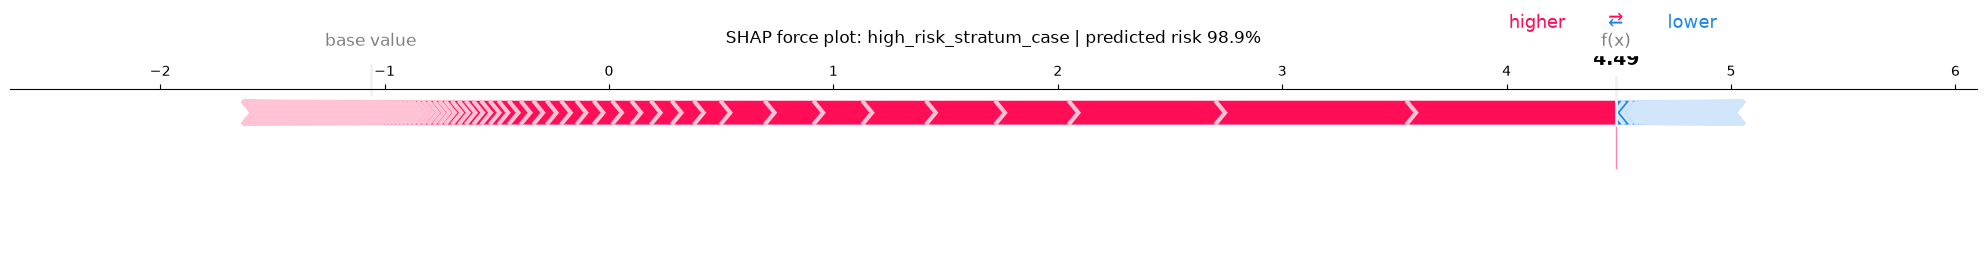

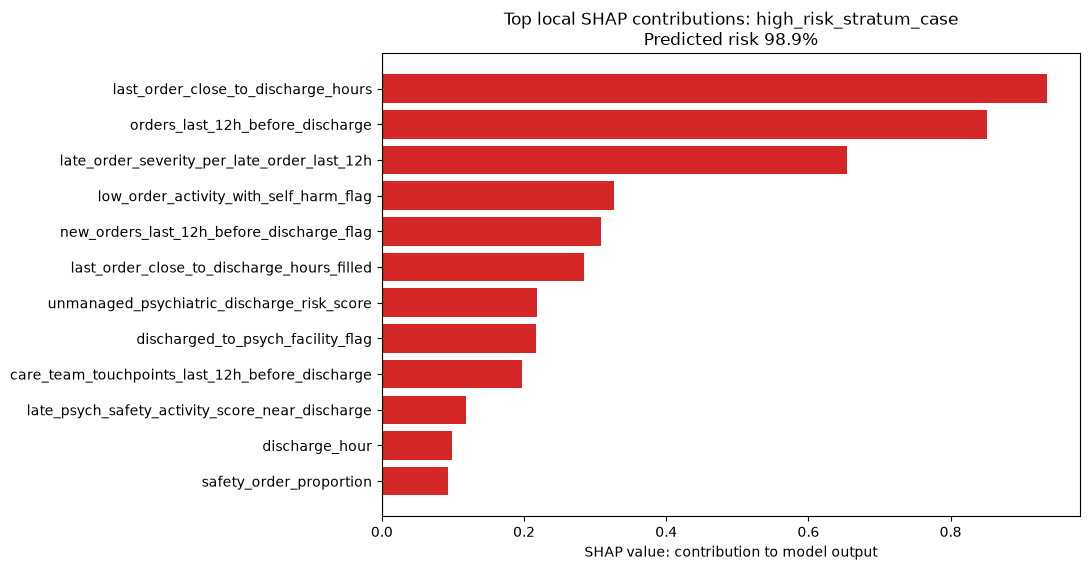

<Figure size 2400x480 with 0 Axes>

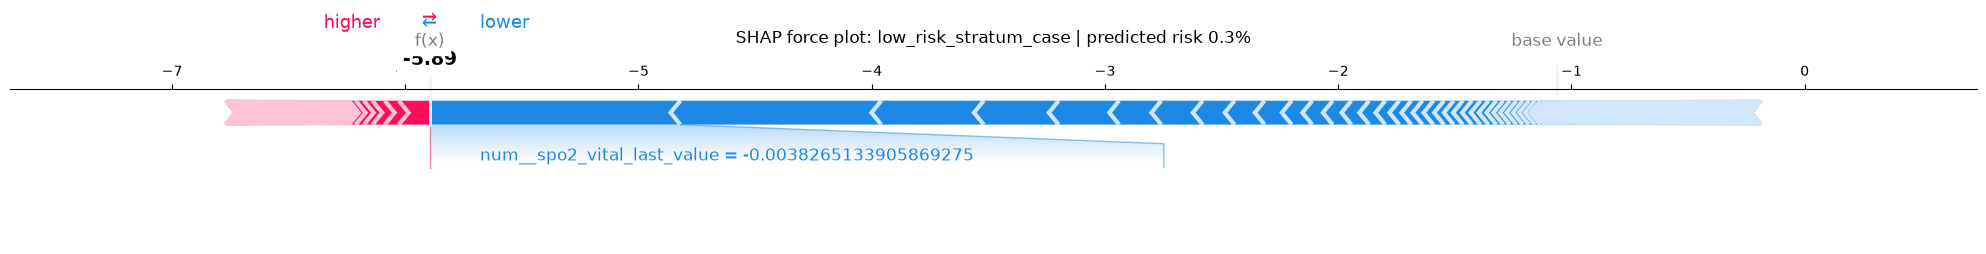

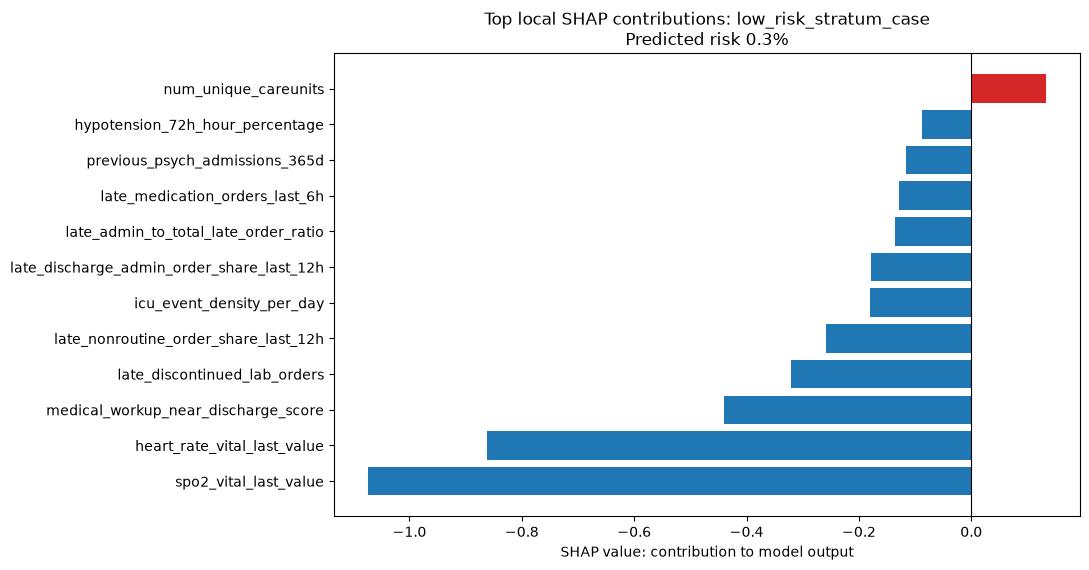

Force plot cases:


,local_case_label,subject_id,hadm_id,readmitted_30d,predicted_probability,classification_group,force_plot_file,local_bar_plot_file
0,high_risk_stratum_case,18122969,21943419,1,0.988883,true_positive,/Users/ahthini/Desktop/DissProject/outputs/WP4...,/Users/ahthini/Desktop/DissProject/outputs/WP4...
1,low_risk_stratum_case,16342851,21954078,0,0.002747,true_negative,/Users/ahthini/Desktop/DissProject/outputs/WP4...,/Users/ahthini/Desktop/DissProject/outputs/WP4...


Top local force/bar features:


,local_case_label,processed_feature_name,feature_value,shap_value,absolute_shap_value,feature_name_clean,predicted_probability
0,high_risk_stratum_case,num__safety_order_proportion,3.3729,0.0931,0.0931,safety_order_proportion,0.9889
1,high_risk_stratum_case,num__discharge_hour,0.3607,0.0993,0.0993,discharge_hour,0.9889
2,high_risk_stratum_case,num__late_psych_safety_activity_score_near_dis...,1.4826,0.1184,0.1184,late_psych_safety_activity_score_near_discharge,0.9889
3,high_risk_stratum_case,num__care_team_touchpoints_last_12h_before_dis...,-1.5029,0.1971,0.1971,care_team_touchpoints_last_12h_before_discharge,0.9889
4,high_risk_stratum_case,num__discharged_to_psych_facility_flag,8.9442,0.2166,0.2166,discharged_to_psych_facility_flag,0.9889
5,high_risk_stratum_case,num__unmanaged_psychiatric_discharge_risk_score,0.3585,0.2181,0.2181,unmanaged_psychiatric_discharge_risk_score,0.9889
6,high_risk_stratum_case,num__last_order_close_to_discharge_hours_filled,2.5197,0.2838,0.2838,last_order_close_to_discharge_hours_filled,0.9889
7,high_risk_stratum_case,num__new_orders_last_12h_before_discharge_flag,-3.2520,0.3084,0.3084,new_orders_last_12h_before_discharge_flag,0.9889
12,low_risk_stratum_case,num__spo2_vital_last_value,-0.0038,-1.0740,1.0740,spo2_vital_last_value,0.0027
13,low_risk_stratum_case,num__heart_rate_vital_last_value,-4.3233,-0.8615,0.8615,heart_rate_vital_last_value,0.0027


In [116]:
#create compact SHAP force plots and clearer local contribution bar plots
force_plot_cases_df = selected_local_cases_df.loc[
    selected_local_cases_df["local_case_label"].isin(["high_risk_stratum_case", "low_risk_stratum_case"])
].copy()

force_plot_summary_rows = []
force_bar_top_feature_rows = []

def shorten_shap_feature_name(feature_name, max_length=58):
    """Keep local plots readable by removing pipeline prefixes and truncating very long names."""
    clean_name = str(feature_name).replace("num__", "").replace("cat__", "")
    if len(clean_name) > max_length:
        return clean_name[:max_length - 3] + "..."
    return clean_name

if force_plot_cases_df.empty:
    print("Force plots skipped because high/low risk local cases were not selected.")
else:
    for _, case_row in force_plot_cases_df.iterrows():
        matching_positions = shap_sample_index_df.index[
            shap_sample_index_df["test_row_index"] == case_row["test_row_index"]].tolist()
        if not matching_positions:
            print("Skipping", case_row["local_case_label"], "because it was not present in the SHAP sample.")
            continue

        shap_sample_position = matching_positions[0]
        case_label = case_row["local_case_label"]
        predicted_probability = float(case_row.get("predicted_probability", np.nan))

        # The force plot is useful conceptually, but the label threshold is deliberately conservative
        # so the exported figure does not become a crowded strip of tiny feature names.
        force_output_path = wp4_image_output_path / f"t4_shap_force_{case_label}.png"
        plt.figure(figsize=(24, 4.8))
        shap.force_plot(base_value, shap_values[shap_sample_position], X_shap_plot[shap_sample_position],
            feature_names=processed_feature_names, matplotlib=True, show=False, contribution_threshold=0.18)
        plt.title(f"SHAP force plot: {case_label} | predicted risk {predicted_probability:.1%}", pad=16)
        plt.tight_layout(pad=1.2)
        plt.savefig(force_output_path, dpi=260, bbox_inches="tight")
        plt.show()
        plt.close()

        # The companion bar plot is the cleaner figure for explaining exactly which variables
        # pushed this patient upward or downward relative to the model baseline.
        local_case_contributions_df = pd.DataFrame({
            "processed_feature_name": processed_feature_names,
            "feature_value": np.asarray(X_shap_plot[shap_sample_position]).ravel(),
            "shap_value": np.asarray(shap_values[shap_sample_position]).ravel()})
        local_case_contributions_df["absolute_shap_value"] = local_case_contributions_df["shap_value"].abs()
        local_case_contributions_df["feature_name_clean"] = local_case_contributions_df["processed_feature_name"].map(
            shorten_shap_feature_name)
        local_case_contributions_df = local_case_contributions_df.sort_values(
            "absolute_shap_value", ascending=False).head(12).sort_values("shap_value")
        local_case_contributions_df.insert(0, "local_case_label", case_label)
        local_case_contributions_df["predicted_probability"] = predicted_probability
        force_bar_top_feature_rows.append(local_case_contributions_df)

        bar_output_path = wp4_image_output_path / f"t4_shap_local_bar_{case_label}.png"
        bar_colours = np.where(local_case_contributions_df["shap_value"] >= 0, "#d62728", "#1f77b4")
        plt.figure(figsize=(11, max(5.8, 0.42 * len(local_case_contributions_df))))
        plt.barh(local_case_contributions_df["feature_name_clean"],
            local_case_contributions_df["shap_value"], color=bar_colours)
        plt.axvline(0, color="black", linewidth=0.8)
        plt.xlabel("SHAP value: contribution to model output")
        plt.title(f"Top local SHAP contributions: {case_label}\nPredicted risk {predicted_probability:.1%}")
        plt.tight_layout()
        plt.savefig(bar_output_path, dpi=260, bbox_inches="tight")
        plt.show()
        plt.close()

        force_plot_summary_rows.append({"local_case_label": case_label,
            "subject_id": case_row.get("subject_id"),
            "hadm_id": case_row.get("hadm_id"),
            "readmitted_30d": case_row.get("readmitted_30d"),
            "predicted_probability": predicted_probability,
            "classification_group": case_row.get("classification_group"),
            "force_plot_file": str(force_output_path),
            "local_bar_plot_file": str(bar_output_path)})

force_plot_summary_df = pd.DataFrame(force_plot_summary_rows)
if force_bar_top_feature_rows:
    force_bar_top_features_df = pd.concat(force_bar_top_feature_rows, ignore_index=True)
else:
    force_bar_top_features_df = pd.DataFrame()

force_plot_summary_df.to_csv(wp4_csv_output_path / "t4_shap_force_plot_case_summary.csv", index=False)
force_bar_top_features_df.to_csv(wp4_csv_output_path / "t4_shap_force_plot_bar_top_features.csv", index=False)
print("Force plot cases:")
display(force_plot_summary_df)
print("Top local force/bar features:")
display(force_bar_top_features_df.groupby("local_case_label").head(8).round(4))


**4.4.2 - Outcome-Window Labels for Explained Cases**

This table keeps the 30-day model fixed and reports whether each locally explained admission became positive in the 14-, 60-, 90-, or 365-day psychiatric readmission windows. It helps interpret cases that are labelled negative at 30 days but may still be clinically close to the target outcome.


In [117]:
#attach wider psychiatric readmission-window labels to selected local SHAP cases when available
#selected_local_cases_df may already contain these columns, so only merge columns that are missing
local_case_window_summary_df = selected_local_cases_df.copy()
requested_window_columns = ["readmitted_14d_psych", "readmitted_60d_psych", "readmitted_90d_psych",
    "readmitted_365d_psych", "days_to_next"]
available_window_columns = [col for col in requested_window_columns if col in explanation_index_df.columns]
missing_window_columns = [col for col in available_window_columns if col not in local_case_window_summary_df.columns]

if missing_window_columns:
    local_case_window_summary_df = local_case_window_summary_df.merge(
        explanation_index_df[["test_row_index"] + missing_window_columns].drop_duplicates("test_row_index"),
        on="test_row_index", how="left")

window_display_columns = [col for col in requested_window_columns if col in local_case_window_summary_df.columns]
if window_display_columns:
    local_case_window_summary_df.to_csv(wp4_csv_output_path / "t4_shap_local_case_outcome_windows.csv", index=False)
    print("Selected local cases with wider outcome-window labels:")
    display_columns = ["local_case_label", "subject_id", "hadm_id", "readmitted_30d",
        "predicted_probability", "classification_group"] + window_display_columns
    display(local_case_window_summary_df[display_columns])
else:
    print("No wider outcome-window columns were available in the prediction file.")


Selected local cases with wider outcome-window labels:


,local_case_label,subject_id,hadm_id,readmitted_30d,predicted_probability,classification_group,readmitted_14d_psych,readmitted_60d_psych,readmitted_90d_psych,readmitted_365d_psych,days_to_next
0,high_risk_stratum_case,18122969,21943419,1,0.988883,true_positive,1,1,1,1,0.0
1,low_risk_stratum_case,16342851,21954078,0,0.002747,true_negative,0,0,0,0,NaN
2,false_positive_highest_risk,11734212,23219910,0,0.975878,false_positive,0,0,0,0,NaN
3,false_negative_lowest_risk,14897280,21852536,1,0.024393,false_negative,1,1,1,1,0.0


**4.5 - Paired SHAP Comparison for the Two Strongest Models**

This section repeats the core SHAP explanation workflow for Targeted LightGBM and Targeted XGBoost. The aim is not to refit either model, but to check whether the two strongest models are using similar clinical signals. LightGBM remains the primary explanation target when it is the best model in WP3.6, while XGBoost is used as a stability comparison.


Running paired SHAP workflow for Targeted LightGBM...


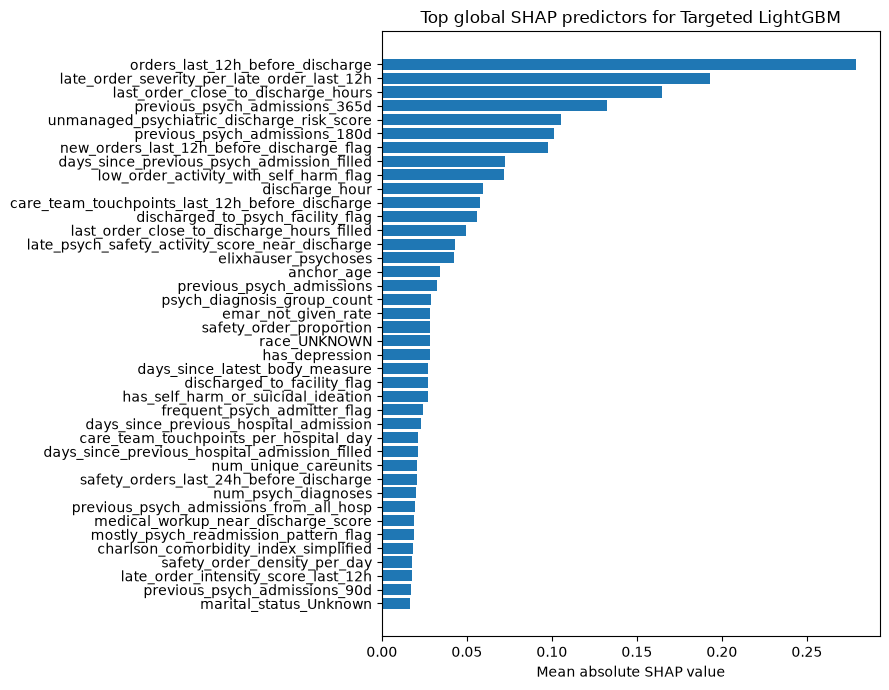

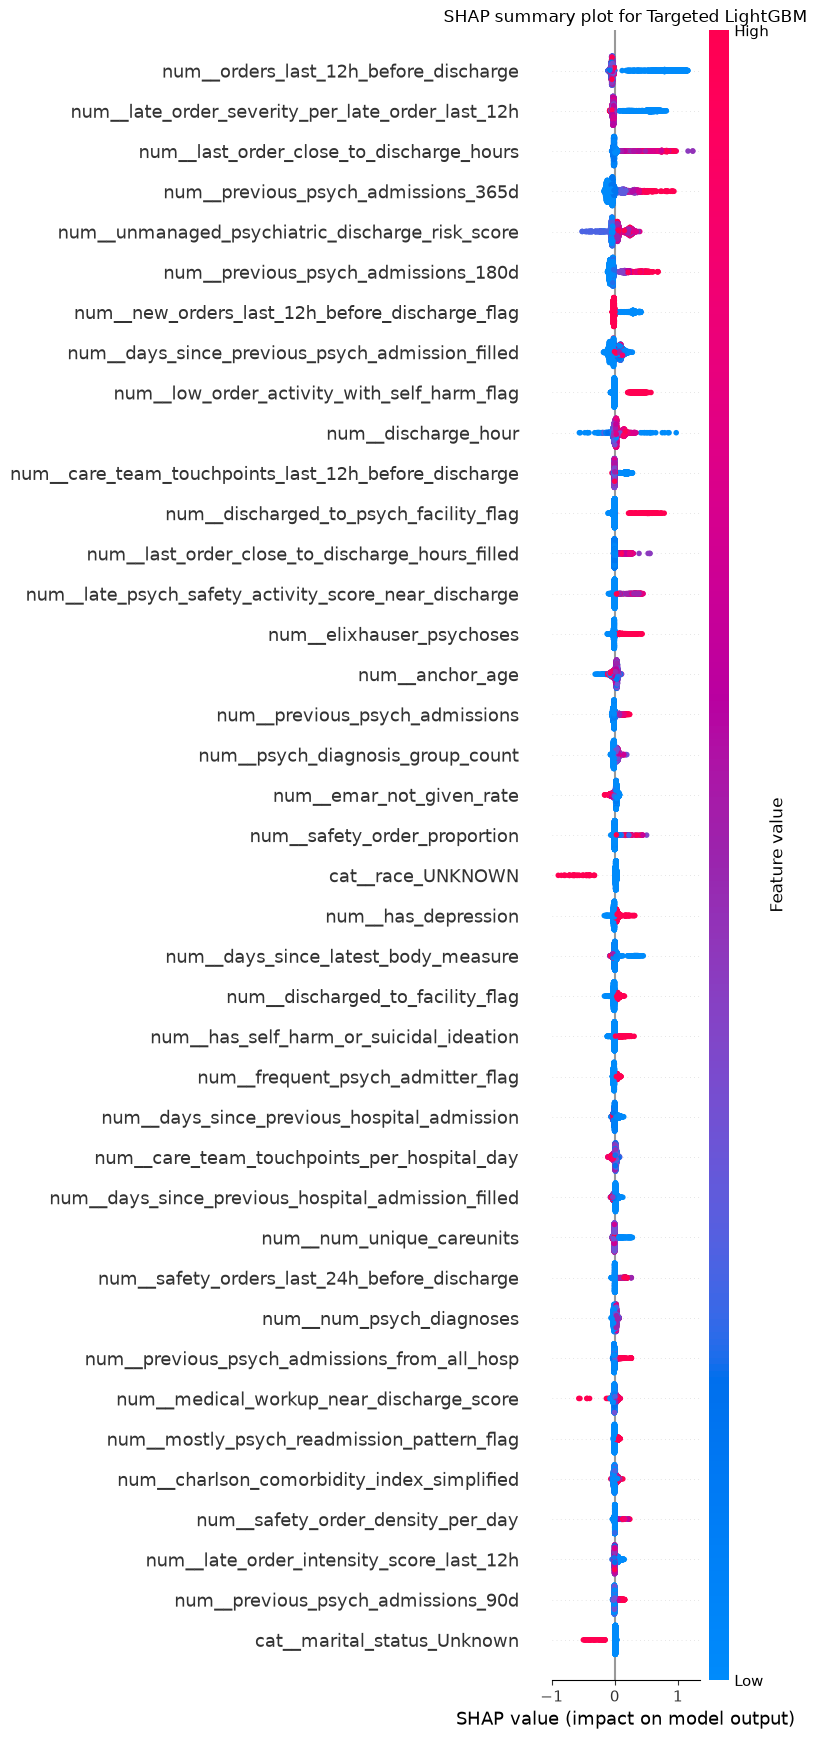

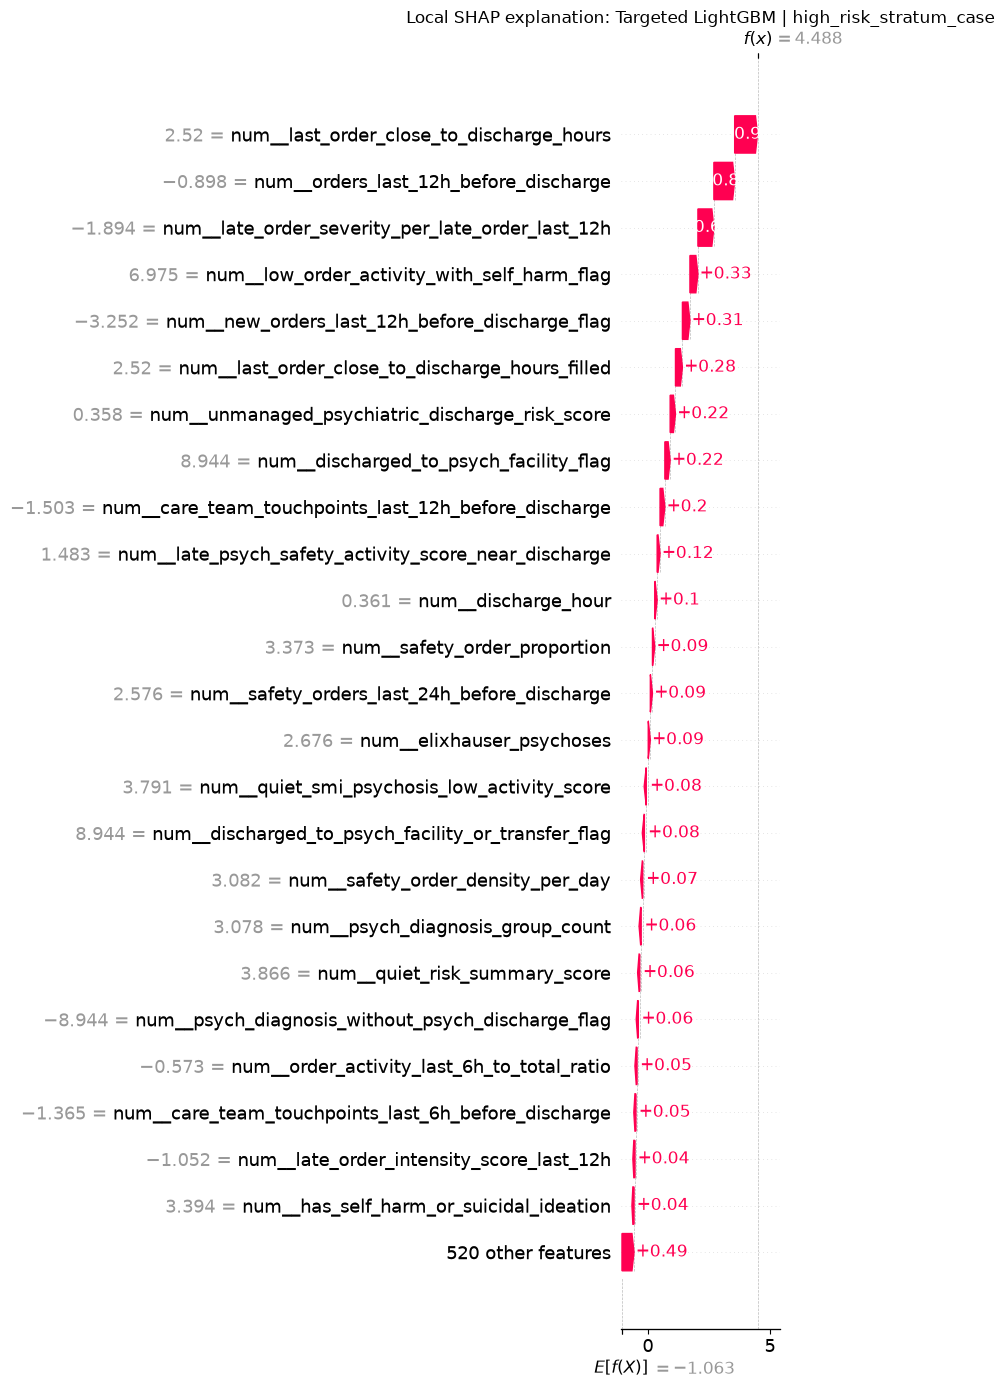

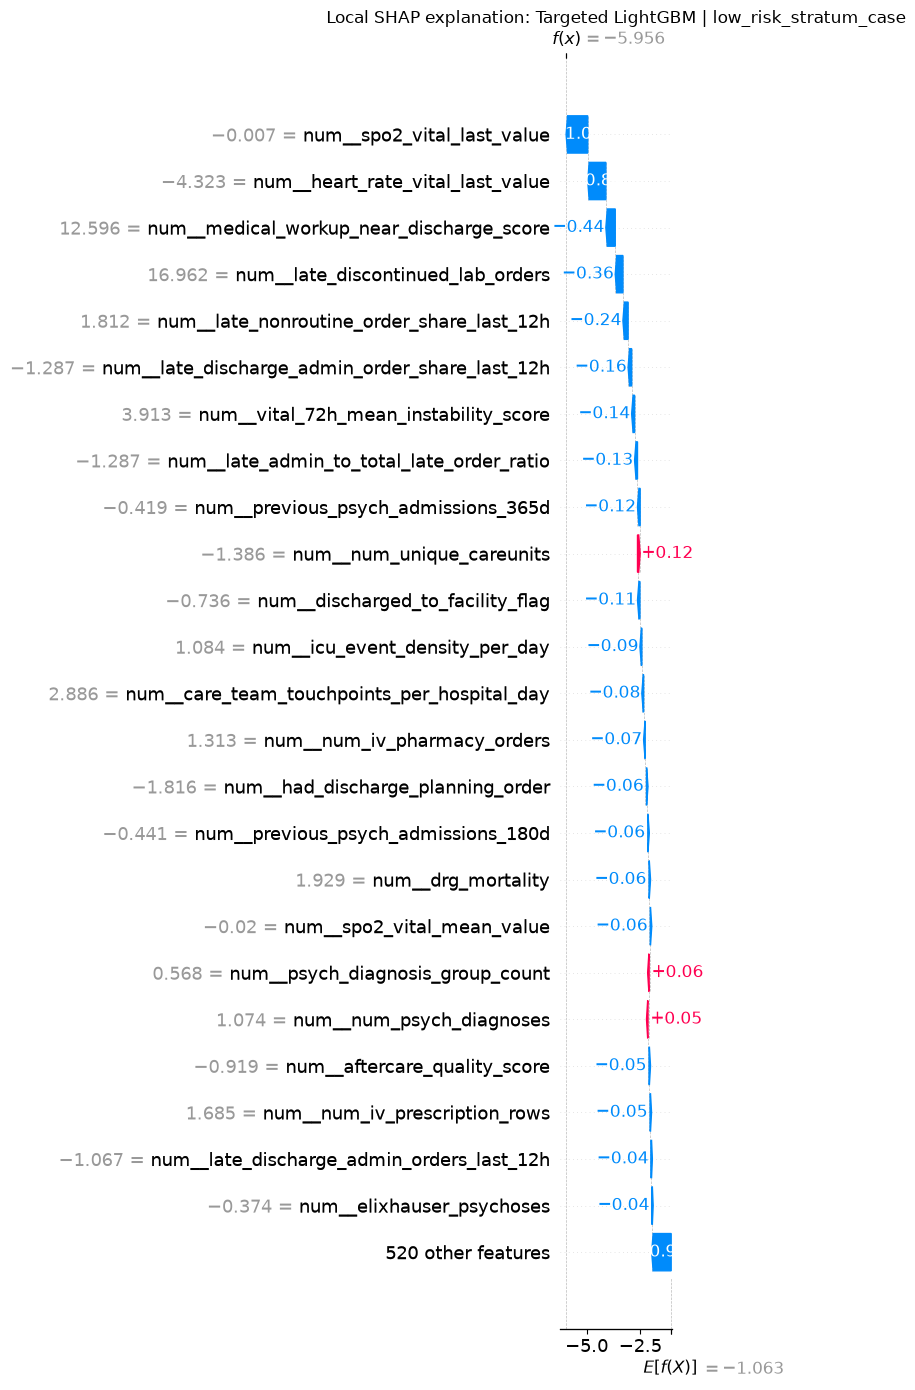

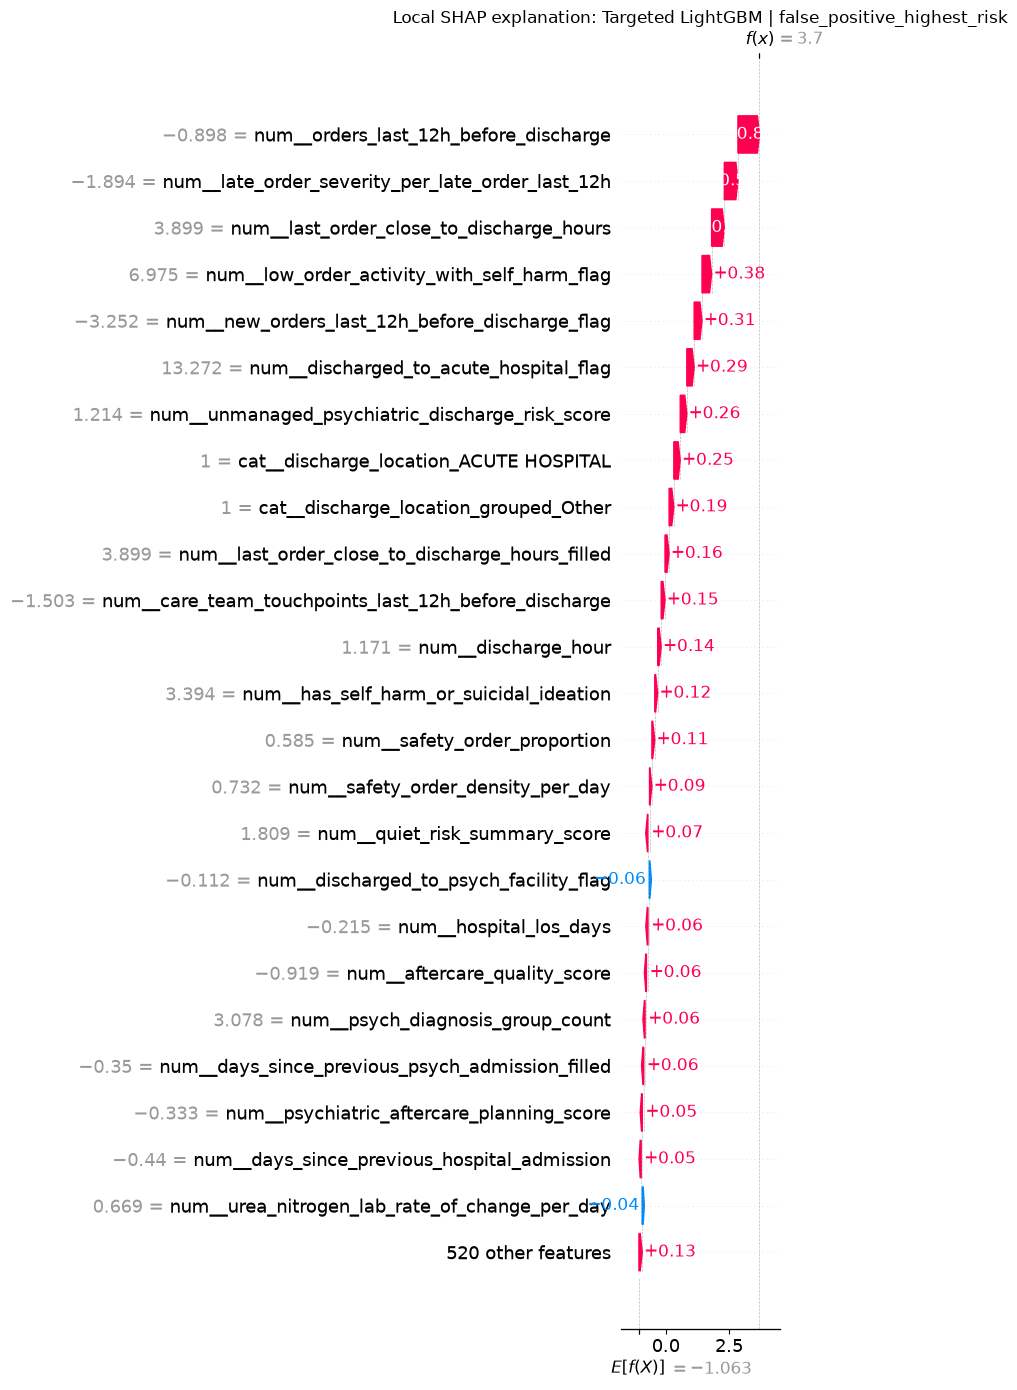

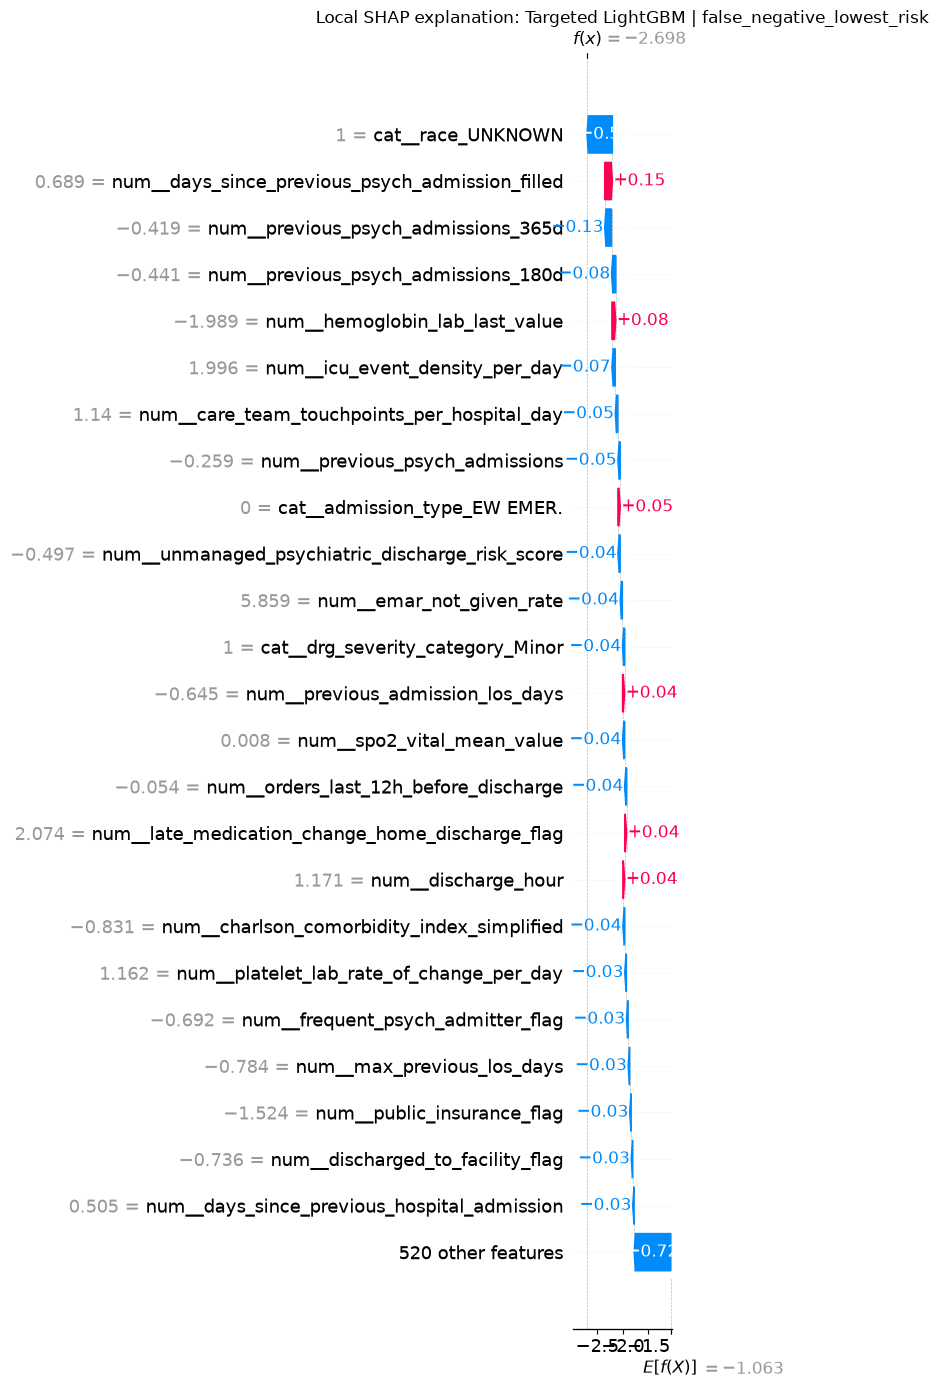


Running paired SHAP workflow for Targeted XGBoost...


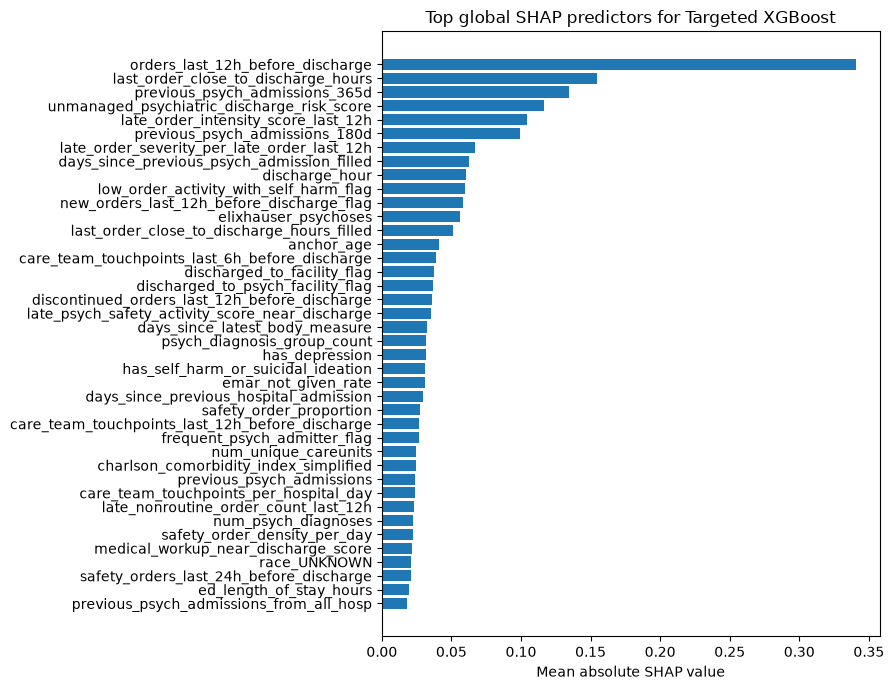

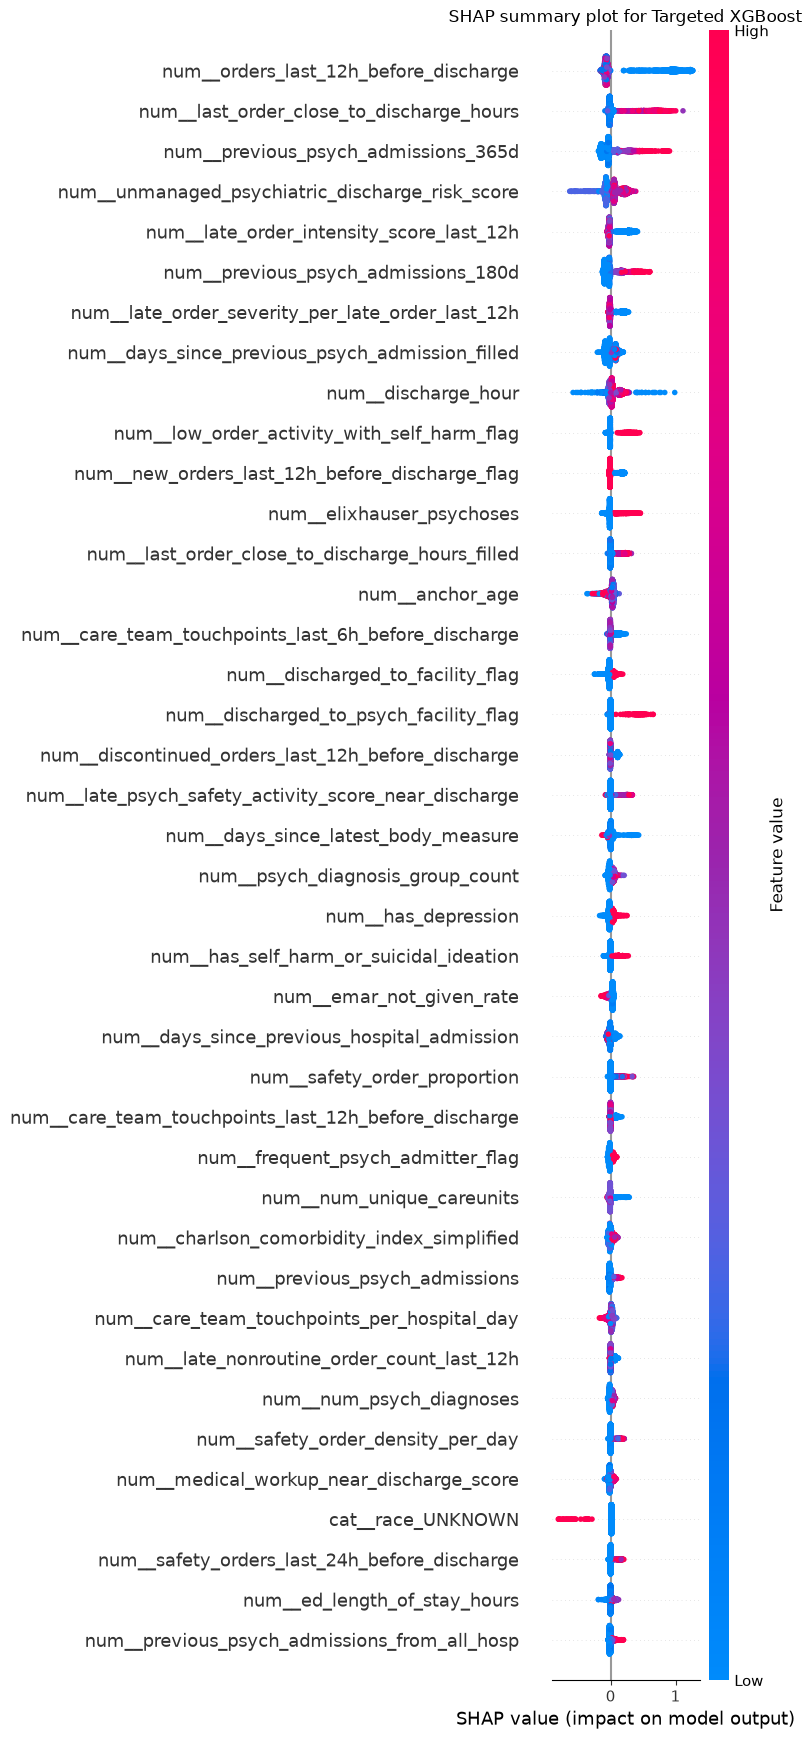

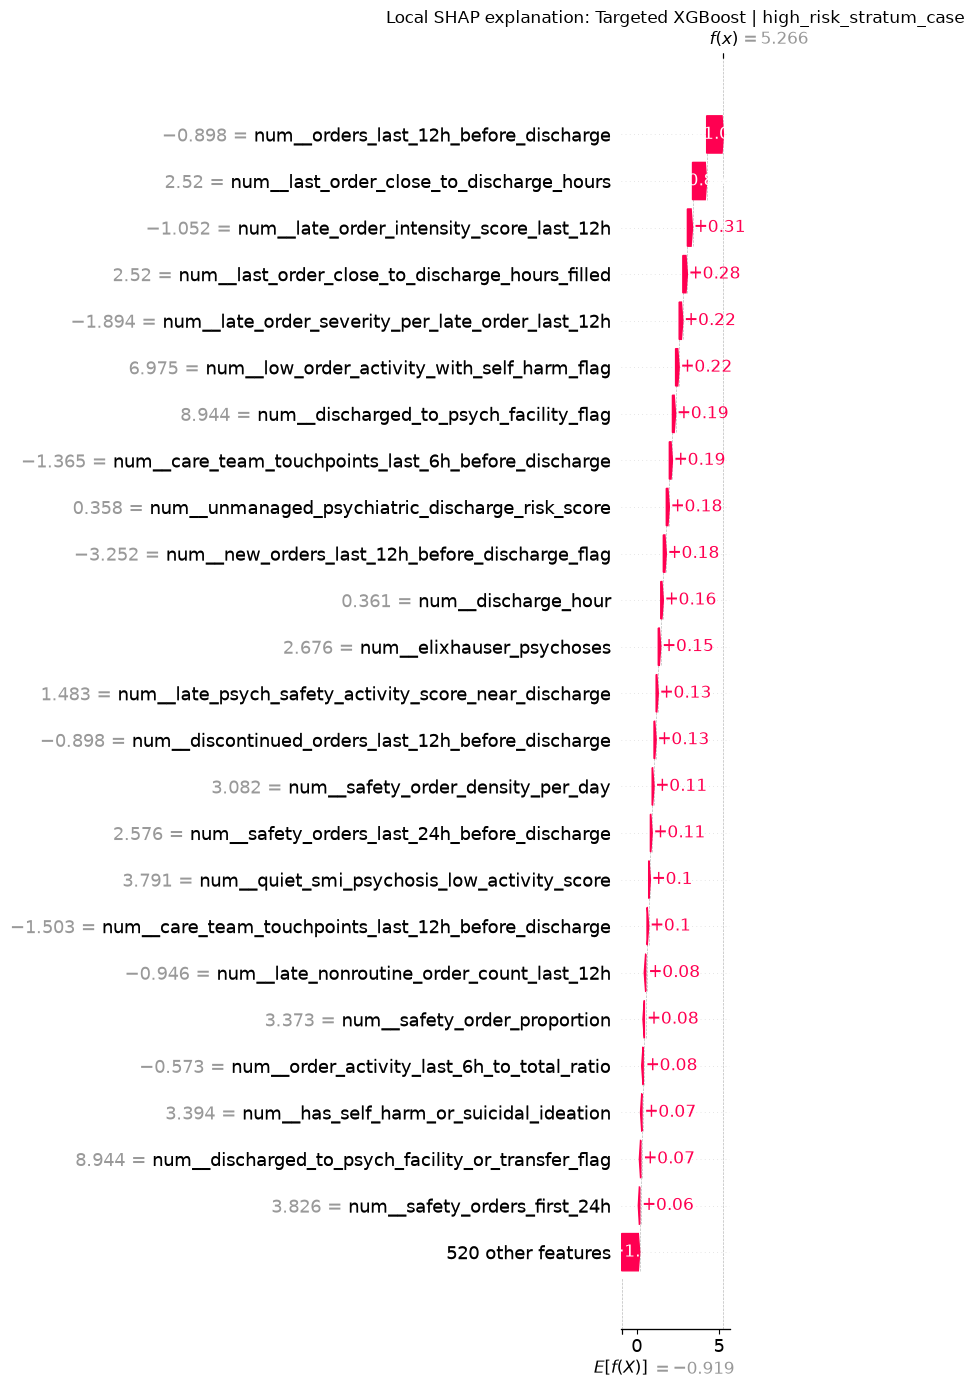

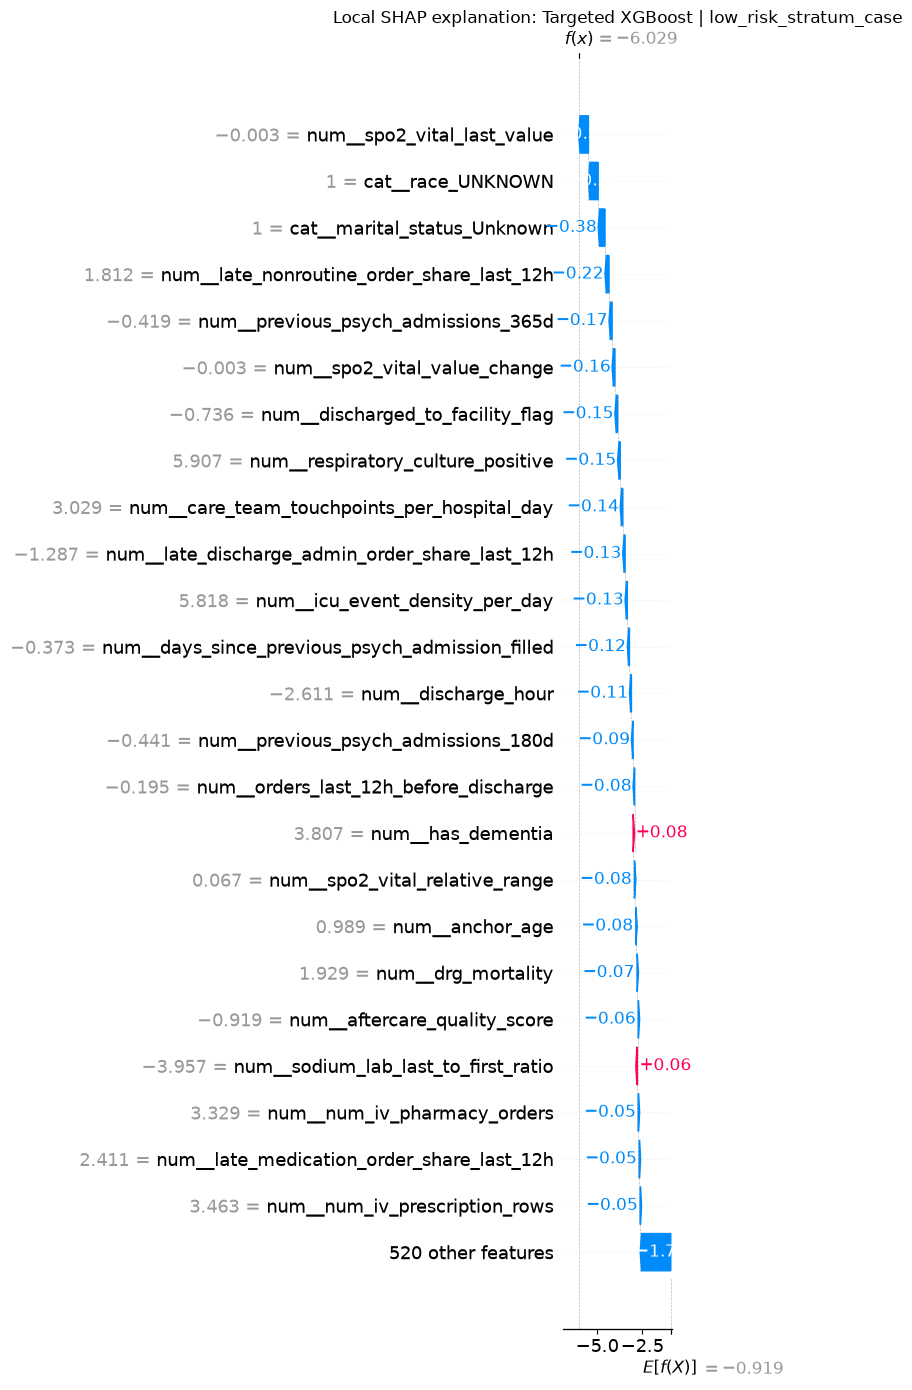

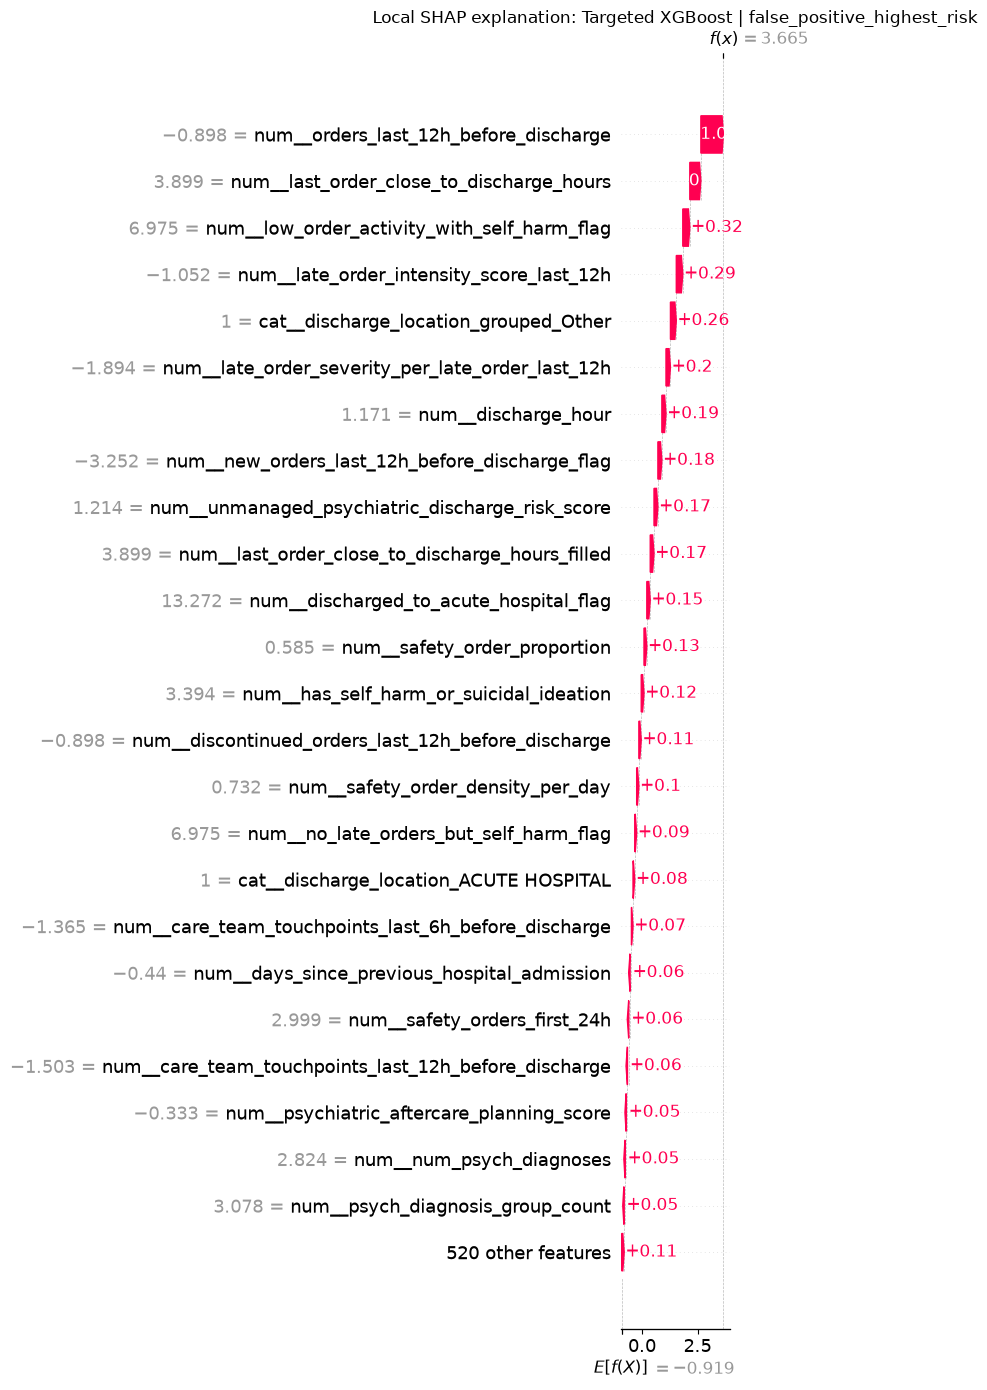

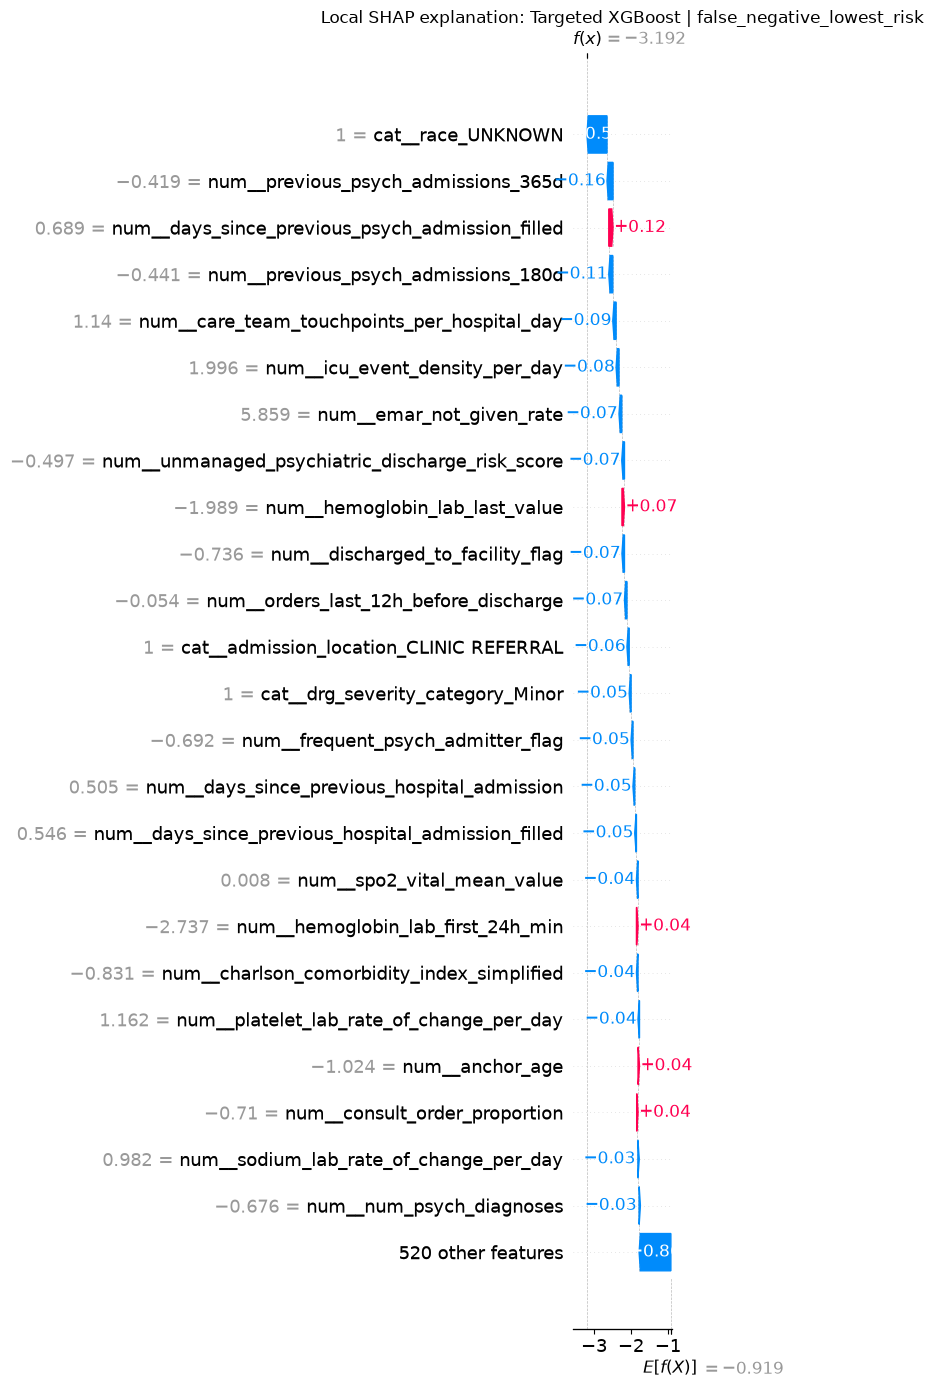

Paired SHAP workflow complete.
Paired SHAP workbook:
/Users/ahthini/Desktop/DissProject/outputs/WP4/t4_shap_paired_model_explanation_tables.xlsx
Paired SHAP methodology summary:


,model_family,model_slug,model_path,prediction_path,matrix_source,test_matrix_path,processed_feature_names_path,test_rows,processed_features,model_expected_features,shap_sample_rows,shap_sample_positive_rows,selected_threshold,shap_expected_value_log_odds,shap_expected_value_probability,shap_elapsed_seconds,global_bar_plot_file,beeswarm_plot_file
0,Targeted LightGBM,targeted_lightgbm,/Users/ahthini/Desktop/DissProject/outputs/WP3...,/Users/ahthini/Desktop/DissProject/outputs/WP3...,shap_guided_reduced_feature_set,/Users/ahthini/Desktop/DissProject/outputs/WP3...,/Users/ahthini/Desktop/DissProject/outputs/WP3...,47171,544,544,2200,1286,0.40,-1.062708,0.256792,15.255630,/Users/ahthini/Desktop/DissProject/outputs/WP4...,/Users/ahthini/Desktop/DissProject/outputs/WP4...
1,Targeted XGBoost,targeted_xgboost,/Users/ahthini/Desktop/DissProject/outputs/WP3...,/Users/ahthini/Desktop/DissProject/outputs/WP3...,shap_guided_reduced_feature_set,/Users/ahthini/Desktop/DissProject/outputs/WP3...,/Users/ahthini/Desktop/DissProject/outputs/WP3...,47171,544,544,2200,1291,0.38,-0.918885,0.285185,2.715884,/Users/ahthini/Desktop/DissProject/outputs/WP4...,/Users/ahthini/Desktop/DissProject/outputs/WP4...


Top feature-family importance by model:


,model_family,model_slug,feature_family,processed_feature_count,total_mean_abs_shap,mean_abs_shap,max_mean_abs_shap,family_importance_rank
0,Targeted LightGBM,targeted_lightgbm,poe_order_pathway,80,1.222379,0.015280,0.279049,1
1,Targeted LightGBM,targeted_lightgbm,prior_utilisation,46,0.617890,0.013432,0.132185,2
2,Targeted LightGBM,targeted_lightgbm,psychiatric_history,41,0.531732,0.012969,0.105647,3
3,Targeted LightGBM,targeted_lightgbm,discharge_social,104,0.290537,0.002794,0.059588,4
4,Targeted LightGBM,targeted_lightgbm,laboratory,106,0.288423,0.002721,0.010831,5
5,Targeted LightGBM,targeted_lightgbm,other,46,0.233580,0.005078,0.027038,6
6,Targeted LightGBM,targeted_lightgbm,medication_emar,32,0.158823,0.004963,0.028502,7
7,Targeted LightGBM,targeted_lightgbm,care_team_complexity,8,0.114759,0.014345,0.057813,8
13,Targeted XGBoost,targeted_xgboost,poe_order_pathway,80,1.316101,0.016451,0.340817,1
14,Targeted XGBoost,targeted_xgboost,prior_utilisation,46,0.649960,0.014130,0.134342,2


In [118]:
#run a paired SHAP explanation workflow for Targeted LightGBM and Targeted XGBoost
#Each model writes to its own WP4 subfolder so outputs do not overwrite each other.
if not shap_available:
    raise ImportError("SHAP is not available in this environment. Install or enable SHAP before running WP4.")

paired_shap_random_state = 42
paired_max_shap_rows = 2200
paired_top_n_global = 40
paired_force_cases = ["high_risk_stratum_case", "low_risk_stratum_case"]

#These fallback family rules mirror the main global-explanation section, so this paired section can run independently.
if "assign_feature_family" not in globals():
    feature_family_rules = [
        ("poe_order_pathway", "poe|order_|orders_|first_order|last_order|order_activity|sitter|observation|suicide_precaution|elopement|restraint_order|psych_consult|social_work|discontinued_orders|unique_order"),
        ("care_team_complexity", "care_team|caregiver|provider|enter_provider|order_provider|provider_order_changes|touchpoints"),
        ("prior_utilisation", "previous_|recent_|days_since_previous|admission_ratio|frequent|high_utiliser"),
        ("psychiatric_history", "psych|depression|bipolar|substance|alcohol|opioid|stimulant|cannabis|tobacco|nicotine|sedative|polysubstance|severe_mental|self_harm|suicidal|psychoses"),
        ("medication_emar", "medication|drug|prescription|pharmacy|emar|antipsychotic|benzodiazepine|mood_stabiliser|mood_stabilizer|lai|iv_prescription|infusion|not_given|dose|prn|scheduled_pharmacy"),
        ("discharge_social", "discharge|insurance|language|marital|race|public_insurance|non_english|facility|home_flag|against_advice"),
        ("ed_pathway", "ed_length|ed_to_|emergency_room|ward_delay|transfer_from|internal_transfer|service_transfer|first_service|last_service|medicine_service|psych_service"),
        ("laboratory", "_lab_|sodium|potassium|creatinine|glucose|wbc|hemoglobin|platelet|urea|culture|microbiology|organism|infection"),
        ("vital_sign", "_vital_|heart_rate|spo2|respiratory|bp_|systolic|mean_bp"),
        ("procedure_comorbidity", "procedure|comorbidity|elixhauser|charlson|bmi|weight|height|obesity|underweight|dialysis|ventilation|ect|central_line|physical"),
        ("icu_care", "icu|careunit"),
        ("admission_context", "admission_type|admission_location|admission_hour|admission_day|admission_month|admission_year|los_days|los_|anchor_age|age_|gender")]

    def assign_feature_family(feature_name):
        for family_name, pattern in feature_family_rules:
            if pd.Series([feature_name]).str.contains(pattern, case=False, regex=True).iloc[0]:
                return family_name
        return "other"

def get_model_expected_feature_count(model):
    expected_features = getattr(model, "n_features_in_", None)
    if expected_features is None and hasattr(model, "get_booster"):
        expected_features = model.get_booster().num_features()
    return int(expected_features) if expected_features is not None else None

def load_matching_test_matrix(model_expected_features):
    candidate_matrix_suffixes = [wp3_input_variant, "clean_feature_audit", "runtime_trimmed_feature_audit", None]
    for matrix_suffix in candidate_matrix_suffixes:
        if matrix_suffix is None:
            candidate_X_test_path = wp3_1_output_path / "t3_1_X_test_processed.npz"
            candidate_feature_names_path = wp3_1_output_path / "t3_1_processed_feature_names.csv"
            candidate_label = "full_processed_matrix"
        else:
            candidate_X_test_path = wp3_1_output_path / f"t3_1_X_test_processed_{matrix_suffix}.npz"
            candidate_feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{matrix_suffix}.csv"
            candidate_label = matrix_suffix
        if not candidate_X_test_path.exists() or not candidate_feature_names_path.exists():
            continue
        candidate_feature_names_df = pd.read_csv(candidate_feature_names_path, usecols=["processed_feature_name"])
        if model_expected_features is None or len(candidate_feature_names_df) == model_expected_features:
            return sparse.load_npz(candidate_X_test_path), candidate_feature_names_df["processed_feature_name"].tolist(), candidate_label, candidate_X_test_path, candidate_feature_names_path
    raise ValueError(f"No WP3.1 processed matrix matches model feature count {model_expected_features}.")

def get_probability_column(prediction_df):
    probability_candidates = ["predicted_probability", "probability", "prediction_probability", "readmission_probability"]
    for column_name in probability_candidates:
        if column_name in prediction_df.columns:
            return column_name
    numeric_columns = prediction_df.select_dtypes(include=[np.number]).columns.tolist()
    likely_probability_columns = [col for col in numeric_columns if "prob" in col.lower() or "risk" in col.lower()]
    if likely_probability_columns:
        return likely_probability_columns[0]
    raise ValueError("Could not identify a predicted-probability column in the prediction file.")

def build_explanation_index(prediction_df, model, X_matrix, y_vector):
    probability_column = get_probability_column(prediction_df)
    id_columns = [col for col in ["subject_id", "hadm_id", "stay_id"] if col in prediction_df.columns]
    if id_columns:
        index_df = prediction_df[id_columns].copy()
    else:
        index_df = test_ids[[col for col in ["subject_id", "hadm_id", "stay_id"] if col in test_ids.columns]].copy()
    if "readmitted_30d" in prediction_df.columns:
        index_df["readmitted_30d"] = prediction_df["readmitted_30d"].astype(int)
    else:
        index_df["readmitted_30d"] = y_vector.values
    index_df["predicted_probability"] = prediction_df[probability_column].astype(float).values
    if len(index_df) != X_matrix.shape[0]:
        index_df = test_ids[[col for col in ["subject_id", "hadm_id", "stay_id"] if col in test_ids.columns]].copy()
        index_df["readmitted_30d"] = y_vector.values
        index_df["predicted_probability"] = model.predict_proba(X_matrix)[:, 1]
    for column_name in ["days_to_next", "readmitted_14d_psych", "readmitted_60d_psych", "readmitted_90d_psych", "readmitted_365d_psych"]:
        if column_name in prediction_df.columns and len(prediction_df) == len(index_df):
            index_df[column_name] = prediction_df[column_name].values
    if "days_to_next" in index_df.columns and "readmitted_14d_psych" not in index_df.columns:
        index_df["readmitted_14d_psych"] = index_df["days_to_next"].between(0, 14, inclusive="both").fillna(False).astype(int)
    index_df["test_row_index"] = np.arange(len(index_df))
    return index_df

def make_shap_sample(index_df, X_matrix):
    rng = np.random.default_rng(paired_shap_random_state)
    positive_indices = index_df.loc[index_df["readmitted_30d"].eq(1), "test_row_index"].to_numpy()
    negative_indices = index_df.loc[index_df["readmitted_30d"].eq(0), "test_row_index"].to_numpy()
    high_risk_indices = index_df.sort_values("predicted_probability", ascending=False).head(500)["test_row_index"].to_numpy()
    positive_sample = rng.choice(positive_indices, size=min(800, len(positive_indices)), replace=False) if len(positive_indices) else np.array([], dtype=int)
    negative_sample = rng.choice(negative_indices, size=min(800, len(negative_indices)), replace=False) if len(negative_indices) else np.array([], dtype=int)
    selected = np.unique(np.concatenate([positive_sample, negative_sample, high_risk_indices])).astype(int)
    remaining_size = max(0, paired_max_shap_rows - len(selected))
    remaining_indices = np.setdiff1d(np.arange(X_matrix.shape[0]), selected)
    random_sample = rng.choice(remaining_indices, size=min(remaining_size, len(remaining_indices)), replace=False) if len(remaining_indices) else np.array([], dtype=int)
    sample_indices = np.unique(np.concatenate([selected, random_sample])).astype(int)[:paired_max_shap_rows]
    return sample_indices, X_matrix[sample_indices], index_df.iloc[sample_indices].copy().reset_index(drop=True)

def compute_tree_shap(model, X_sample, feature_names):
    explainer = shap.TreeExplainer(model)
    try:
        shap_values_raw = explainer.shap_values(X_sample)
        display_matrix = X_sample
    except Exception as sparse_error:
        print("Sparse SHAP calculation failed, retrying with dense matrix:", sparse_error)
        display_matrix = X_sample.toarray() if sparse.issparse(X_sample) else X_sample
        shap_values_raw = explainer.shap_values(display_matrix)
    if "normalise_binary_shap_values" in globals():
        shap_values_processed = normalise_binary_shap_values(shap_values_raw, feature_names)
    else:
        if isinstance(shap_values_raw, list):
            shap_values_processed = shap_values_raw[-1]
        elif hasattr(shap_values_raw, "values"):
            shap_values_processed = shap_values_raw.values
        else:
            shap_values_processed = shap_values_raw
        if sparse.issparse(shap_values_processed):
            shap_values_processed = shap_values_processed.toarray()
        shap_values_processed = np.asarray(shap_values_processed)
        if shap_values_processed.ndim == 3:
            if shap_values_processed.shape[2] == 2:
                shap_values_processed = shap_values_processed[:, :, 1]
            elif shap_values_processed.shape[0] == 2:
                shap_values_processed = shap_values_processed[1, :, :]
            else:
                raise ValueError(f"Unexpected 3D SHAP shape: {shap_values_processed.shape}")
        if shap_values_processed.ndim != 2:
            raise ValueError(f"Expected 2D SHAP values, got {shap_values_processed.shape}")
        if shap_values_processed.shape[1] != len(feature_names):
            raise ValueError(f"SHAP feature mismatch: {shap_values_processed.shape[1]} vs {len(feature_names)}")
    base_value_local = explainer.expected_value
    if isinstance(base_value_local, (list, np.ndarray)):
        base_value_local = np.array(base_value_local).ravel()[-1]
    if sparse.issparse(display_matrix):
        plot_matrix = display_matrix.toarray()
    else:
        plot_matrix = np.asarray(display_matrix)
    return shap_values_processed, float(base_value_local), plot_matrix

def threshold_for_model(model_family, performance_path):
    fallback_threshold = 0.39
    recommended_path = wp3_6_output_path / "csv_tables" / "recommended_model_comparison.csv"
    if recommended_path.exists():
        recommended_df = pd.read_csv(recommended_path)
        model_rows = recommended_df.loc[recommended_df["model_family"].eq(model_family)]
        if not model_rows.empty and "threshold" in model_rows.columns and pd.notna(model_rows.iloc[0]["threshold"]):
            return float(model_rows.iloc[0]["threshold"])
    if performance_path.exists():
        performance_df = pd.read_csv(performance_path)
        if "threshold" in performance_df.columns:
            preferred_rows = performance_df.loc[performance_df.get("threshold_role", pd.Series(index=performance_df.index, dtype=object)).isin(["official", "training_f1", "selected"])]
            if not preferred_rows.empty:
                return float(preferred_rows.iloc[0]["threshold"])
            return float(performance_df.iloc[0]["threshold"])
    return fallback_threshold

def create_error_group_index(sample_index_df, threshold):
    diagnostic_df = sample_index_df.copy()
    diagnostic_df["predicted_label"] = (diagnostic_df["predicted_probability"] >= threshold).astype(int)
    diagnostic_df["classification_group"] = np.select([
        (diagnostic_df["readmitted_30d"] == 1) & (diagnostic_df["predicted_label"] == 1),
        (diagnostic_df["readmitted_30d"] == 0) & (diagnostic_df["predicted_label"] == 1),
        (diagnostic_df["readmitted_30d"] == 1) & (diagnostic_df["predicted_label"] == 0),
        (diagnostic_df["readmitted_30d"] == 0) & (diagnostic_df["predicted_label"] == 0)],
        ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")
    return diagnostic_df

def make_shap_summary_tables(model_family, model_slug, feature_names, shap_values_model, diagnostic_df):
    global_df = pd.DataFrame({
        "model_family": model_family,
        "model_slug": model_slug,
        "processed_feature_name": feature_names,
        "mean_abs_shap": np.abs(shap_values_model).mean(axis=0),
        "mean_signed_shap": shap_values_model.mean(axis=0),
        "std_shap": shap_values_model.std(axis=0)}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    global_df["importance_rank"] = np.arange(1, len(global_df) + 1)
    global_df["feature_name_clean"] = global_df["processed_feature_name"].str.replace("^num__", "", regex=True).str.replace("^cat__", "", regex=True)
    global_df["feature_type"] = np.where(global_df["processed_feature_name"].str.startswith("cat__"), "categorical_encoded", "numeric_or_binary")
    global_df["feature_family"] = global_df["feature_name_clean"].apply(assign_feature_family)

    family_df = global_df.groupby(["model_family", "model_slug", "feature_family"], as_index=False).agg(
        processed_feature_count=("processed_feature_name", "size"),
        total_mean_abs_shap=("mean_abs_shap", "sum"),
        mean_abs_shap=("mean_abs_shap", "mean"),
        max_mean_abs_shap=("mean_abs_shap", "max"))
    family_df = family_df.sort_values(["model_family", "total_mean_abs_shap"], ascending=[True, False]).reset_index(drop=True)
    family_df["family_importance_rank"] = family_df.groupby("model_family")["total_mean_abs_shap"].rank(method="first", ascending=False).astype(int)

    top5_df = global_df.sort_values(["feature_family", "mean_abs_shap"], ascending=[True, False]).groupby("feature_family", as_index=False).head(5).copy()
    top5_df["feature_rank_within_family"] = top5_df.groupby("feature_family")["mean_abs_shap"].rank(method="first", ascending=False).astype(int)

    shap_long = pd.DataFrame(shap_values_model, columns=feature_names)
    shap_long.insert(0, "shap_sample_position", np.arange(shap_long.shape[0]))
    shap_long = shap_long.melt(id_vars="shap_sample_position", var_name="processed_feature_name", value_name="shap_value")
    shap_long = shap_long.merge(global_df[["processed_feature_name", "feature_name_clean", "feature_family", "mean_abs_shap"]], on="processed_feature_name", how="left")
    shap_long = shap_long.merge(
        diagnostic_df[["classification_group", "predicted_probability", "readmitted_30d"]].reset_index().rename(columns={"index": "shap_sample_position"}),
        on="shap_sample_position", how="left")
    shap_long["abs_shap_value"] = shap_long["shap_value"].abs()

    error_mean_df = shap_long.groupby(["classification_group", "processed_feature_name", "feature_name_clean", "feature_family"], as_index=False).agg(
        sample_feature_rows=("shap_value", "size"),
        mean_shap_value=("shap_value", "mean"),
        mean_abs_shap_value=("abs_shap_value", "mean"))
    error_mean_df.insert(0, "model_family", model_family)
    error_mean_df.insert(1, "model_slug", model_slug)
    error_mean_df = error_mean_df.sort_values(["classification_group", "mean_abs_shap_value"], ascending=[True, False]).reset_index(drop=True)

    error_family_df = shap_long.groupby(["classification_group", "feature_family"], as_index=False).agg(
        total_abs_shap=("abs_shap_value", "sum"),
        mean_abs_shap=("abs_shap_value", "mean"),
        mean_signed_shap=("shap_value", "mean"))
    error_family_df.insert(0, "model_family", model_family)
    error_family_df.insert(1, "model_slug", model_slug)
    error_family_df = error_family_df.sort_values(["classification_group", "total_abs_shap"], ascending=[True, False]).reset_index(drop=True)

    def contrast(group_a, group_b, output_label):
        a = error_mean_df.loc[error_mean_df["classification_group"].eq(group_a), ["processed_feature_name", "mean_shap_value", "mean_abs_shap_value"]].rename(
            columns={"mean_shap_value": f"{group_a}_mean_shap", "mean_abs_shap_value": f"{group_a}_mean_abs_shap"})
        b = error_mean_df.loc[error_mean_df["classification_group"].eq(group_b), ["processed_feature_name", "mean_shap_value", "mean_abs_shap_value"]].rename(
            columns={"mean_shap_value": f"{group_b}_mean_shap", "mean_abs_shap_value": f"{group_b}_mean_abs_shap"})
        out = a.merge(b, on="processed_feature_name", how="inner")
        out = out.merge(global_df[["processed_feature_name", "feature_name_clean", "feature_family", "importance_rank", "mean_abs_shap"]], on="processed_feature_name", how="left")
        out["mean_shap_difference"] = out[f"{group_a}_mean_shap"] - out[f"{group_b}_mean_shap"]
        out["abs_mean_shap_difference"] = out["mean_shap_difference"].abs()
        out.insert(0, "model_family", model_family)
        out.insert(1, "model_slug", model_slug)
        out.insert(2, "contrast", output_label)
        return out.sort_values("abs_mean_shap_difference", ascending=False).reset_index(drop=True)

    return {
        "global_importance": global_df,
        "feature_family_importance": family_df,
        "top5_features_by_family": top5_df,
        "error_group_mean": error_mean_df,
        "error_group_family": error_family_df,
        "fp_vs_tp_contrast": contrast("false_positive", "true_positive", "fp_vs_tp"),
        "fn_vs_tp_contrast": contrast("false_negative", "true_positive", "fn_vs_tp"),
        "fn_vs_tn_contrast": contrast("false_negative", "true_negative", "fn_vs_tn")}

def save_core_plots(model_family, model_slug, feature_names, shap_values_model, plot_matrix, global_df, image_dir):
    image_dir.mkdir(parents=True, exist_ok=True)
    top_df = global_df.head(paired_top_n_global).sort_values("mean_abs_shap", ascending=True)
    plt.figure(figsize=(9, 7))
    plt.barh(top_df["feature_name_clean"], top_df["mean_abs_shap"], color="#1f77b4")
    plt.xlabel("Mean absolute SHAP value")
    plt.title(f"Top global SHAP predictors for {model_family}")
    plt.tight_layout()
    bar_path = image_dir / f"t4_shap_{model_slug}_top_global_importance.png"
    plt.savefig(bar_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(3, 7))
    shap.summary_plot(shap_values_model, plot_matrix, feature_names=feature_names, max_display=40, show=False)
    plt.title(f"SHAP summary plot for {model_family}")
    plt.tight_layout()
    beeswarm_path = image_dir / f"t4_shap_{model_slug}_summary_beeswarm.png"
    plt.savefig(beeswarm_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return bar_path, beeswarm_path

def select_local_cases(sample_df, threshold):
    local_df = create_error_group_index(sample_df, threshold)
    rules = {"high_risk_stratum_case": (None, False),
        "low_risk_stratum_case": (None, True),
        "true_positive_highest_risk": ("true_positive", False),
        "false_positive_highest_risk": ("false_positive", False),
        "false_negative_lowest_risk": ("false_negative", True),
        "true_negative_lowest_risk": ("true_negative", True)}
    selected = []
    for case_label, (classification_group, ascending_probability) in rules.items():
        candidates = local_df.copy() if classification_group is None else local_df.loc[local_df["classification_group"].eq(classification_group)].copy()
        if candidates.empty:
            continue
        row = candidates.sort_values("predicted_probability", ascending=ascending_probability).iloc[0].copy()
        row["local_case_label"] = case_label
        selected.append(row)
    return pd.DataFrame(selected).drop_duplicates("test_row_index").reset_index(drop=True)

def save_local_explanations(model_family, model_slug, selected_cases_df, sample_index_df, feature_names, shap_values_model, plot_matrix, base_value_model, image_dir):
    local_summary_rows = []
    local_top_rows = []
    for _, case_row in selected_cases_df.iterrows():
        positions = sample_index_df.index[sample_index_df["test_row_index"].eq(case_row["test_row_index"])].tolist()
        if not positions:
            continue
        sample_position = positions[0]
        row_shap = shap_values_model[sample_position]
        row_values = plot_matrix[sample_position]
        shap_probability = expit(base_value_model + row_shap.sum())
        local_summary_rows.append({"model_family": model_family, "model_slug": model_slug,
            "local_case_label": case_row["local_case_label"], "subject_id": case_row.get("subject_id"),
            "hadm_id": case_row.get("hadm_id"), "classification_group": case_row.get("classification_group"),
            "readmitted_30d": case_row.get("readmitted_30d"),
            "predicted_probability": case_row.get("predicted_probability"),
            "shap_reconstructed_probability": shap_probability,
            "shap_base_value_log_odds": base_value_model,
            "shap_sum_log_odds": row_shap.sum()})
        local_features = pd.DataFrame({"model_family": model_family, "model_slug": model_slug,
            "local_case_label": case_row["local_case_label"],
            "classification_group": case_row.get("classification_group"),
            "processed_feature_name": feature_names,
            "feature_value": np.asarray(row_values).ravel(),
            "shap_value": np.asarray(row_shap).ravel()})
        local_features["abs_shap_value"] = local_features["shap_value"].abs()
        local_features["feature_name_clean"] = local_features["processed_feature_name"].str.replace("^num__", "", regex=True).str.replace("^cat__", "", regex=True)
        local_features["feature_family"] = local_features["feature_name_clean"].apply(assign_feature_family)
        local_top_rows.append(local_features.sort_values("abs_shap_value", ascending=False).head(20))

        explanation = shap.Explanation(values=row_shap, base_values=base_value_model, data=row_values, feature_names=feature_names)
        plt.figure(figsize=(9, 7))
        shap.plots.waterfall(explanation, max_display=25, show=False)
        plt.title(f"Local SHAP explanation: {model_family} | {case_row['local_case_label']}")
        plt.tight_layout()
        plt.savefig(image_dir / f"t4_shap_{model_slug}_waterfall_{case_row['local_case_label']}.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    local_summary_df = pd.DataFrame(local_summary_rows)
    local_top_df = pd.concat(local_top_rows, ignore_index=True) if local_top_rows else pd.DataFrame()
    return local_summary_df, local_top_df

paired_methodology_rows = []
paired_plot_rows = []
paired_table_collections = {"global_importance": [], "feature_family_importance": [], "top5_features_by_family": [],
    "error_group_mean": [], "error_group_family": [], "fp_vs_tp_contrast": [], "fn_vs_tp_contrast": [],
    "fn_vs_tn_contrast": [], "selected_local_cases": [], "local_explanation_summary": [], "local_top_features": []}

for model_spec in shap_model_specs:
    model_family = model_spec["model_family"]
    model_slug = model_spec["model_slug"]
    model_output_dir = wp4_csv_output_path / model_slug
    model_image_dir = wp4_image_output_path / model_slug
    model_output_dir.mkdir(parents=True, exist_ok=True)
    model_image_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nRunning paired SHAP workflow for {model_family}...")
    if not model_spec["model_path"].exists():
        print("Skipping missing model:", model_spec["model_path"])
        continue
    if not model_spec["prediction_path"].exists():
        print("Skipping missing prediction file:", model_spec["prediction_path"])
        continue

    paired_model = joblib.load(model_spec["model_path"])
    paired_expected_features = get_model_expected_feature_count(paired_model)
    paired_X_test, paired_feature_names, paired_matrix_label, paired_X_path, paired_feature_path = load_matching_test_matrix(paired_expected_features)
    paired_y_test = pd.read_csv(wp3_1_output_path / "t3_1_y_test.csv")["readmitted_30d"].astype(int)
    paired_predictions = pd.read_csv(model_spec["prediction_path"])
    paired_index_df = build_explanation_index(paired_predictions, paired_model, paired_X_test, paired_y_test)
    sample_indices, paired_X_sample, paired_sample_index_df = make_shap_sample(paired_index_df, paired_X_test)

    shap_start = time.perf_counter()
    paired_shap_values, paired_base_value, paired_plot_matrix = compute_tree_shap(paired_model, paired_X_sample, paired_feature_names)
    paired_elapsed = time.perf_counter() - shap_start
    paired_threshold = threshold_for_model(model_family, model_spec["performance_path"])
    paired_diagnostic_df = create_error_group_index(paired_sample_index_df, paired_threshold)

    paired_tables = make_shap_summary_tables(model_family, model_slug, paired_feature_names, paired_shap_values, paired_diagnostic_df)
    bar_path, beeswarm_path = save_core_plots(model_family, model_slug, paired_feature_names,
        paired_shap_values, paired_plot_matrix, paired_tables["global_importance"], model_image_dir)
    selected_cases_df = select_local_cases(paired_sample_index_df, paired_threshold)
    selected_cases_df.insert(0, "model_family", model_family)
    selected_cases_df.insert(1, "model_slug", model_slug)
    local_summary_df, local_top_df = save_local_explanations(model_family, model_slug, selected_cases_df,
        paired_sample_index_df, paired_feature_names, paired_shap_values, paired_plot_matrix, paired_base_value, model_image_dir)

    paired_methodology_rows.append({"model_family": model_family, "model_slug": model_slug,
        "model_path": str(model_spec["model_path"]), "prediction_path": str(model_spec["prediction_path"]),
        "matrix_source": paired_matrix_label, "test_matrix_path": str(paired_X_path),
        "processed_feature_names_path": str(paired_feature_path), "test_rows": paired_X_test.shape[0],
        "processed_features": paired_X_test.shape[1], "model_expected_features": paired_expected_features,
        "shap_sample_rows": paired_X_sample.shape[0], "shap_sample_positive_rows": int(paired_sample_index_df["readmitted_30d"].sum()),
        "selected_threshold": paired_threshold, "shap_expected_value_log_odds": paired_base_value,
        "shap_expected_value_probability": expit(paired_base_value), "shap_elapsed_seconds": paired_elapsed,
        "global_bar_plot_file": str(bar_path), "beeswarm_plot_file": str(beeswarm_path)})
    paired_plot_rows.append({"model_family": model_family, "model_slug": model_slug,
        "global_bar_plot_file": str(bar_path), "beeswarm_plot_file": str(beeswarm_path)})

    for table_name, table_df in paired_tables.items():
        table_df.to_csv(model_output_dir / f"t4_shap_{model_slug}_{table_name}.csv", index=False)
        paired_table_collections[table_name].append(table_df)
    selected_cases_df.to_csv(model_output_dir / f"t4_shap_{model_slug}_selected_local_cases.csv", index=False)
    local_summary_df.to_csv(model_output_dir / f"t4_shap_{model_slug}_local_explanation_summary.csv", index=False)
    local_top_df.to_csv(model_output_dir / f"t4_shap_{model_slug}_local_top_features.csv", index=False)
    paired_table_collections["selected_local_cases"].append(selected_cases_df)
    paired_table_collections["local_explanation_summary"].append(local_summary_df)
    paired_table_collections["local_top_features"].append(local_top_df)

paired_methodology_df = pd.DataFrame(paired_methodology_rows)
paired_methodology_df.to_csv(wp4_csv_output_path / "t4_shap_paired_model_methodology.csv", index=False)

combined_paired_tables = {}
for table_name, table_list in paired_table_collections.items():
    combined_table = pd.concat(table_list, ignore_index=True) if table_list else pd.DataFrame()
    combined_paired_tables[table_name] = combined_table
    if not combined_table.empty:
        combined_table.to_csv(wp4_csv_output_path / f"t4_shap_paired_model_{table_name}.csv", index=False)

if not combined_paired_tables["global_importance"].empty:
    top_features_by_model = combined_paired_tables["global_importance"].loc[
        combined_paired_tables["global_importance"]["importance_rank"].le(30),
        ["model_family", "processed_feature_name", "feature_name_clean", "feature_family", "importance_rank", "mean_abs_shap"]].copy()
    paired_top_feature_overlap_df = top_features_by_model.merge(top_features_by_model, on="processed_feature_name", suffixes=("_left", "_right"))
    paired_top_feature_overlap_df = paired_top_feature_overlap_df.loc[
        paired_top_feature_overlap_df["model_family_left"].lt(paired_top_feature_overlap_df["model_family_right"])
    ].copy()
    paired_top_feature_overlap_df["rank_difference"] = (paired_top_feature_overlap_df["importance_rank_left"] - paired_top_feature_overlap_df["importance_rank_right"]).abs()
    paired_top_feature_overlap_df.to_csv(wp4_csv_output_path / "t4_shap_paired_model_top30_overlap.csv", index=False)
else:
    paired_top_feature_overlap_df = pd.DataFrame()

paired_workbook_path = wp4_output_path / "t4_shap_paired_model_explanation_tables.xlsx"
paired_workbook_tables = {"paired_methodology": paired_methodology_df,
    "global_importance": combined_paired_tables.get("global_importance", pd.DataFrame()),
    "feature_family_importance": combined_paired_tables.get("feature_family_importance", pd.DataFrame()),
    "top5_features_by_family": combined_paired_tables.get("top5_features_by_family", pd.DataFrame()),
    "error_group_mean": combined_paired_tables.get("error_group_mean", pd.DataFrame()),
    "error_group_family": combined_paired_tables.get("error_group_family", pd.DataFrame()),
    "fp_vs_tp_contrast": combined_paired_tables.get("fp_vs_tp_contrast", pd.DataFrame()),
    "fn_vs_tp_contrast": combined_paired_tables.get("fn_vs_tp_contrast", pd.DataFrame()),
    "fn_vs_tn_contrast": combined_paired_tables.get("fn_vs_tn_contrast", pd.DataFrame()),
    "selected_local_cases": combined_paired_tables.get("selected_local_cases", pd.DataFrame()),
    "local_explanation_summary": combined_paired_tables.get("local_explanation_summary", pd.DataFrame()),
    "local_top_features": combined_paired_tables.get("local_top_features", pd.DataFrame()),
    "top30_overlap": paired_top_feature_overlap_df}
with pd.ExcelWriter(paired_workbook_path) as writer:
    for sheet_name, table_df in paired_workbook_tables.items():
        if table_df is not None and not table_df.empty:
            table_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Paired SHAP workflow complete.")
print("Paired SHAP workbook:")
print(paired_workbook_path)
print("Paired SHAP methodology summary:")
display(paired_methodology_df)
print("Top feature-family importance by model:")
if not combined_paired_tables["feature_family_importance"].empty:
    display(combined_paired_tables["feature_family_importance"].groupby("model_family").head(8))


**4.6 - SHAP for Best and Worst Subgroup-Specific Models**

WP3.6 compares the final global model restricted to each subgroup against a subgroup-specific refit. This section takes the **best** and **worst** subgroup-specific refits by PR-AUC, retrains only those two subgroup models, and runs SHAP on their held-out subgroup admissions.

This answers a different question from the earlier subgroup SHAP summaries. The earlier section explains how the global model behaves inside subgroups. This section explains what a model trained only inside a subgroup learns, and whether the strongest and weakest subgroup models depend on different feature families.


Training subgroup SHAP refit: best_pr_auc self_harm_or_suicidal_ideation


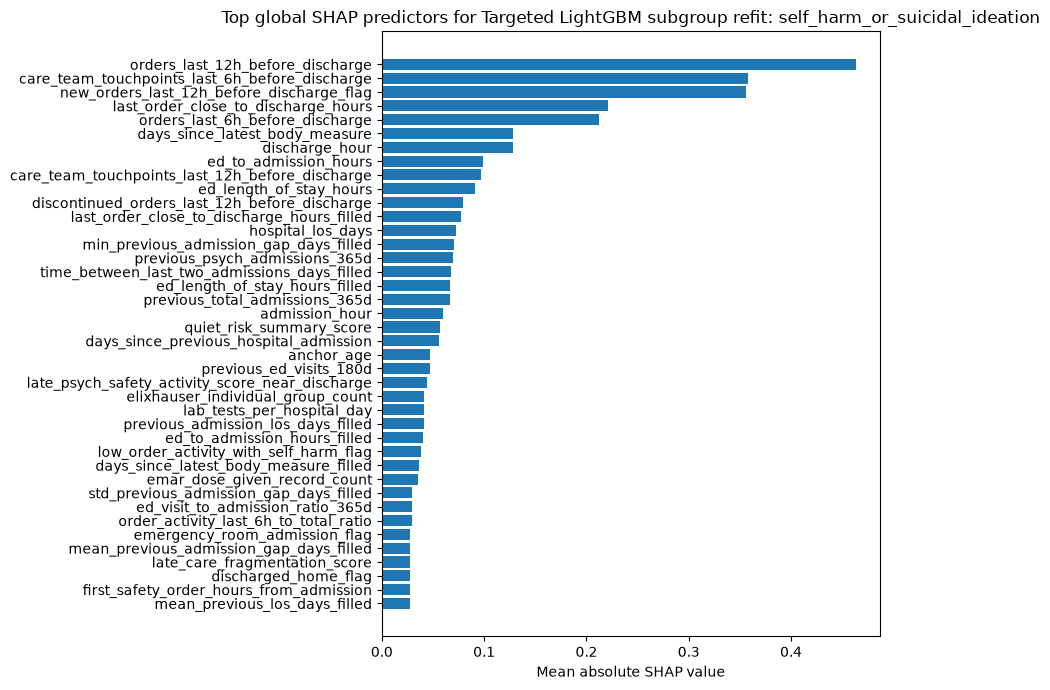

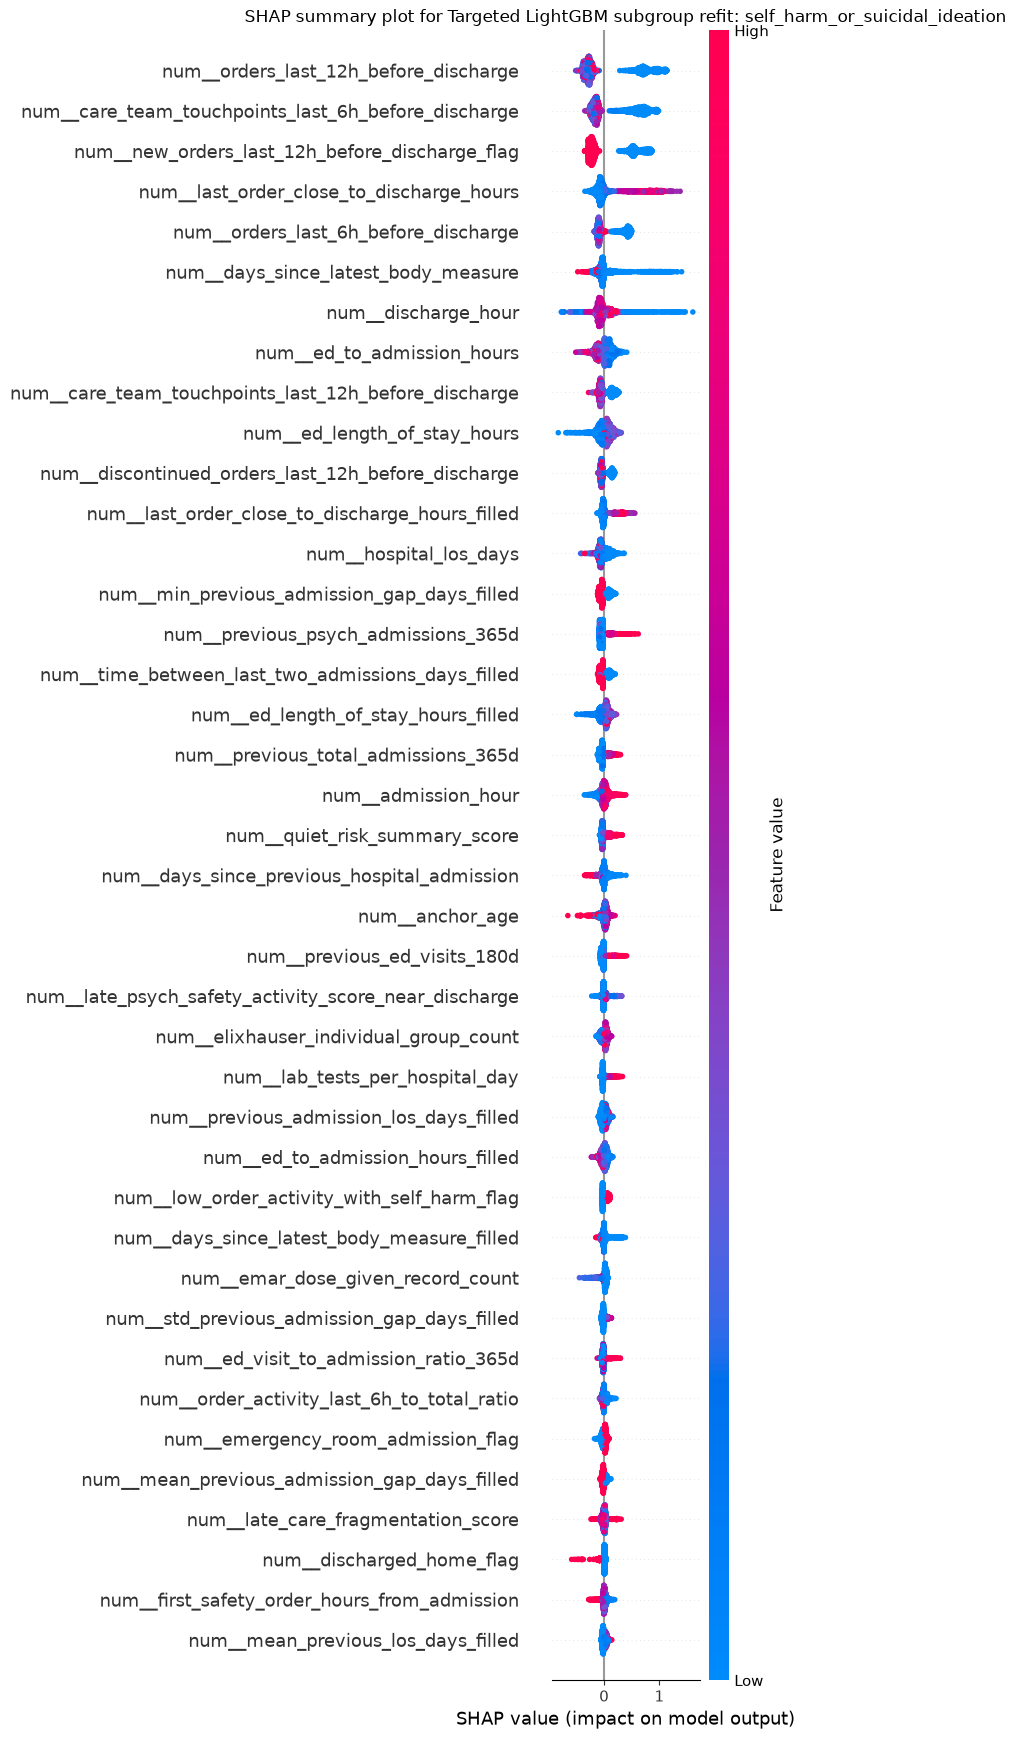

Training subgroup SHAP refit: worst_pr_auc has_cognitive_delirium


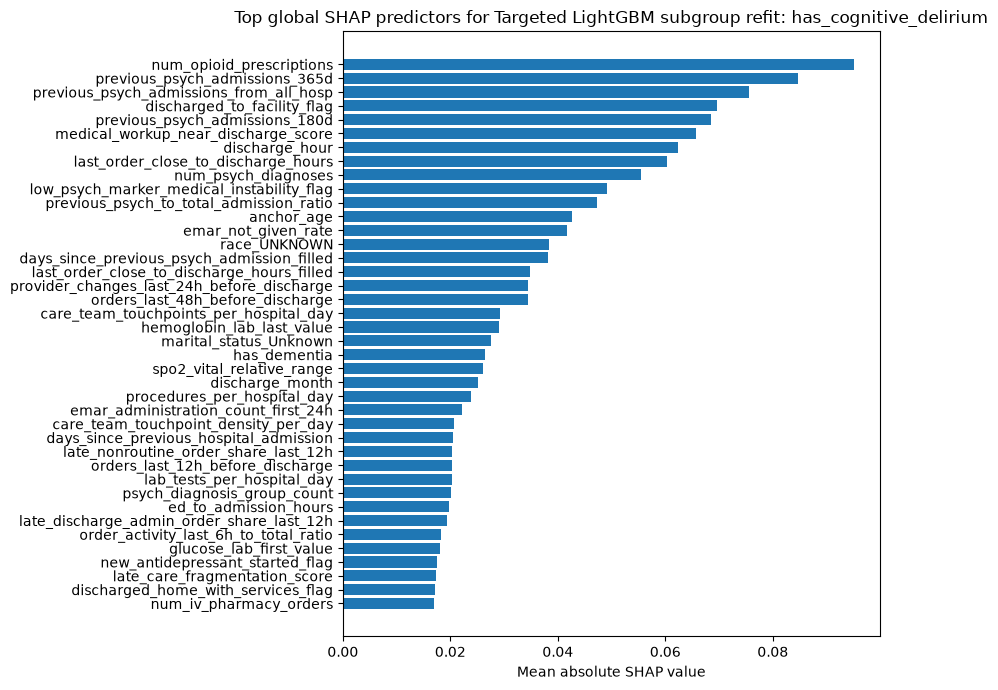

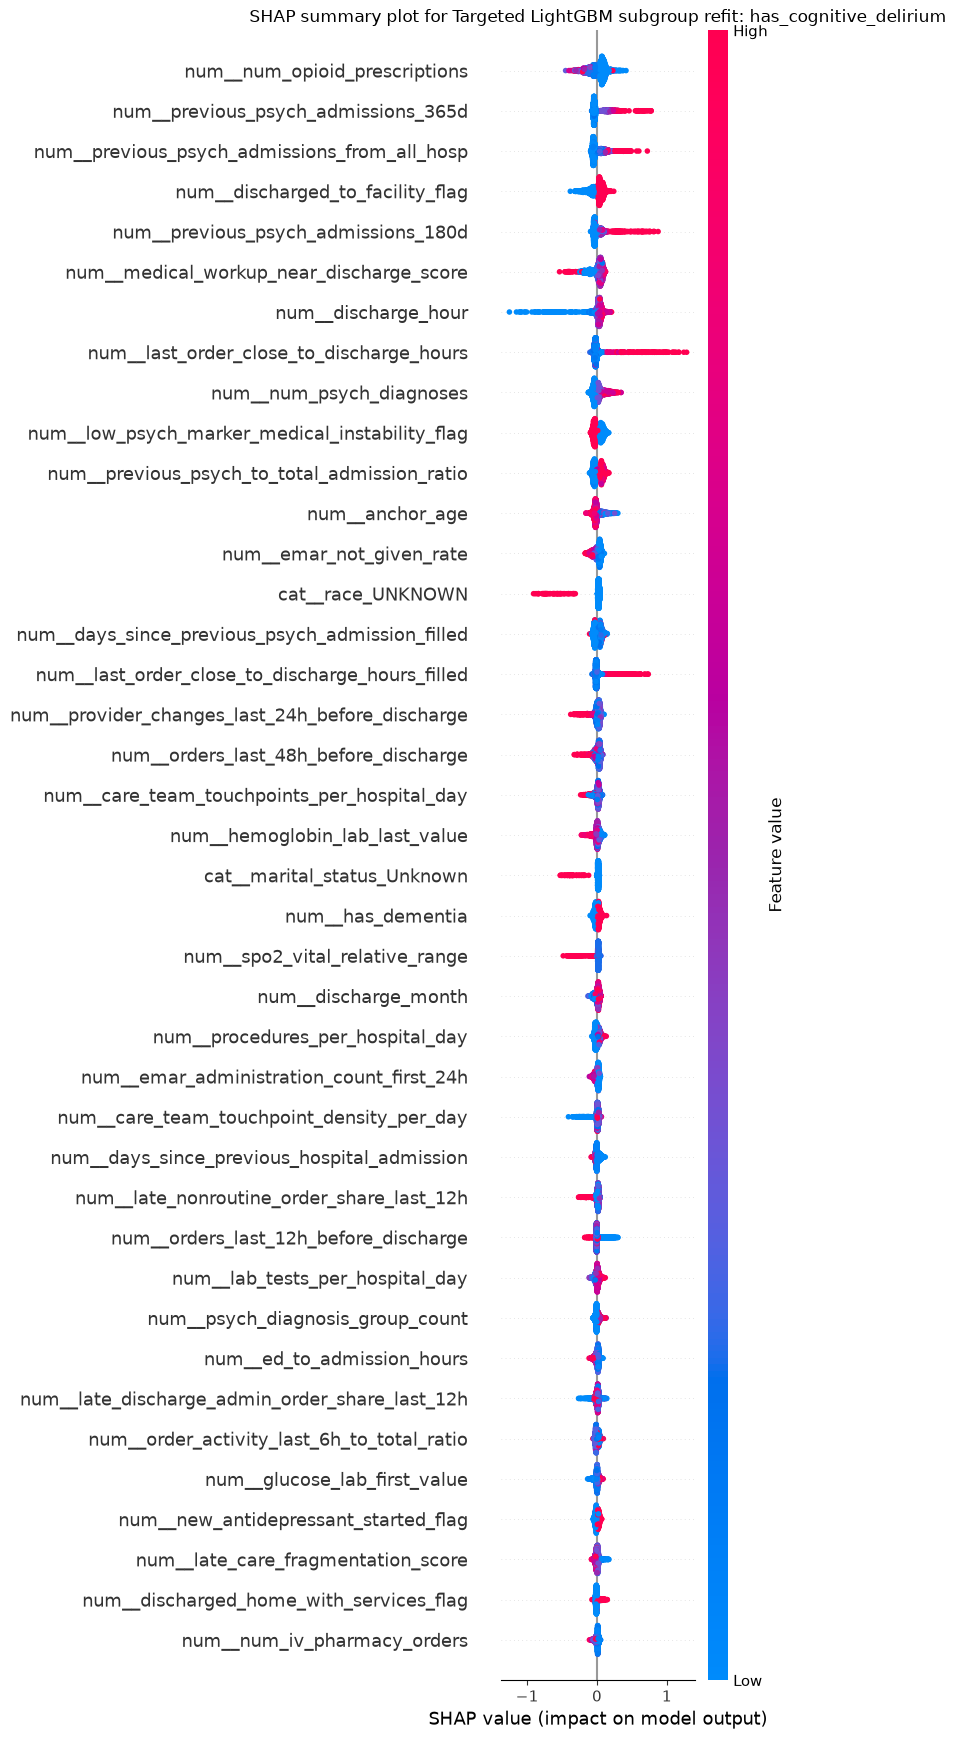

Subgroup-specific SHAP model explanations saved to:
/Users/ahthini/Desktop/DissProject/outputs/WP4/csv_tables/subgroup_models


,subgroup_shap_role,subgroup_model,source_analysis_set,source_table,model_family,matrix_source,train_admissions,test_admissions,test_readmission_rate,wp3_5_subgroup_pr_auc,wp3_5_subgroup_f1,selected_threshold,shap_sample_rows,shap_sample_positive_rows,subgroup_training_seconds,shap_elapsed_seconds,shap_expected_value_log_odds,shap_expected_value_probability,global_bar_plot_file,beeswarm_plot_file
0,best_pr_auc,self_harm_or_suicidal_ideation,clinical_subgroups,clinical_subgroups,Targeted LightGBM,shap_guided_reduced_feature_set,15279,3648,0.338268,0.878010,0.777091,0.26,2200,1041,14.434720,20.456414,-0.946828,0.279523,/Users/ahthini/Desktop/DissProject/outputs/WP4...,/Users/ahthini/Desktop/DissProject/outputs/WP4...
1,worst_pr_auc,has_cognitive_delirium,diagnosis_flag_subgroups,diagnosis_flag_subgroups,Targeted LightGBM,shap_guided_reduced_feature_set,24963,6322,0.147422,0.357662,0.280624,0.38,2200,834,29.784778,21.424940,-1.539648,0.176586,/Users/ahthini/Desktop/DissProject/outputs/WP4...,/Users/ahthini/Desktop/DissProject/outputs/WP4...


,subgroup_shap_role,subgroup_model,wp3_5_subgroup_pr_auc,wp3_5_subgroup_f1,model_family,model_slug,feature_family,processed_feature_count,total_mean_abs_shap,mean_abs_shap,max_mean_abs_shap,family_importance_rank
0,best_pr_auc,self_harm_or_suicidal_ideation,0.878010,0.777091,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,poe_order_pathway,80,2.088831,0.026110,0.463801,1
1,best_pr_auc,self_harm_or_suicidal_ideation,0.878010,0.777091,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,prior_utilisation,46,0.783189,0.017026,0.070530,2
2,best_pr_auc,self_harm_or_suicidal_ideation,0.878010,0.777091,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,other,46,0.551315,0.011985,0.128244,3
3,best_pr_auc,self_harm_or_suicidal_ideation,0.878010,0.777091,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,care_team_complexity,8,0.530437,0.066305,0.358295,4
4,best_pr_auc,self_harm_or_suicidal_ideation,0.878010,0.777091,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,discharge_social,104,0.390018,0.003750,0.127886,5
5,best_pr_auc,self_harm_or_suicidal_ideation,0.878010,0.777091,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,ed_pathway,18,0.327748,0.018208,0.098413,6
6,best_pr_auc,self_harm_or_suicidal_ideation,0.878010,0.777091,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,psychiatric_history,41,0.318725,0.007774,0.044213,7
7,best_pr_auc,self_harm_or_suicidal_ideation,0.878010,0.777091,Targeted LightGBM subgroup refit,subgroup_best_pr_auc_self_harm_or_suicidal_ide...,laboratory,106,0.303410,0.002862,0.011376,8
13,worst_pr_auc,has_cognitive_delirium,0.357662,0.280624,Targeted LightGBM subgroup refit,subgroup_worst_pr_auc_cognitive_delirium,laboratory,106,0.941208,0.008879,0.029055,1
14,worst_pr_auc,has_cognitive_delirium,0.357662,0.280624,Targeted LightGBM subgroup refit,subgroup_worst_pr_auc_cognitive_delirium,poe_order_pathway,80,0.684857,0.008561,0.060362,2


In [119]:
#explain the best and worst subgroup-specific refits from WP3.6 with SHAP
#Only two subgroup models are retrained here: the highest-PR-AUC and lowest-PR-AUC subgroup-specific rows.
subgroup_model_shap_methodology_df = pd.DataFrame()
subgroup_model_shap_global_importance_df = pd.DataFrame()
subgroup_model_shap_family_importance_df = pd.DataFrame()
subgroup_model_shap_top5_features_by_family_df = pd.DataFrame()
subgroup_model_shap_error_group_mean_df = pd.DataFrame()
subgroup_model_shap_error_group_family_df = pd.DataFrame()
subgroup_model_shap_fp_vs_tp_contrast_df = pd.DataFrame()
subgroup_model_shap_fn_vs_tp_contrast_df = pd.DataFrame()
subgroup_model_selection_df = pd.DataFrame()

subgroup_model_output_dir = wp4_csv_output_path / "subgroup_models"
subgroup_model_image_dir = wp4_image_output_path / "subgroup_models"
subgroup_model_output_dir.mkdir(parents=True, exist_ok=True)
subgroup_model_image_dir.mkdir(parents=True, exist_ok=True)

clinical_subgroup_model_path = wp3_6_output_path / "csv_tables" / "t3_6_subgroup_specific_model_performance.csv"
diagnosis_subgroup_model_path = wp3_6_output_path / "csv_tables" / "t3_6_diagnosis_flag_subgroup_specific_model_performance.csv"
wp2_3_dataset_path = project_path / "outputs" / "t2_3_engineered_dataset.csv"

subgroup_performance_frames = []
for subgroup_path, subgroup_source_label in [
        (clinical_subgroup_model_path, "clinical_subgroups"),
        (diagnosis_subgroup_model_path, "diagnosis_flag_subgroups")]:
    if subgroup_path.exists():
        temp_df = pd.read_csv(subgroup_path)
        if not temp_df.empty:
            temp_df["subgroup_source_table"] = subgroup_source_label
            subgroup_performance_frames.append(temp_df)

if not subgroup_performance_frames:
    print("Subgroup model SHAP skipped because WP3.6 subgroup-specific performance files are unavailable.")
elif not wp2_3_dataset_path.exists():
    print("Subgroup model SHAP skipped because the engineered WP2.3 dataset is unavailable.")
else:
    subgroup_model_candidates_df = pd.concat(subgroup_performance_frames, ignore_index=True)
    subgroup_model_candidates_df = subgroup_model_candidates_df.loc[
        subgroup_model_candidates_df["comparison_type"].eq("subgroup_specific_model")].copy()
    subgroup_model_candidates_df = subgroup_model_candidates_df.loc[
        subgroup_model_candidates_df["model_family"].eq(final_model_family)].copy()
    subgroup_model_candidates_df["pr_auc_average_precision"] = pd.to_numeric(
        subgroup_model_candidates_df["pr_auc_average_precision"], errors="coerce")
    subgroup_model_candidates_df = subgroup_model_candidates_df.dropna(subset=["pr_auc_average_precision", "subgroup_model"])

    if subgroup_model_candidates_df.empty:
        print("Subgroup model SHAP skipped because no subgroup-specific rows match", final_model_family)
    else:
        best_subgroup_row = subgroup_model_candidates_df.sort_values(
            ["pr_auc_average_precision", "roc_auc", "f1_score"], ascending=False).iloc[0].copy()
        worst_subgroup_row = subgroup_model_candidates_df.sort_values(
            ["pr_auc_average_precision", "roc_auc", "f1_score"], ascending=True).iloc[0].copy()
        selected_subgroup_rows = pd.DataFrame([best_subgroup_row, worst_subgroup_row]).drop_duplicates(
            ["subgroup_source_table", "subgroup_model"]).reset_index(drop=True)
        selected_subgroup_rows.insert(0, "subgroup_shap_role", ["best_pr_auc", "worst_pr_auc"][:len(selected_subgroup_rows)])
        subgroup_model_selection_df = selected_subgroup_rows.copy()
        subgroup_model_selection_df.to_csv(subgroup_model_output_dir / "t4_shap_subgroup_model_selected_refits.csv", index=False)

        #Load the matching train matrix for the same feature set used by the final model.
        X_train_path = Path(str(X_test_path).replace("_X_test_", "_X_train_"))
        if not X_train_path.exists():
            raise FileNotFoundError(f"Matching train matrix was not found for subgroup refits: {X_train_path}")
        X_train_subgroup_source = sparse.load_npz(X_train_path)
        y_train_subgroup_source = pd.read_csv(wp3_1_output_path / "t3_1_y_train.csv")["readmitted_30d"].astype(int)
        train_ids_subgroup_source = pd.read_csv(wp3_1_output_path / "t3_1_train_ids.csv")

        engineered_header = pd.read_csv(wp2_3_dataset_path, nrows=0).columns.tolist()
        diagnosis_flag_columns = [column for column in [
            "has_depression", "has_bipolar_disorder", "has_psychotic_disorder", "has_anxiety_ptsd",
            "has_substance_use", "has_alcohol_related_disorder", "has_opioid_related_disorder",
            "has_stimulant_related_disorder", "has_cannabis_related_disorder",
            "has_tobacco_or_nicotine_related_disorder", "has_polysubstance_related_disorder",
            "has_self_harm_or_suicidal_ideation", "has_personality_disorder", "has_eating_disorder",
            "has_cognitive_delirium", "has_neurodevelopmental_disorder", "has_severe_mental_illness"]
            if column in engineered_header]
        clinical_signal_columns = [column for column in [
            "has_self_harm_or_suicidal_ideation", "has_severe_mental_illness", "has_substance_use",
            "has_psychotic_disorder", "elixhauser_psychoses", "previous_psych_admissions_365d",
            "previous_psych_admissions_90d", "previous_psych_admissions_from_all_hosp",
            "discharged_to_psych_facility_flag", "discharged_to_facility_flag", "discharged_home_flag",
            "age_65plus", "charlson_comorbidity_index_simplified"] if column in engineered_header]
        subgroup_signal_columns = sorted(set(diagnosis_flag_columns + clinical_signal_columns))
        subgroup_source_df = pd.read_csv(wp2_3_dataset_path, usecols=["subject_id", "hadm_id"] + subgroup_signal_columns)

        train_subgroup_source_df = train_ids_subgroup_source[["subject_id", "hadm_id"]].merge(
            subgroup_source_df, on=["subject_id", "hadm_id"], how="left")
        test_subgroup_source_df = test_ids[["subject_id", "hadm_id"]].merge(
            subgroup_source_df, on=["subject_id", "hadm_id"], how="left")
        for subgroup_column in subgroup_signal_columns:
            train_subgroup_source_df[subgroup_column] = pd.to_numeric(
                train_subgroup_source_df[subgroup_column], errors="coerce").fillna(0)
            test_subgroup_source_df[subgroup_column] = pd.to_numeric(
                test_subgroup_source_df[subgroup_column], errors="coerce").fillna(0)

        def subgroup_column_or_zero(frame, column_name):
            return frame[column_name] if column_name in frame.columns else pd.Series(0, index=frame.index)

        def subgroup_mask_from_name(frame, subgroup_name):
            if subgroup_name in frame.columns:
                return subgroup_column_or_zero(frame, subgroup_name) > 0
            if subgroup_name == "self_harm_or_suicidal_ideation":
                return subgroup_column_or_zero(frame, "has_self_harm_or_suicidal_ideation") > 0
            if subgroup_name == "severe_mental_illness_or_psychosis":
                return (subgroup_column_or_zero(frame, "has_severe_mental_illness") +
                    subgroup_column_or_zero(frame, "has_psychotic_disorder") +
                    subgroup_column_or_zero(frame, "elixhauser_psychoses")) > 0
            if subgroup_name == "substance_use_related":
                return subgroup_column_or_zero(frame, "has_substance_use") > 0
            if subgroup_name == "recent_or_frequent_prior_psych":
                return (subgroup_column_or_zero(frame, "previous_psych_admissions_365d") +
                    subgroup_column_or_zero(frame, "previous_psych_admissions_90d") +
                    subgroup_column_or_zero(frame, "previous_psych_admissions_from_all_hosp")) > 0
            if subgroup_name == "older_or_medically_complex":
                return ((subgroup_column_or_zero(frame, "age_65plus") > 0) |
                    (subgroup_column_or_zero(frame, "charlson_comorbidity_index_simplified") >= 3))
            if subgroup_name == "home_discharge":
                return subgroup_column_or_zero(frame, "discharged_home_flag") > 0
            raise ValueError(f"No subgroup mask rule is available for {subgroup_name}.")

        def clone_subgroup_model(base_model, train_indices):
            try:
                from sklearn.base import clone
                subgroup_model = clone(base_model)
            except Exception:
                import copy
                subgroup_model = copy.deepcopy(base_model)

            #Keep the same positive-class weighting strategy, but rescale it to the subgroup prevalence.
            class_counts = y_train_subgroup_source.iloc[train_indices].value_counts().sort_index()
            if 0 in class_counts.index and 1 in class_counts.index:
                subgroup_scale_pos_weight = class_counts.loc[0] / class_counts.loc[1]
                model_params = subgroup_model.get_params() if hasattr(subgroup_model, "get_params") else {}
                original_class_weight = model_params.get("class_weight")
                if isinstance(original_class_weight, dict) and 1 in original_class_weight:
                    global_counts = y_train_subgroup_source.value_counts().sort_index()
                    global_scale_pos_weight = global_counts.loc[0] / global_counts.loc[1]
                    class_weight_multiplier = original_class_weight[1] / global_scale_pos_weight
                    subgroup_model.set_params(class_weight={0: 1.0, 1: subgroup_scale_pos_weight * class_weight_multiplier})
                elif "scale_pos_weight" in model_params:
                    global_counts = y_train_subgroup_source.value_counts().sort_index()
                    global_scale_pos_weight = global_counts.loc[0] / global_counts.loc[1]
                    class_weight_multiplier = model_params.get("scale_pos_weight", global_scale_pos_weight) / global_scale_pos_weight
                    subgroup_model.set_params(scale_pos_weight=subgroup_scale_pos_weight * class_weight_multiplier)
            return subgroup_model

        subgroup_shap_table_collections = {"global_importance": [], "feature_family_importance": [],
            "top5_features_by_family": [], "error_group_mean": [], "error_group_family": [],
            "fp_vs_tp_contrast": [], "fn_vs_tp_contrast": []}
        subgroup_shap_methodology_rows = []

        for _, subgroup_row in selected_subgroup_rows.iterrows():
            subgroup_name = subgroup_row["subgroup_model"]
            subgroup_role = subgroup_row["subgroup_shap_role"]
            subgroup_slug = str(subgroup_name).replace("has_", "").replace("/", "_").replace(" ", "_")
            model_slug = f"subgroup_{subgroup_role}_{subgroup_slug}"

            train_mask = subgroup_mask_from_name(train_subgroup_source_df, subgroup_name).to_numpy(dtype=bool)
            test_mask = subgroup_mask_from_name(test_subgroup_source_df, subgroup_name).to_numpy(dtype=bool)
            train_indices = np.flatnonzero(train_mask)
            test_indices = np.flatnonzero(test_mask)
            if len(train_indices) < 200 or len(test_indices) < 100:
                print("Skipping subgroup SHAP for", subgroup_name, "because the subgroup is too small.")
                continue
            if y_train_subgroup_source.iloc[train_indices].nunique() < 2 or y_test.iloc[test_indices].nunique() < 2:
                print("Skipping subgroup SHAP for", subgroup_name, "because one class is missing.")
                continue

            subgroup_refit_model = clone_subgroup_model(final_model, train_indices)
            print("Training subgroup SHAP refit:", subgroup_role, subgroup_name)
            training_start = time.perf_counter()
            subgroup_refit_model.fit(X_train_subgroup_source[train_indices], y_train_subgroup_source.iloc[train_indices])
            subgroup_training_seconds = time.perf_counter() - training_start

            subgroup_test_probability = subgroup_refit_model.predict_proba(X_test[test_indices])[:, 1]
            subgroup_threshold = float(subgroup_row.get("threshold", wp4_selected_threshold))
            subgroup_index_df = test_ids.iloc[test_indices][["subject_id", "hadm_id"]].copy().reset_index(drop=True)
            subgroup_index_df["readmitted_30d"] = y_test.iloc[test_indices].to_numpy(dtype=int)
            subgroup_index_df["predicted_probability"] = subgroup_test_probability
            subgroup_index_df["test_row_index"] = np.arange(len(subgroup_index_df))

            subgroup_sample_indices, subgroup_X_sample, subgroup_sample_index_df = make_shap_sample(subgroup_index_df, X_test[test_indices])
            subgroup_diagnostic_df = create_error_group_index(subgroup_sample_index_df, subgroup_threshold)

            shap_start = time.perf_counter()
            subgroup_shap_values, subgroup_base_value, subgroup_plot_matrix = compute_tree_shap(
                subgroup_refit_model, subgroup_X_sample, processed_feature_names)
            subgroup_shap_seconds = time.perf_counter() - shap_start

            subgroup_tables = make_shap_summary_tables(
                f"{final_model_family} subgroup refit", model_slug, processed_feature_names,
                subgroup_shap_values, subgroup_diagnostic_df)
            for table_name, table_df in subgroup_tables.items():
                table_df = table_df.copy()
                table_df.insert(0, "subgroup_shap_role", subgroup_role)
                table_df.insert(1, "subgroup_model", subgroup_name)
                table_df.insert(2, "wp3_6_subgroup_pr_auc", subgroup_row.get("pr_auc_average_precision", np.nan))
                table_df.insert(3, "wp3_6_subgroup_f1", subgroup_row.get("f1_score", np.nan))
                if table_name in subgroup_shap_table_collections:
                    subgroup_shap_table_collections[table_name].append(table_df)

            model_image_dir = subgroup_model_image_dir / model_slug
            bar_path, beeswarm_path = save_core_plots(
                f"{final_model_family} subgroup refit: {subgroup_name}", model_slug,
                processed_feature_names, subgroup_shap_values, subgroup_plot_matrix,
                subgroup_tables["global_importance"], model_image_dir)

            for table_name, table_df in subgroup_tables.items():
                table_df.to_csv(subgroup_model_output_dir / f"t4_shap_{model_slug}_{table_name}.csv", index=False)

            subgroup_shap_methodology_rows.append({"subgroup_shap_role": subgroup_role,
                "subgroup_model": subgroup_name,
                "source_analysis_set": subgroup_row.get("analysis_set", np.nan),
                "source_table": subgroup_row.get("subgroup_source_table", np.nan),
                "model_family": final_model_family,
                "matrix_source": matrix_source_label,
                "train_admissions": len(train_indices),
                "test_admissions": len(test_indices),
                "test_readmission_rate": subgroup_index_df["readmitted_30d"].mean(),
                "wp3_6_subgroup_pr_auc": subgroup_row.get("pr_auc_average_precision", np.nan),
                "wp3_6_subgroup_f1": subgroup_row.get("f1_score", np.nan),
                "selected_threshold": subgroup_threshold,
                "shap_sample_rows": subgroup_X_sample.shape[0],
                "shap_sample_positive_rows": int(subgroup_sample_index_df["readmitted_30d"].sum()),
                "subgroup_training_seconds": subgroup_training_seconds,
                "shap_elapsed_seconds": subgroup_shap_seconds,
                "shap_expected_value_log_odds": subgroup_base_value,
                "shap_expected_value_probability": expit(subgroup_base_value),
                "global_bar_plot_file": str(bar_path),
                "beeswarm_plot_file": str(beeswarm_path)})

        subgroup_model_shap_methodology_df = pd.DataFrame(subgroup_shap_methodology_rows)
        subgroup_model_shap_methodology_df.to_csv(subgroup_model_output_dir / "t4_shap_subgroup_model_methodology.csv", index=False)

        for table_name, table_list in subgroup_shap_table_collections.items():
            combined_table = pd.concat(table_list, ignore_index=True) if table_list else pd.DataFrame()
            globals()[f"subgroup_model_shap_{table_name}_df"] = combined_table
            if not combined_table.empty:
                combined_table.to_csv(subgroup_model_output_dir / f"t4_shap_subgroup_model_{table_name}.csv", index=False)

        subgroup_model_shap_global_importance_df = subgroup_model_shap_global_importance_df if "subgroup_model_shap_global_importance_df" in globals() else pd.DataFrame()
        subgroup_model_shap_family_importance_df = subgroup_model_shap_feature_family_importance_df if "subgroup_model_shap_feature_family_importance_df" in globals() else pd.DataFrame()
        subgroup_model_shap_top5_features_by_family_df = subgroup_model_shap_top5_features_by_family_df if "subgroup_model_shap_top5_features_by_family_df" in globals() else pd.DataFrame()
        subgroup_model_shap_error_group_mean_df = subgroup_model_shap_error_group_mean_df if "subgroup_model_shap_error_group_mean_df" in globals() else pd.DataFrame()
        subgroup_model_shap_error_group_family_df = subgroup_model_shap_error_group_family_df if "subgroup_model_shap_error_group_family_df" in globals() else pd.DataFrame()
        subgroup_model_shap_fp_vs_tp_contrast_df = subgroup_model_shap_fp_vs_tp_contrast_df if "subgroup_model_shap_fp_vs_tp_contrast_df" in globals() else pd.DataFrame()
        subgroup_model_shap_fn_vs_tp_contrast_df = subgroup_model_shap_fn_vs_tp_contrast_df if "subgroup_model_shap_fn_vs_tp_contrast_df" in globals() else pd.DataFrame()

        subgroup_model_workbook_path = wp4_output_path / "t4_shap_subgroup_model_explanation_tables.xlsx"
        subgroup_model_workbook_tables = {"selected_subgroup_refits": subgroup_model_selection_df,
            "methodology": subgroup_model_shap_methodology_df,
            "global_importance": subgroup_model_shap_global_importance_df,
            "feature_family_importance": subgroup_model_shap_family_importance_df,
            "top5_features_by_family": subgroup_model_shap_top5_features_by_family_df,
            "error_group_mean": subgroup_model_shap_error_group_mean_df,
            "error_group_family": subgroup_model_shap_error_group_family_df,
            "fp_vs_tp_contrast": subgroup_model_shap_fp_vs_tp_contrast_df,
            "fn_vs_tp_contrast": subgroup_model_shap_fn_vs_tp_contrast_df}
        with pd.ExcelWriter(subgroup_model_workbook_path) as writer:
            for sheet_name, table_df in subgroup_model_workbook_tables.items():
                if table_df is not None and not table_df.empty:
                    table_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

        print("Subgroup-specific SHAP model explanations saved to:")
        print(subgroup_model_output_dir)
        display(subgroup_model_shap_methodology_df)
        if not subgroup_model_shap_family_importance_df.empty:
            display(subgroup_model_shap_family_importance_df.groupby(["subgroup_shap_role", "subgroup_model"]).head(8))


In [120]:
#write a compact SHAP workbook and output file summary
shap_workbook_path = wp4_output_path / "t4_shap_explanation_tables.xlsx"
workbook_tables = {"methodology_summary": methodology_summary_df,
    "global_importance": shap_global_importance_df,
    "feature_family_importance": shap_family_importance_df,
    "top5_features_by_family": shap_top5_features_by_family_df,
    "selected_local_cases": selected_local_cases_df,
    "local_explanation_summary": local_explanation_summary_df,
    "local_top_features": local_top_features_df,
    
    "error_group_mean_shap": shap_error_group_mean_df if "shap_error_group_mean_df" in globals() else pd.DataFrame(),
    "error_group_family_shap": shap_error_group_family_df if "shap_error_group_family_df" in globals() else pd.DataFrame(),
    "fp_vs_tp_contrast": fp_vs_tp_shap_contrast_df if "fp_vs_tp_shap_contrast_df" in globals() else pd.DataFrame(),
    "fn_vs_tp_contrast": fn_vs_tp_shap_contrast_df if "fn_vs_tp_shap_contrast_df" in globals() else pd.DataFrame(),
    "fn_vs_tn_contrast": fn_vs_tn_shap_contrast_df if "fn_vs_tn_shap_contrast_df" in globals() else pd.DataFrame(),
    "feature_directionality": shap_feature_directionality_df if "shap_feature_directionality_df" in globals() else pd.DataFrame(),
    "subgroup_family_shap": subgroup_shap_family_df if "subgroup_shap_family_df" in globals() else pd.DataFrame(),
    "subgroup_top_features": subgroup_shap_top_features_df if "subgroup_shap_top_features_df" in globals() else pd.DataFrame(),
    "dependence_plot_summary": shap_dependence_plot_summary_df if "shap_dependence_plot_summary_df" in globals() else pd.DataFrame(),
    "force_plot_cases": force_plot_summary_df,
    "force_bar_top_features": force_bar_top_features_df,
    "local_case_windows": local_case_window_summary_df,
    "subgroup_model_selection": subgroup_model_selection_df if "subgroup_model_selection_df" in globals() else pd.DataFrame(),
    "subgroup_model_methodology": subgroup_model_shap_methodology_df if "subgroup_model_shap_methodology_df" in globals() else pd.DataFrame(),
    "subgroup_model_global": subgroup_model_shap_global_importance_df if "subgroup_model_shap_global_importance_df" in globals() else pd.DataFrame(),
    "subgroup_model_family": subgroup_model_shap_family_importance_df if "subgroup_model_shap_family_importance_df" in globals() else pd.DataFrame(),
    "subgroup_model_top5": subgroup_model_shap_top5_features_by_family_df if "subgroup_model_shap_top5_features_by_family_df" in globals() else pd.DataFrame(),
    "subgroup_model_error_group": subgroup_model_shap_error_group_mean_df if "subgroup_model_shap_error_group_mean_df" in globals() else pd.DataFrame(),
    "subgroup_model_fp_tp": subgroup_model_shap_fp_vs_tp_contrast_df if "subgroup_model_shap_fp_vs_tp_contrast_df" in globals() else pd.DataFrame(),
    "subgroup_model_fn_tp": subgroup_model_shap_fn_vs_tp_contrast_df if "subgroup_model_shap_fn_vs_tp_contrast_df" in globals() else pd.DataFrame()}

with pd.ExcelWriter(shap_workbook_path) as writer:
    for sheet_name, table_df in workbook_tables.items():
        if table_df is not None and not table_df.empty:
            table_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

output_summary_rows = []
for file_path in sorted(wp4_output_path.rglob("*")):
    if file_path.is_file():
        output_summary_rows.append({"output_folder": str(file_path.parent.relative_to(wp4_output_path)),
            "output_file": file_path.name,
            "file_size_mb": round(file_path.stat().st_size / (1024 * 1024), 3)})

wp4_output_file_summary_df = pd.DataFrame(output_summary_rows)
wp4_output_file_summary_df.to_csv(wp4_csv_output_path / "t4_shap_output_file_summary.csv", index=False)
wp4_output_file_summary_df.to_excel(wp4_output_path / "t4_shap_output_file_summary.xlsx", index=False)

print("WP4 SHAP workbook:")
print(shap_workbook_path)
print("WP4 output files:")
display(wp4_output_file_summary_df)
print("WP4 complete. Outputs saved to:")
print(wp4_output_path)


WP4 SHAP workbook:
/Users/ahthini/Desktop/DissProject/outputs/WP4/t4_shap_explanation_tables.xlsx
WP4 output files:


,output_folder,output_file,file_size_mb
0,csv_tables/subgroup_models,t4_shap_subgroup_best_pr_auc_self_harm_or_suic...,0.009
1,csv_tables/subgroup_models,t4_shap_subgroup_best_pr_auc_self_harm_or_suic...,0.452
2,csv_tables/subgroup_models,t4_shap_subgroup_best_pr_auc_self_harm_or_suic...,0.002
3,csv_tables/subgroup_models,t4_shap_subgroup_best_pr_auc_self_harm_or_suic...,0.156
4,csv_tables/subgroup_models,t4_shap_subgroup_best_pr_auc_self_harm_or_suic...,0.155
...,...,...,...
124,images/targeted_xgboost,t4_shap_targeted_xgboost_waterfall_low_risk_st...,0.538
125,.,t4_shap_explanation_tables.xlsx,0.949
126,.,t4_shap_output_file_summary.xlsx,0.007
127,.,t4_shap_paired_model_explanation_tables.xlsx,0.706


WP4 complete. Outputs saved to:
/Users/ahthini/Desktop/DissProject/outputs/WP4
